In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import time


# --- 1. Stieltjes–Wigert Monic Polynomials (KLS 3.27) ---
def stieltjes_wigert_polynomials(x, degree, q_param):
    """
    Exact Stieltjes–Wigert monic polynomials P_n(x) via the standard
    three-term recurrence (Koekoek–Lesky–Swarttouw, section 3.27):

        x P_n(x) = P_{n+1}(x) + b_n P_n(x) + a_n^2 P_{n-1}(x),

    with
        b_n  = q^(-2n - 3/2) * (1 + q - q^{n+1}),
        a_n^2 = q^(-4n) * (1 - q^n),

    and initial conditions
        P_{-1}(x) = 0,  P_0(x) = 1.

    We then generate P_0, ..., P_degree.

    Args:
        x: input tensor [batch, input_dim]  (raw network input)
        degree: maximum polynomial degree K
        q_param: raw learnable scalar (passed through sigmoid to get q in (0,1))

    Returns:
        tensor [batch, input_dim, degree+1] containing [P_0, ..., P_degree]
    """
    # Constrain q to (0.005, 0.995) for numerical stability
    q = torch.sigmoid(q_param) * 0.99 + 0.005

    # Optional: map raw x to (0, +inf) since Stieltjes–Wigert is supported on (0, +inf)
    # This is a reparametrization of the argument; P_n as a function of its argument
    # is still exactly the classical SW polynomial.
    x_pos = torch.exp(2.0 * torch.tanh(x))  # (e^-2, e^2) ⊂ (0, ∞)

    # P_{-1}(x) = 0, P_0(x) = 1
    Pm1 = torch.zeros_like(x_pos)   # P_{-1}
    P0 = torch.ones_like(x_pos)     # P_0

    polynomials = [P0]

    if degree >= 1:
        # P_1(x) = x - b_0
        # b_0 = q^(-2*0 - 3/2) * (1 + q - q^{1}) = q^(-3/2) * (1 + q - q)
        b0 = q ** (-1.5) * (1.0)  # because (1 + q - q^1) = 1
        P1 = x_pos - b0
        polynomials.append(P1)

        # update recursion state
        Pm1, P0 = P0, P1

    for n in range(1, degree):
        # b_n, a_n^2 for Stieltjes–Wigert (monic)
        # b_n = q^(-2n - 3/2) * (1 + q - q^{n+1})
        # a_n^2 = q^(-4n) * (1 - q^n)
        bn = q ** (-2.0 * n - 1.5) * (1.0 + q - q ** (n + 1))
        an2 = q ** (-4.0 * n) * (1.0 - q ** n)

        # x P_n = P_{n+1} + b_n P_n + a_n^2 P_{n-1}
        # => P_{n+1} = x P_n - b_n P_n - a_n^2 P_{n-1}
        P1 = x_pos * P0 - bn * P0 - an2 * Pm1

        polynomials.append(P1)
        Pm1, P0 = P0, P1

    return torch.stack(polynomials, dim=-1)


# --- 2. Stieltjes–Wigert KAN Layer (no bias, no post-activation) ---
class StieltjesWigertKANLayer(nn.Module):
    def __init__(self, input_dim, output_dim, degree=3, learnable_q=True):
        super().__init__()
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.degree = degree

        # Trainable coefficients: [output_dim, input_dim, degree+1]
        self.weights = nn.Parameter(
            torch.randn(output_dim, input_dim, degree + 1) * 0.02
        )

        # Learnable q parameter (raw logit space)
        # sigmoid(0.0) = 0.5, so initial q ~ 0.5
        if learnable_q:
            self.q_param = nn.Parameter(torch.tensor(0.0))
        else:
            self.register_buffer('q_param', torch.tensor(0.0))

    def forward(self, x):
        """
        Args:
            x: [batch, input_dim]
        Returns:
            [batch, output_dim]  (no bias, no post-activation)
        """
        if x.dim() > 2:
            x = x.view(x.shape[0], -1)

        # polynomials: [batch, input_dim, degree+1], P_0..P_degree
        polynomials = stieltjes_wigert_polynomials(x, self.degree, self.q_param)

        # Efficient contraction via einsum
        # polynomials: b i d,  weights: o i d  ->  output: b o
        output = torch.einsum('bid, oid -> bo', polynomials, self.weights)

        return output


# --- 3. Full Model for MNIST ---
class StieltjesWigertKAN_MNIST(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=64, num_classes=10, degree=3):
        super().__init__()

        self.flatten = nn.Flatten()

        # KAN layers (nonlinearity is inside the polynomial basis)
        self.kan1 = StieltjesWigertKANLayer(input_dim, hidden_dim, degree=degree)
        self.norm1 = nn.LayerNorm(hidden_dim)
        self.drop1 = nn.Dropout(0.1)

        self.kan2 = StieltjesWigertKANLayer(hidden_dim, hidden_dim, degree=degree)
        self.norm2 = nn.LayerNorm(hidden_dim)
        self.drop2 = nn.Dropout(0.1)

        self.kan3 = StieltjesWigertKANLayer(hidden_dim, num_classes, degree=degree)

    def forward(self, x):
        x = self.flatten(x)

        x = self.kan1(x)
        x = self.norm1(x)
        x = self.drop1(x)

        x = self.kan2(x)
        x = self.norm2(x)
        x = self.drop2(x)

        x = self.kan3(x)
        return x


# --- 4. Training ---
def train_mnist(epochs=10, batch_size=64, device='cuda'):
    print("=" * 60)
    print("Stieltjes–Wigert KAN on MNIST (exact SW basis)")
    print(f"Device: {device} | Epochs: {epochs} | Batch: {batch_size}")
    print("=" * 60)

    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ])

    train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
    test_dataset = datasets.MNIST('./data', train=False, transform=transform)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
    test_loader = DataLoader(train_dataset, batch_size=1000, shuffle=False, num_workers=0)

    model = StieltjesWigertKAN_MNIST(
        input_dim=784, hidden_dim=64, num_classes=10, degree=3
    ).to(device)

    optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss()

    train_losses = []
    test_accuracies = []

    for epoch in range(1, epochs + 1):
        model.train()
        start = time.time()
        epoch_loss = 0.0

        for data, target in train_loader:
            data, target = data.to(device), target.to(device)
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            epoch_loss += loss.item()

        # Evaluate
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for data, target in test_loader:
                data, target = data.to(device), target.to(device)
                pred = model(data).argmax(dim=1)
                correct += pred.eq(target).sum().item()
                total += target.size(0)

        accuracy = 100.0 * correct / total
        avg_loss = epoch_loss / len(train_loader)
        train_losses.append(avg_loss)
        test_accuracies.append(accuracy)

        # Print learned q values
        q_info = []
        for name, param in model.named_parameters():
            if 'q_param' in name:
                q_val = (torch.sigmoid(param) * 0.99 + 0.005).item()
                q_info.append(f"{name}: q={q_val:.4f}")

        elapsed = time.time() - start
        print(f"Epoch {epoch:2d}/{epochs} | Loss: {avg_loss:.4f} | "
              f"Acc: {accuracy:.2f}% | Time: {elapsed:.1f}s")
        if q_info:
            print(f"  {' | '.join(q_info)}")

        scheduler.step()

    print("-" * 60)
    print(f"Best accuracy: {max(test_accuracies):.2f}%")
    return model, train_losses, test_accuracies


# --- 5. Parameter count ---
def count_parameters(model):
    total = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\nTotal trainable parameters: {total:,}")
    for name, p in model.named_parameters():
        if p.requires_grad:
            print(f"  {name:40s} {p.numel():>10,}  {list(p.shape)}")
    return total


# --- 6. Main ---
if __name__ == '__main__':
    EPOCHS = 50
    BATCH_SIZE = 64
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = StieltjesWigertKAN_MNIST(
        input_dim=784, hidden_dim=64, num_classes=10, degree=3
    ).to(DEVICE)
    count_parameters(model)

    model, losses, accuracies = train_mnist(
        epochs=EPOCHS, batch_size=BATCH_SIZE, device=DEVICE
    )

    torch.save(model.state_dict(), 'sw_kan_mnist_exact.pth')
    print(f"\nModel saved: sw_kan_mnist_exact.pth")
    print(f"Final accuracy: {accuracies[-1]:.2f}% | Best: {max(accuracies):.2f}%")



Total trainable parameters: 219,907
  kan1.weights                                200,704  [64, 784, 4]
  kan1.q_param                                      1  []
  norm1.weight                                     64  [64]
  norm1.bias                                       64  [64]
  kan2.weights                                 16,384  [64, 64, 4]
  kan2.q_param                                      1  []
  norm2.weight                                     64  [64]
  norm2.bias                                       64  [64]
  kan3.weights                                  2,560  [10, 64, 4]
  kan3.q_param                                      1  []
Stieltjes–Wigert KAN on MNIST (exact SW basis)
Device: cuda | Epochs: 50 | Batch: 64


100%|██████████| 9.91M/9.91M [00:00<00:00, 40.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.10MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 10.6MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.16MB/s]


Epoch  1/50 | Loss: 4.4244 | Acc: 86.63% | Time: 28.7s
  kan1.q_param: q=0.4584 | kan2.q_param: q=0.5206 | kan3.q_param: q=0.6265
Epoch  2/50 | Loss: 0.2790 | Acc: 95.31% | Time: 27.5s
  kan1.q_param: q=0.4592 | kan2.q_param: q=0.5541 | kan3.q_param: q=0.6927
Epoch  3/50 | Loss: 0.1941 | Acc: 95.89% | Time: 27.6s
  kan1.q_param: q=0.4566 | kan2.q_param: q=0.5689 | kan3.q_param: q=0.7268
Epoch  4/50 | Loss: 0.1531 | Acc: 96.97% | Time: 27.6s
  kan1.q_param: q=0.4549 | kan2.q_param: q=0.5725 | kan3.q_param: q=0.7416
Epoch  5/50 | Loss: 0.1281 | Acc: 97.33% | Time: 27.6s
  kan1.q_param: q=0.4556 | kan2.q_param: q=0.5766 | kan3.q_param: q=0.7509
Epoch  6/50 | Loss: 0.1114 | Acc: 97.58% | Time: 27.5s
  kan1.q_param: q=0.4546 | kan2.q_param: q=0.5802 | kan3.q_param: q=0.7568
Epoch  7/50 | Loss: 0.1017 | Acc: 97.89% | Time: 27.3s
  kan1.q_param: q=0.4535 | kan2.q_param: q=0.5828 | kan3.q_param: q=0.7620
Epoch  8/50 | Loss: 0.0921 | Acc: 98.24% | Time: 27.7s
  kan1.q_param: q=0.4546 | kan2.q_p

KeyboardInterrupt: 

In [1]:
import numpy as np
import plotly.graph_objects as go

def sw_polynomials(x, q, max_degree):
    S = np.zeros((max_degree + 1, len(x)))
    S[0] = 1.0
    if max_degree >= 1:
        S[1] = (1.0 - q**2 * x) / (1.0 - q)
    for n in range(1, max_degree):
        qn1 = q**(n + 1)
        num = (1.0 + q - qn1) * S[n] - q * S[n-1] - q**(2*n+1) * x * S[n]
        den = 1.0 - qn1
        S[n+1] = num / den
    return S

qs = [0.3, 0.5, 0.7]   # هر مقداری خواستی اینجا عوض کن
max_degree = 5
x = np.linspace(0.01, 5.0, 500)

fig = go.Figure()
colors = ['#FF6B6B', '#6C5CE7', '#00B894']

for q, color in zip(qs, colors):
    S = sw_polynomials(x, q, max_degree)
    fig.add_trace(go.Scatter(
        x=x, y=S[max_degree],
        mode='lines',
        name=f"S_{max_degree}(x; q={q})",
        line=dict(color=color, width=2.5),
    ))

fig.update_layout(
    title="Stieltjes–Wigert S5 for different q",
    xaxis_title="x",
    yaxis_title="S_5(x; q)",
    legend=dict(
        orientation='h',
        yanchor='bottom',
        y=1.05,
        xanchor='center',
        x=0.5,
    ),
)

fig.show()


In [11]:
import numpy as np
import plotly.graph_objects as go

def sw_polynomials(x, q, max_degree):
    S = np.zeros((max_degree + 1, len(x)))
    S[0] = 1.0
    if max_degree >= 1:
        S[1] = (1.0 - q**2 * x) / (1.0 - q)
    for n in range(1, max_degree):
        qn1 = q**(n + 1)
        num = (1.0 + q - qn1) * S[n] - q * S[n-1] - q**(2*n+1) * x * S[n]
        den = 1.0 - qn1
        S[n+1] = num / den
    return S

qs = [0.3, 0.5, 0.7]
max_degree = 5
x = np.linspace(0.01, 5.0, 500)

fig = go.Figure()

# پالت آبی / فیروزه‌ای
colors = [
    "#1B4F72",  # آبی تیره
    "#2874A6",  # آبی متوسط
    "#48C9B0",  # فیروزه‌ای
]

for q, color in zip(qs, colors):
    S = sw_polynomials(x, q, max_degree)
    fig.add_trace(go.Scatter(
        x=x, y=S[max_degree],
        mode='lines',
        name=f"S_{max_degree}(x; q={q})",
        line=dict(color=color, width=2.5),
    ))

fig.update_layout(
    title="Stieltjes–Wigert S5 for different q",
    xaxis_title="x",
    yaxis_title="S_5(x; q)",
    legend=dict(
        orientation='h',
        yanchor='bottom',
        y=1.05,
        xanchor='center',
        x=0.5,
    ),
    plot_bgcolor="#EAF6F9",   # پس‌زمینه‌ی آبی خیلی روشن
    paper_bgcolor="white",
)

fig.show()


In [12]:
import numpy as np
import plotly.graph_objects as go

def sw_polynomials(x, q, max_degree):
    S = np.zeros((max_degree + 1, len(x)))
    S[0] = 1.0
    if max_degree >= 1:
        S[1] = (1.0 - q**2 * x) / (1.0 - q)
    for n in range(1, max_degree):
        qn1 = q**(n + 1)
        num = (1.0 + q - qn1) * S[n] - q * S[n-1] - q**(2*n+1) * x * S[n]
        den = 1.0 - qn1
        S[n+1] = num / den
    return S

q = 0.3          # این را به 0.6 یا 0.9 عوض کن برای شکل‌های دیگر
max_degree = 5
x = np.linspace(0.01, 5.0, 500)

fig = go.Figure()

# پالت آبی / فیروزه‌ای برای S0..S5
colors = [
    "#1B4F72",  # S0
    "#2874A6",  # S1
    "#2E86C1",  # S2
    "#3498DB",  # S3
    "#48C9B0",  # S4
    "#1ABC9C",  # S5
]

S = sw_polynomials(x, q, max_degree)
for n, color in zip(range(max_degree + 1), colors):
    fig.add_trace(go.Scatter(
        x=x,
        y=S[n],
        mode='lines',
        name=f"S_{n}(x; q={q})",
        line=dict(color=color, width=2.5),
    ))

fig.update_layout(
    title=f"Stieltjes–Wigert S₀–S₅ for q = {q}",
    xaxis_title="x",
    yaxis_title="S_n(x; q)",
    legend=dict(
        orientation='h',
        yanchor='bottom',
        y=1.05,
        xanchor='center',
        x=0.5,
    ),
    plot_bgcolor="#EAF6F9",   # پس‌زمینه آبی روشن
    paper_bgcolor="white",
)

fig.show()


In [20]:
import numpy as np
import plotly.graph_objects as go

def sw_polynomials(x, q, max_degree):
    S = np.zeros((max_degree + 1, len(x)))
    S[0] = 1.0
    if max_degree >= 1:
        S[1] = (1.0 - q**2 * x) / (1.0 - q)
    for n in range(1, max_degree):
        qn1 = q**(n + 1)
        num = (1.0 + q - qn1) * S[n] - q * S[n-1] - q**(2*n+1) * x * S[n]
        den = 1.0 - qn1
        S[n+1] = num / den
    return S

q = 0.1
max_degree = 5
x = np.linspace(0.01, 5.0, 500)

fig = go.Figure()

colors = [
    "#1B4F72",
    "#2874A6",
    "#2E86C1",
    "#3498DB",
    "#48C9B0",
    "#1ABC9C",
]

S = sw_polynomials(x, q, max_degree)
for n, color in zip(range(max_degree + 1), colors):
    fig.add_trace(go.Scatter(
        x=x,
        y=S[n],
        mode='lines',
        name=f"S_{n}(x; q={q})",
        line=dict(color=color, width=2.5),
    ))

fig.update_layout(
    title=dict(
        text=f"Stieltjes–Wigert S₀–S₅ for q = {q}",
        x=0.5,
        y=1,           # عنوان را بالاتر می‌برد
        xanchor="center",
        yanchor="top",
    ),
    xaxis_title="x",
    yaxis_title="S_n(x; q)",
    legend=dict(
        orientation='h',
        yanchor='bottom',
        y=1.02,           # کمی پایین‌تر از قبل
        xanchor='center',
        x=0.5,
    ),
    plot_bgcolor="#EAF6F9",
    paper_bgcolor="white",
    margin=dict(t=80, b=40, l=60, r=20),  # فضای بیشتر بالا
)

fig.show()


In [15]:
import numpy as np
import plotly.graph_objects as go

def sw_polynomials(x, q, max_degree):
    S = np.zeros((max_degree + 1, len(x)))
    S[0] = 1.0
    if max_degree >= 1:
        S[1] = (1.0 - q**2 * x) / (1.0 - q)
    for n in range(1, max_degree):
        qn1 = q**(n + 1)
        num = (1.0 + q - qn1) * S[n] - q * S[n-1] - q**(2*n+1) * x * S[n]
        den = 1.0 - qn1
        S[n+1] = num / den
    return S

q = 0.3
max_degree = 5
x = np.linspace(0.01, 5.0, 500)

fig = go.Figure()

colors = [
    "#1B4F72",
    "#2874A6",
    "#2E86C1",
    "#3498DB",
    "#48C9B0",
    "#1ABC9C",
]

S = sw_polynomials(x, q, max_degree)
for n, color in zip(range(max_degree + 1), colors):
    fig.add_trace(go.Scatter(
        x=x,
        y=S[n],
        mode='lines',
        name=f"S_{n}(x; q={q})",
        line=dict(color=color, width=2.5),
    ))

fig.update_layout(
    title=dict(
        text=f"Stieltjes–Wigert S₀–S₅ for q = {q}",
        x=0.5,
        y=1,           # عنوان را بالاتر می‌برد
        xanchor="center",
        yanchor="top",
    ),
    xaxis_title="x",
    yaxis_title="S_n(x; q)",
    legend=dict(
        orientation='h',
        yanchor='bottom',
        y=1.02,           # کمی پایین‌تر از قبل
        xanchor='center',
        x=0.5,
    ),
    plot_bgcolor="#EAF6F9",
    paper_bgcolor="white",
    margin=dict(t=80, b=40, l=60, r=20),  # فضای بیشتر بالا
)

fig.show()


In [21]:
import numpy as np
import plotly.graph_objects as go

def sw_polynomials(x, q, max_degree):
    S = np.zeros((max_degree + 1, len(x)))
    S[0] = 1.0
    if max_degree >= 1:
        S[1] = (1.0 - q**2 * x) / (1.0 - q)
    for n in range(1, max_degree):
        qn1 = q**(n + 1)
        num = (1.0 + q - qn1) * S[n] - q * S[n-1] - q**(2*n+1) * x * S[n]
        den = 1.0 - qn1
        S[n+1] = num / den
    return S

q = 0.2
max_degree = 5
x = np.linspace(0.01, 5.0, 500)

fig = go.Figure()

colors = [
    "#1B4F72",
    "#2874A6",
    "#2E86C1",
    "#3498DB",
    "#48C9B0",
    "#1ABC9C",
]

S = sw_polynomials(x, q, max_degree)
for n, color in zip(range(max_degree + 1), colors):
    fig.add_trace(go.Scatter(
        x=x,
        y=S[n],
        mode='lines',
        name=f"S_{n}(x; q={q})",
        line=dict(color=color, width=2.5),
    ))

fig.update_layout(
    title=dict(
        text=f"Stieltjes–Wigert S₀–S₅ for q = {q}",
        x=0.5,
        y=1,           # عنوان را بالاتر می‌برد
        xanchor="center",
        yanchor="top",
    ),
    xaxis_title="x",
    yaxis_title="S_n(x; q)",
    legend=dict(
        orientation='h',
        yanchor='bottom',
        y=1.02,           # کمی پایین‌تر از قبل
        xanchor='center',
        x=0.5,
    ),
    plot_bgcolor="#EAF6F9",
    paper_bgcolor="white",
    margin=dict(t=80, b=40, l=60, r=20),  # فضای بیشتر بالا
)

fig.show()


In [16]:
import numpy as np
import plotly.graph_objects as go

def sw_polynomials(x, q, max_degree):
    S = np.zeros((max_degree + 1, len(x)))
    S[0] = 1.0
    if max_degree >= 1:
        S[1] = (1.0 - q**2 * x) / (1.0 - q)
    for n in range(1, max_degree):
        qn1 = q**(n + 1)
        num = (1.0 + q - qn1) * S[n] - q * S[n-1] - q**(2*n+1) * x * S[n]
        den = 1.0 - qn1
        S[n+1] = num / den
    return S

q = 0.5
max_degree = 5
x = np.linspace(0.01, 5.0, 500)

fig = go.Figure()

colors = [
    "#1B4F72",
    "#2874A6",
    "#2E86C1",
    "#3498DB",
    "#48C9B0",
    "#1ABC9C",
]

S = sw_polynomials(x, q, max_degree)
for n, color in zip(range(max_degree + 1), colors):
    fig.add_trace(go.Scatter(
        x=x,
        y=S[n],
        mode='lines',
        name=f"S_{n}(x; q={q})",
        line=dict(color=color, width=2.5),
    ))

fig.update_layout(
    title=dict(
        text=f"Stieltjes–Wigert S₀–S₅ for q = {q}",
        x=0.5,
        y=1,           # عنوان را بالاتر می‌برد
        xanchor="center",
        yanchor="top",
    ),
    xaxis_title="x",
    yaxis_title="S_n(x; q)",
    legend=dict(
        orientation='h',
        yanchor='bottom',
        y=1.02,           # کمی پایین‌تر از قبل
        xanchor='center',
        x=0.5,
    ),
    plot_bgcolor="#EAF6F9",
    paper_bgcolor="white",
    margin=dict(t=80, b=40, l=60, r=20),  # فضای بیشتر بالا
)

fig.show()


In [17]:
import numpy as np
import plotly.graph_objects as go

def sw_polynomials(x, q, max_degree):
    S = np.zeros((max_degree + 1, len(x)))
    S[0] = 1.0
    if max_degree >= 1:
        S[1] = (1.0 - q**2 * x) / (1.0 - q)
    for n in range(1, max_degree):
        qn1 = q**(n + 1)
        num = (1.0 + q - qn1) * S[n] - q * S[n-1] - q**(2*n+1) * x * S[n]
        den = 1.0 - qn1
        S[n+1] = num / den
    return S

q = 0.7
max_degree = 5
x = np.linspace(0.01, 5.0, 500)

fig = go.Figure()

colors = [
    "#1B4F72",
    "#2874A6",
    "#2E86C1",
    "#3498DB",
    "#48C9B0",
    "#1ABC9C",
]

S = sw_polynomials(x, q, max_degree)
for n, color in zip(range(max_degree + 1), colors):
    fig.add_trace(go.Scatter(
        x=x,
        y=S[n],
        mode='lines',
        name=f"S_{n}(x; q={q})",
        line=dict(color=color, width=2.5),
    ))

fig.update_layout(
    title=dict(
        text=f"Stieltjes–Wigert S₀–S₅ for q = {q}",
        x=0.5,
        y=1,           # عنوان را بالاتر می‌برد
        xanchor="center",
        yanchor="top",
    ),
    xaxis_title="x",
    yaxis_title="S_n(x; q)",
    legend=dict(
        orientation='h',
        yanchor='bottom',
        y=1.02,           # کمی پایین‌تر از قبل
        xanchor='center',
        x=0.5,
    ),
    plot_bgcolor="#EAF6F9",
    paper_bgcolor="white",
    margin=dict(t=80, b=40, l=60, r=20),  # فضای بیشتر بالا
)

fig.show()


In [19]:
import numpy as np
import plotly.graph_objects as go

def sw_polynomials(x, q, max_degree):
    S = np.zeros((max_degree + 1, len(x)))
    S[0] = 1.0
    if max_degree >= 1:
        S[1] = (1.0 - q**2 * x) / (1.0 - q)
    for n in range(1, max_degree):
        qn1 = q**(n + 1)
        num = (1.0 + q - qn1) * S[n] - q * S[n-1] - q**(2*n+1) * x * S[n]
        den = 1.0 - qn1
        S[n+1] = num / den
    return S

q = 0.8
max_degree = 5
x = np.linspace(0.01, 5.0, 500)

fig = go.Figure()

colors = [
    "#1B4F72",
    "#2874A6",
    "#2E86C1",
    "#3498DB",
    "#48C9B0",
    "#1ABC9C",
]

S = sw_polynomials(x, q, max_degree)
for n, color in zip(range(max_degree + 1), colors):
    fig.add_trace(go.Scatter(
        x=x,
        y=S[n],
        mode='lines',
        name=f"S_{n}(x; q={q})",
        line=dict(color=color, width=2.5),
    ))

fig.update_layout(
    title=dict(
        text=f"Stieltjes–Wigert S₀–S₅ for q = {q}",
        x=0.5,
        y=1,           # عنوان را بالاتر می‌برد
        xanchor="center",
        yanchor="top",
    ),
    xaxis_title="x",
    yaxis_title="S_n(x; q)",
    legend=dict(
        orientation='h',
        yanchor='bottom',
        y=1.02,           # کمی پایین‌تر از قبل
        xanchor='center',
        x=0.5,
    ),
    plot_bgcolor="#EAF6F9",
    paper_bgcolor="white",
    margin=dict(t=80, b=40, l=60, r=20),  # فضای بیشتر بالا
)

fig.show()


In [18]:
import numpy as np
import plotly.graph_objects as go

def sw_polynomials(x, q, max_degree):
    S = np.zeros((max_degree + 1, len(x)))
    S[0] = 1.0
    if max_degree >= 1:
        S[1] = (1.0 - q**2 * x) / (1.0 - q)
    for n in range(1, max_degree):
        qn1 = q**(n + 1)
        num = (1.0 + q - qn1) * S[n] - q * S[n-1] - q**(2*n+1) * x * S[n]
        den = 1.0 - qn1
        S[n+1] = num / den
    return S

q = 0.9
max_degree = 5
x = np.linspace(0.01, 5.0, 500)

fig = go.Figure()

colors = [
    "#1B4F72",
    "#2874A6",
    "#2E86C1",
    "#3498DB",
    "#48C9B0",
    "#1ABC9C",
]

S = sw_polynomials(x, q, max_degree)
for n, color in zip(range(max_degree + 1), colors):
    fig.add_trace(go.Scatter(
        x=x,
        y=S[n],
        mode='lines',
        name=f"S_{n}(x; q={q})",
        line=dict(color=color, width=2.5),
    ))

fig.update_layout(
    title=dict(
        text=f"Stieltjes–Wigert S₀–S₅ for q = {q}",
        x=0.5,
        y=1,           # عنوان را بالاتر می‌برد
        xanchor="center",
        yanchor="top",
    ),
    xaxis_title="x",
    yaxis_title="S_n(x; q)",
    legend=dict(
        orientation='h',
        yanchor='bottom',
        y=1.02,           # کمی پایین‌تر از قبل
        xanchor='center',
        x=0.5,
    ),
    plot_bgcolor="#EAF6F9",
    paper_bgcolor="white",
    margin=dict(t=80, b=40, l=60, r=20),  # فضای بیشتر بالا
)

fig.show()


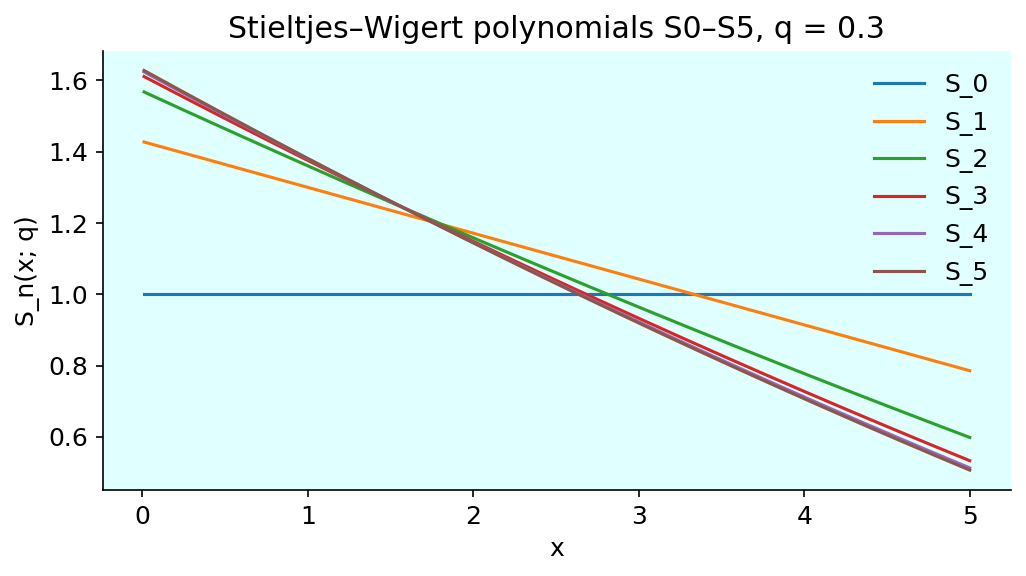

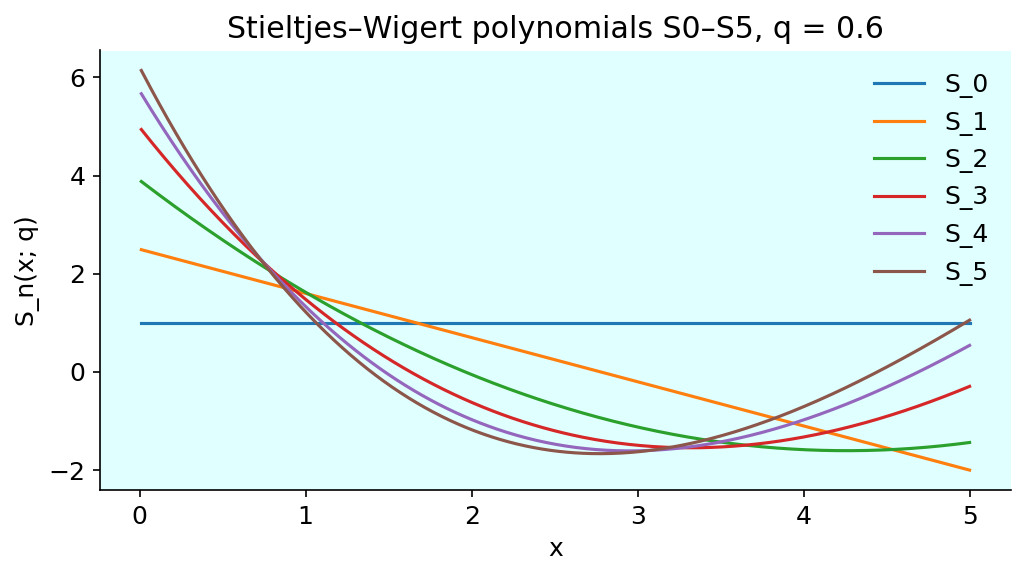

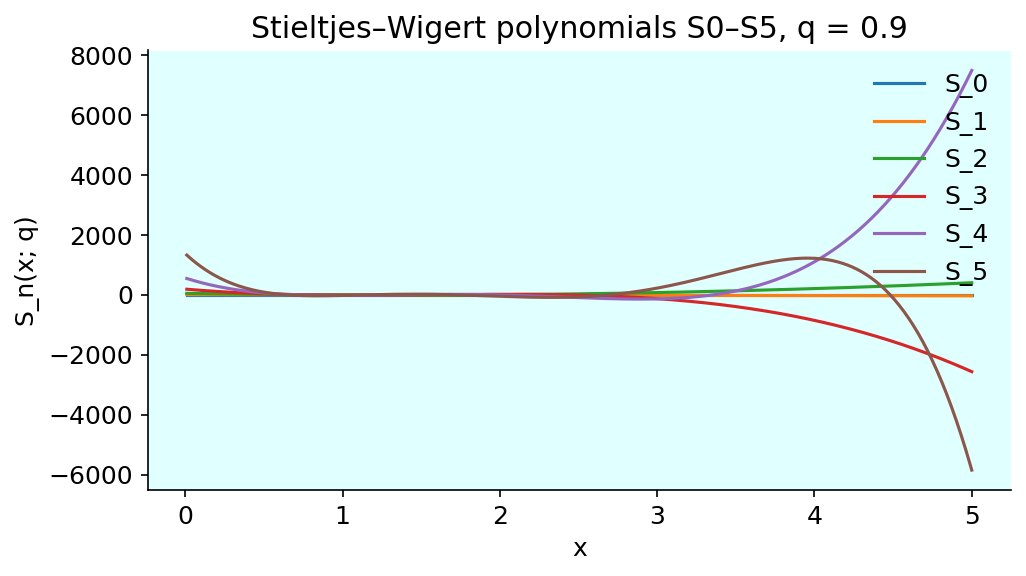

In [10]:
import numpy as np
import matplotlib.pyplot as plt

def sw_polynomials(x, q, max_degree):
    S = np.zeros((max_degree + 1, len(x)))
    S[0] = 1.0
    if max_degree >= 1:
        S[1] = (1.0 - q**2 * x) / (1.0 - q)
    for n in range(1, max_degree):
        qn1 = q**(n + 1)
        num = (1.0 + q - qn1) * S[n] - q * S[n-1] - q**(2*n+1) * x * S[n]
        den = 1.0 - qn1
        S[n+1] = num / den
    return S

qs = [0.3, 0.6, 0.9]
max_degree = 5
x = np.linspace(0.01, 5.0, 500)
colors = ['C0', 'C1', 'C2', 'C3', 'C4', 'C5']  # S0..S5

for q in qs:
    S = sw_polynomials(x, q, max_degree)

    plt.figure(figsize=(7, 4))
    ax = plt.gca()
    ax.set_facecolor("#E0FFFF")  # آبی فیروزه‌ای خیلی روشن (light cyan)
    ax.grid(False)               # حذف گرید

    for n in range(max_degree + 1):
        plt.plot(x, S[n], label=f"S_{n}", color=colors[n])

    plt.title(f"Stieltjes–Wigert polynomials S0–S5, q = {q}")
    plt.xlabel("x")
    plt.ylabel("S_n(x; q)")
    plt.legend()
    plt.tight_layout()

plt.show()


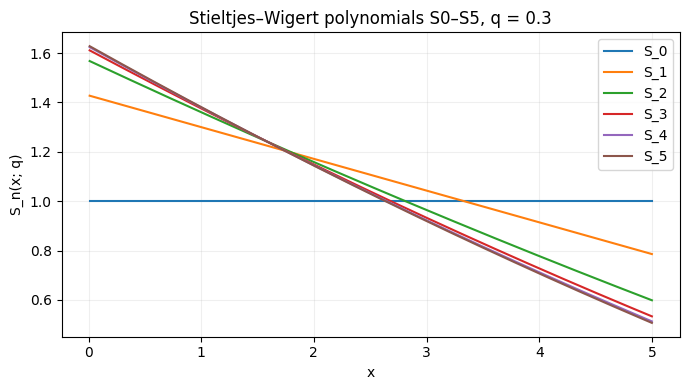

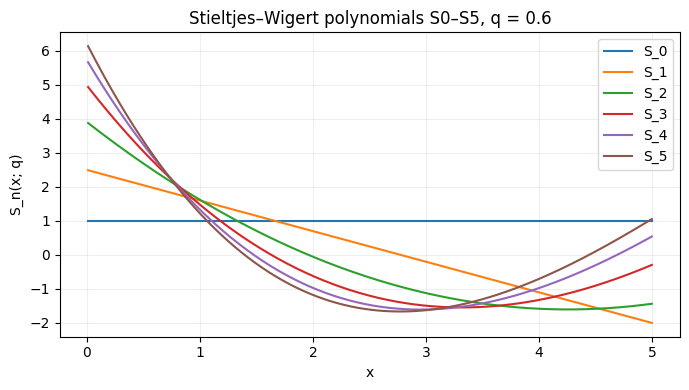

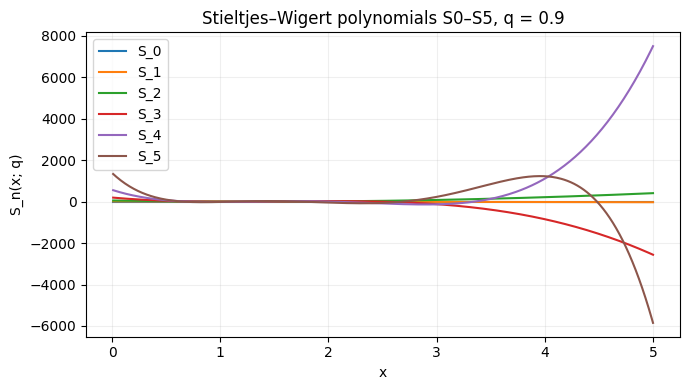

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def sw_polynomials(x, q, max_degree):
    S = np.zeros((max_degree + 1, len(x)))
    S[0] = 1.0
    if max_degree >= 1:
        S[1] = (1.0 - q**2 * x) / (1.0 - q)
    for n in range(1, max_degree):
        qn1 = q**(n + 1)
        num = (1.0 + q - qn1) * S[n] - q * S[n-1] - q**(2*n+1) * x * S[n]
        den = 1.0 - qn1
        S[n+1] = num / den
    return S

qs = [0.3, 0.6, 0.9]
max_degree = 5
x = np.linspace(0.01, 5.0, 500)
colors = ['C0', 'C1', 'C2', 'C3', 'C4', 'C5']  # S0..S5

for q in qs:
    S = sw_polynomials(x, q, max_degree)

    plt.figure(figsize=(7, 4))
    for n in range(max_degree + 1):
        plt.plot(x, S[n], label=f"S_{n}", color=colors[n])
    plt.title(f"Stieltjes–Wigert polynomials S0–S5, q = {q}")
    plt.xlabel("x")
    plt.ylabel("S_n(x; q)")
    plt.legend()
    plt.grid(alpha=0.2)
    plt.tight_layout()

plt.show()


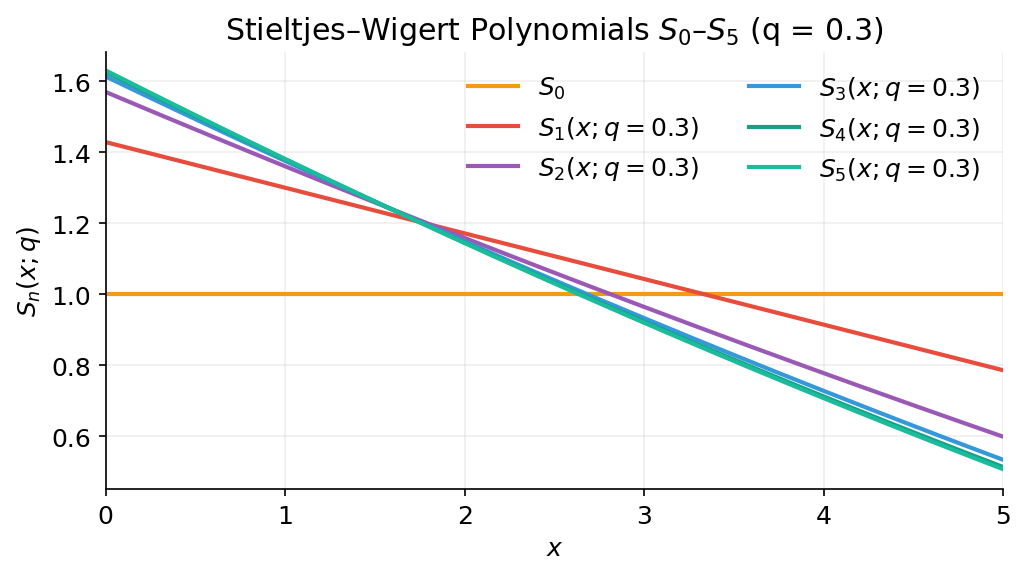

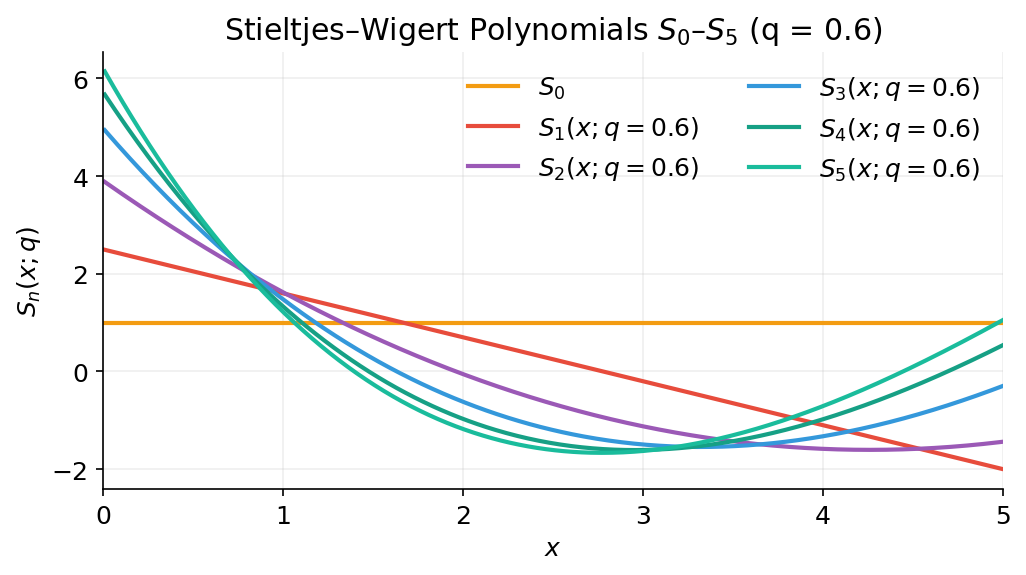

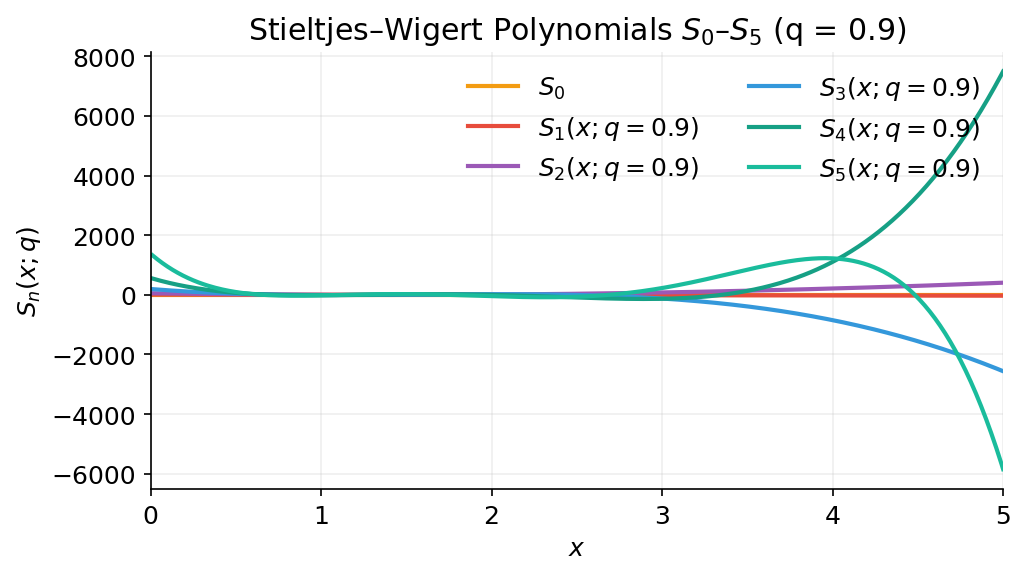

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams

# --- Matplotlib global style (for paper-quality figures) ---
rcParams["figure.dpi"] = 150
rcParams["font.size"] = 12
rcParams["axes.spines.top"] = False
rcParams["axes.spines.right"] = False
rcParams["axes.grid"] = True
rcParams["grid.alpha"] = 0.2
rcParams["legend.frameon"] = False

def sw_polynomials(x, q, max_degree):
    S = np.zeros((max_degree + 1, len(x)))
    S[0] = 1.0
    if max_degree >= 1:
        S[1] = (1.0 - q**2 * x) / (1.0 - q)
    for n in range(1, max_degree):
        qn1 = q**(n + 1)
        num = (1.0 + q - qn1) * S[n] - q * S[n-1] - q**(2*n+1) * x * S[n]
        den = 1.0 - qn1
        S[n+1] = num / den
    return S

qs = [0.3, 0.6, 0.9]
max_degree = 5
x = np.linspace(0.01, 5.0, 500)

# ثابت نگه داشتن رنگ هر درجه در همه‌ی نمودارها
colors = [
    "#F39C12",  # S0
    "#E74C3C",  # S1
    "#9B59B6",  # S2
    "#3498DB",  # S3
    "#16A085",  # S4
    "#1ABC9C",  # S5
]

for q in qs:
    S = sw_polynomials(x, q, max_degree)

    plt.figure(figsize=(7, 4))
    for n in range(max_degree + 1):
        plt.plot(
            x,
            S[n],
            label=f"$S_{n}(x; q={q})$" if n > 0 else "$S_0$",
            color=colors[n],
            linewidth=2,
        )

    plt.title(f"Stieltjes–Wigert Polynomials $S_0$–$S_5$ (q = {q})")
    plt.xlabel("$x$")
    plt.ylabel("$S_n(x; q)$")
    plt.xlim(0, 5)
    plt.legend(loc="upper right", ncol=2)
    plt.tight_layout()
    # برای ذخیره‌ی فایل های‌کوالیتی:
    # plt.savefig(f\"sw_s0_s5_q_{q}.pdf\", bbox_inches=\"tight\")  # برای مقاله
    # plt.savefig(f\"sw_s0_s5_q_{q}.png\", dpi=300, bbox_inches=\"tight\")

plt.show()


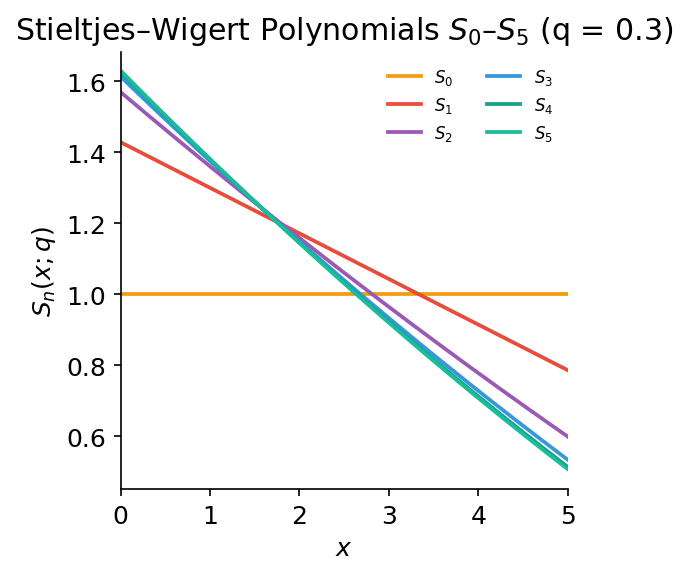

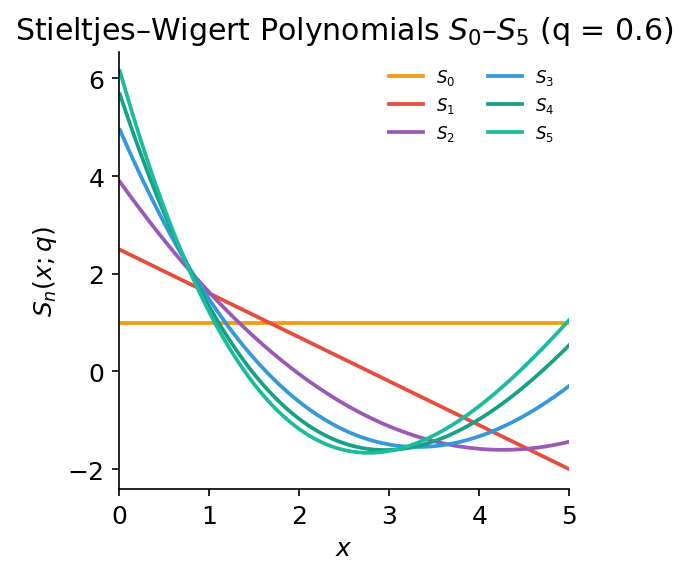

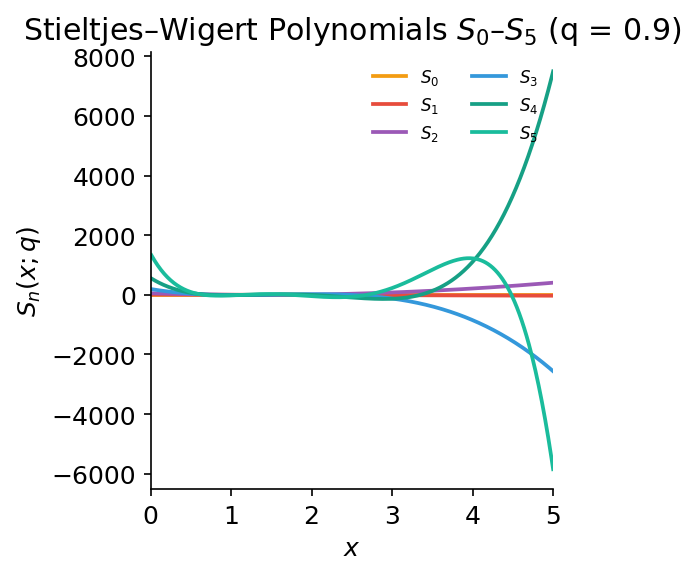

In [9]:
for q in qs:
    S = sw_polynomials(x, q, max_degree)

    plt.figure(figsize=(4, 4))   # مربع و کوچک‌تر
    ax = plt.gca()
    ax.grid(False)               # بدون گرید

    for n in range(max_degree + 1):
        plt.plot(
            x,
            S[n],
            label=f"$S_{n}$",
            color=colors[n],
            linewidth=1.8,
        )

    plt.title(f"Stieltjes–Wigert Polynomials $S_0$–$S_5$ (q = {q})")
    plt.xlabel("$x$")
    plt.ylabel("$S_n(x; q)$")
    plt.xlim(0, 5)
    plt.legend(loc="upper right", ncol=2, fontsize=8)
    plt.tight_layout()


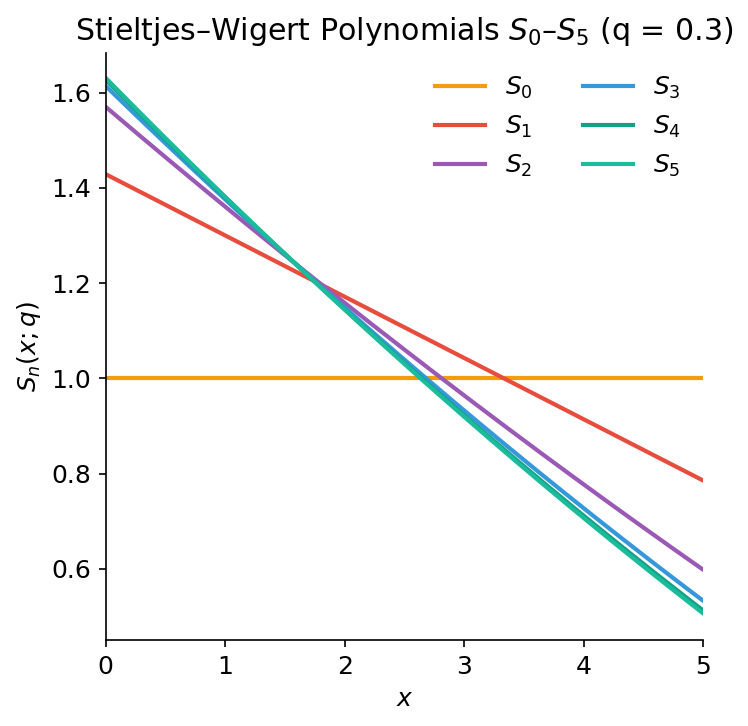

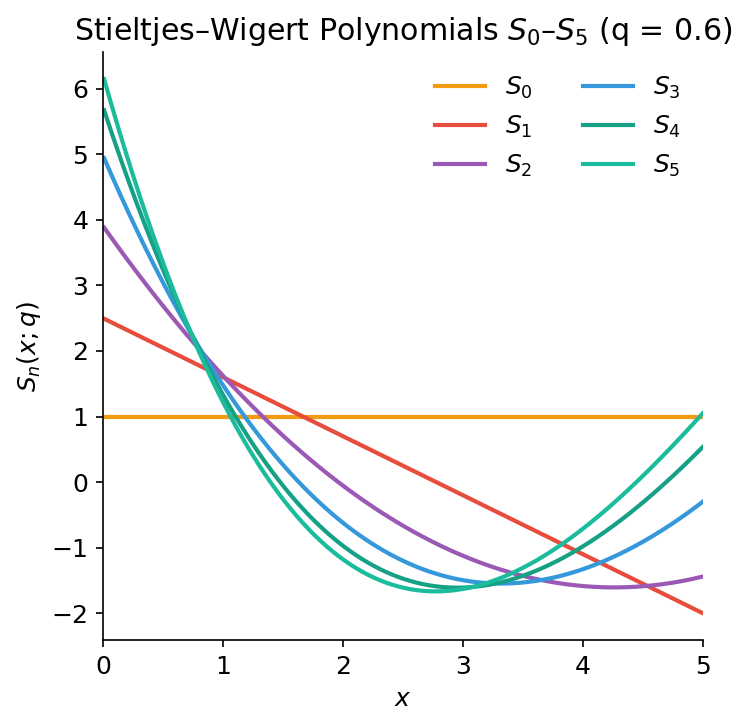

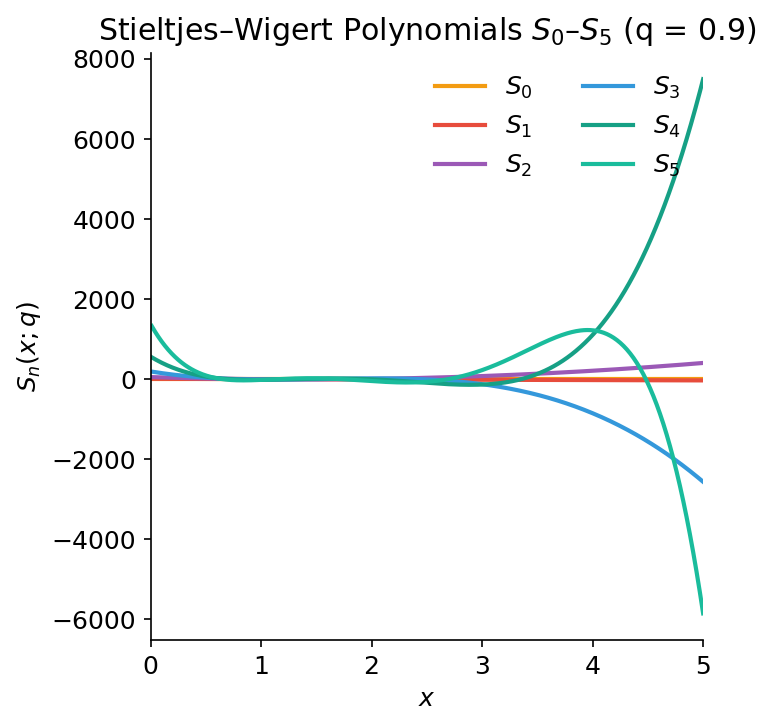

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams

# --- Matplotlib style ---
rcParams["figure.dpi"] = 150
rcParams["font.size"] = 12
rcParams["axes.spines.top"] = False
rcParams["axes.spines.right"] = False
rcParams["axes.facecolor"] = "white"   # پس‌زمینه سفید
rcParams["figure.facecolor"] = "white"
rcParams["legend.frameon"] = False

def sw_polynomials(x, q, max_degree):
    S = np.zeros((max_degree + 1, len(x)))
    S[0] = 1.0
    if max_degree >= 1:
        S[1] = (1.0 - q**2 * x) / (1.0 - q)
    for n in range(1, max_degree):
        qn1 = q**(n + 1)
        num = (1.0 + q - qn1) * S[n] - q * S[n-1] - q**(2*n+1) * x * S[n]
        den = 1.0 - qn1
        S[n+1] = num / den
    return S

qs = [0.3, 0.6, 0.9]
max_degree = 5
x = np.linspace(0.01, 5.0, 500)

colors = [
    "#F39C12",  # S0
    "#E74C3C",  # S1
    "#9B59B6",  # S2
    "#3498DB",  # S3
    "#16A085",  # S4
    "#1ABC9C",  # S5
]

for q in qs:
    S = sw_polynomials(x, q, max_degree)

    plt.figure(figsize=(5, 5))          # مربع و بزرگ‌تر
    ax = plt.gca()
    ax.grid(False)                      # بدون گرید

    for n in range(max_degree + 1):
        plt.plot(
            x,
            S[n],
            label=f"$S_{n}$",
            color=colors[n],
            linewidth=2,
        )

    plt.title(f"Stieltjes–Wigert Polynomials $S_0$–$S_5$ (q = {q})")
    plt.xlabel("$x$")
    plt.ylabel("$S_n(x; q)$")
    plt.xlim(0, 5)
    plt.legend(loc="upper right", ncol=2)
    plt.tight_layout()
    # برای خروجی مقاله:
    # plt.savefig(f"sw_s0_s5_q_{q}.pdf", bbox_inches="tight")
    # plt.savefig(f"sw_s0_s5_q_{q}.png", dpi=300, bbox_inches="tight")

plt.show()


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import time

# --- ۱. محاسبه چندجمله‌ای استیلتیس-ویگرت (نسخه پایدار) ---
def stieltjes_wigert_polynomials_fast(x, degree, q_param):
    """
    محاسبه سریع چندجمله‌ای‌های استیلتیس-ویگرت با رابطه بازگشتی
    
    Args:
        x: ورودی با shape [batch, input_dim]
        degree: درجه چندجمله‌ای
        q_param: پارامتر q (اسکالر) - قابل یادگیری
        
    Returns:
        تنسور چندجمله‌ای‌ها با shape [batch, input_dim, degree+1]
    """
    batch_size, input_dim = x.shape
    
    # محدود کردن q به بازه (0, 1)
    q = torch.sigmoid(q_param) * 0.99 + 0.005
    
    # تبدیل ورودی به فضای مثبت
    x_pos = torch.exp(torch.tanh(x) * 2)  # تبدیل به مقادیر مثبت
    
    # محاسبه پایه‌ها با رابطه بازگشتی
    # W_0 = 1
    polynomials = [torch.ones_like(x_pos)]
    
    if degree >= 1:
        # W_1 = 1 - q*x
        # q اسکالر است، پس مستقیماً ضرب می‌کنیم
        W1 = 1 - q * x_pos
        polynomials.append(W1)
    
    # رابطه بازگشتی: W_{n+1} = (1 - q^{n+1} x) W_n - q^n x W_{n-1}
    for n in range(1, degree):
        n_float = float(n)
        q_pow_n1 = q ** (n_float + 1)  # اسکالر
        q_pow_n = q ** n_float  # اسکالر
        
        term1 = (1 - q_pow_n1 * x_pos) * polynomials[-1]
        term2 = q_pow_n * x_pos * polynomials[-2]
        W_next = term1 - term2
        polynomials.append(W_next)
    
    # Stack along last dimension: [batch, input_dim, degree+1]
    return torch.stack(polynomials, dim=-1)


# --- ۲. لایه Stieltjes-Wigert KAN (اصلاح شده) ---
class StieltjesWigertKANLayer(nn.Module):
    def __init__(self, input_dim, output_dim, degree=3, learnable_q=True):
        super(StieltjesWigertKANLayer, self).__init__()
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.degree = degree
        
        # وزن‌های ترکیب خطی: [output_dim, input_dim, degree+1]
        self.weights = nn.Parameter(torch.randn(output_dim, input_dim, degree + 1) * 0.02)
        
        # بایاس
        self.bias = nn.Parameter(torch.zeros(output_dim))
        
        # پارامتر q (قابل یادگیری)
        if learnable_q:
            # مقدار اولیه: q = 0.5 (logit = 0)
            self.q_param = nn.Parameter(torch.tensor(0.5))
        else:
            self.register_buffer('q_param', torch.tensor(0.5))
    
    def forward(self, x):
        """
        Args:
            x: ورودی با shape [batch, input_dim] 
        Returns:
            خروجی با shape [batch, output_dim]
        """
        # اگر x بیش از 2 بعد دارد، flatten کنیم
        original_shape = x.shape
        if x.dim() > 2:
            batch_size = original_shape[0]
            x = x.view(batch_size, -1)
            self.input_dim = x.shape[1]
        
        batch_size = x.shape[0]
        
        # محاسبه چندجمله‌ای‌ها
        # polynomials: [batch, input_dim, degree+1]
        polynomials = stieltjes_wigert_polynomials_fast(x, self.degree, self.q_param)
        
        # روش صحیح ضرب: استفاده از حلقه برای جلوگیری از خطای ابعاد
        output = torch.zeros(batch_size, self.output_dim, device=x.device)
        
        for i in range(self.output_dim):
            for j in range(self.input_dim):
                for k in range(self.degree + 1):
                    output[:, i] += polynomials[:, j, k] * self.weights[i, j, k]
        
        output += self.bias
        
        return output


# --- ۳. لایه KAN سریع‌تر با استفاده از einsum (با بررسی ابعاد) ---
class StieltjesWigertKANLayerFast(nn.Module):
    def __init__(self, input_dim, output_dim, degree=3, learnable_q=True):
        super(StieltjesWigertKANLayerFast, self).__init__()
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.degree = degree
        
        # وزن‌های ترکیب خطی: [output_dim, input_dim, degree+1]
        self.weights = nn.Parameter(torch.randn(output_dim, input_dim, degree + 1) * 0.02)
        
        # بایاس
        self.bias = nn.Parameter(torch.zeros(output_dim))
        
        # پارامتر q (قابل یادگیری)
        if learnable_q:
            self.q_param = nn.Parameter(torch.tensor(0.5))
        else:
            self.register_buffer('q_param', torch.tensor(0.5))
    
    def forward(self, x):
        # Flatten if needed
        if x.dim() > 2:
            batch_size = x.shape[0]
            x = x.view(batch_size, -1)
        
        batch_size = x.shape[0]
        
        # محاسبه چندجمله‌ای‌ها
        polynomials = stieltjes_wigert_polynomials_fast(x, self.degree, self.q_param)
        
        # استفاده از einsum با ابعاد درست
        # polynomials: [batch, input_dim, degree+1]
        # weights: [output_dim, input_dim, degree+1]
        # output: [batch, output_dim]
        output = torch.einsum('b i d, o i d -> b o', polynomials, self.weights)
        output += self.bias
        
        return output


# --- ۴. مدل کامل برای MNIST ---
class StieltjesWigertKANMNIST(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=64, num_classes=10, degree=4, use_fast=True):
        super(StieltjesWigertKANMNIST, self).__init__()
        
        self.flatten = nn.Flatten()
        
        # انتخاب نوع لایه
        layer_class = StieltjesWigertKANLayerFast if use_fast else StieltjesWigertKANLayer
        
        # لایه‌های KAN
        self.kan1 = layer_class(input_dim, hidden_dim, degree=degree)
        self.norm1 = nn.LayerNorm(hidden_dim)
        self.act1 = nn.ReLU()
        self.drop1 = nn.Dropout(0.1)
        
        self.kan2 = layer_class(hidden_dim, hidden_dim, degree=degree)
        self.norm2 = nn.LayerNorm(hidden_dim)
        self.act2 = nn.ReLU()
        self.drop2 = nn.Dropout(0.1)
        
        self.kan3 = layer_class(hidden_dim, num_classes, degree=degree)
    
    def forward(self, x):
        x = self.flatten(x)
        
        x = self.kan1(x)
        x = self.norm1(x)
        x = self.act1(x)
        x = self.drop1(x)
        
        x = self.kan2(x)
        x = self.norm2(x)
        x = self.act2(x)
        x = self.drop2(x)
        
        x = self.kan3(x)
        
        return x


# --- ۵. تابع آموزش ---
def train_mnist(epochs=10, batch_size=64, device='cuda', use_fast=True):
    print("=" * 60)
    print("آموزش Stieltjes-Wigert KAN روی MNIST")
    print(f"Device: {device}")
    print(f"Epochs: {epochs}")
    print(f"Batch size: {batch_size}")
    print(f"Using fast layer: {use_fast}")
    print("=" * 60)
    
    # آماده‌سازی داده‌ها
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ])
    
    train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
    test_dataset = datasets.MNIST('./data', train=False, transform=transform)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
    test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False, num_workers=0)
    
    # ایجاد مدل
    model = StieltjesWigertKANMNIST(
        input_dim=784,
        hidden_dim=64,
        num_classes=10,
        degree=4,
        use_fast=use_fast
    ).to(device)
    
    # بهینه‌ساز
    optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss()
    
    # آمار
    train_losses = []
    test_accuracies = []
    
    print("\nشروع آموزش...")
    print("-" * 60)
    
    for epoch in range(1, epochs + 1):
        model.train()
        start_time = time.time()
        train_loss = 0
        
        for batch_idx, (data, target) in enumerate(train_loader):
            data, target = data.to(device), target.to(device)
            
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            
            # گرادیان clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()
            
            train_loss += loss.item()
        
        # ارزیابی
        model.eval()
        correct = 0
        total = 0
        
        with torch.no_grad():
            for data, target in test_loader:
                data, target = data.to(device), target.to(device)
                output = model(data)
                pred = output.argmax(dim=1)
                correct += pred.eq(target).sum().item()
                total += target.size(0)
        
        accuracy = 100. * correct / total
        avg_loss = train_loss / len(train_loader)
        
        # ذخیره آمار
        train_losses.append(avg_loss)
        test_accuracies.append(accuracy)
        
        # نمایش مقادیر q
        q_values = []
        for name, param in model.named_parameters():
            if 'q_param' in name:
                q = torch.sigmoid(param) * 0.99 + 0.005
                q_values.append(f"{name.split('.')[-1]}: {q.item():.3f}")
        
        scheduler.step()
        
        # نمایش پیشرفت
        time_elapsed = time.time() - start_time
        print(f"Epoch {epoch:2d}/{epochs} | Loss: {avg_loss:.4f} | Acc: {accuracy:.2f}% | "
              f"Time: {time_elapsed:.1f}s")
        
        if q_values:
            print(f"   q_values: {', '.join(q_values)}")
    
    print("-" * 60)
    print(f"بهترین دقت: {max(test_accuracies):.2f}%")
    print(f"میانگین دقت (5 دوره آخر): {sum(test_accuracies[-5:])/5:.2f}%")
    
    return model, train_losses, test_accuracies


# --- ۶. اجرای اصلی ---
if __name__ == '__main__':
    # تنظیمات
    EPOCHS = 15
    BATCH_SIZE = 64
    USE_FAST = True  # استفاده از نسخه سریع‌تر
    
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # آموزش مدل
    model, losses, accuracies = train_mnist(
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        device=DEVICE,
        use_fast=USE_FAST
    )
    
    # ذخیره مدل
    torch.save(model.state_dict(), 'stieltjes_wigert_kan_mnist.pth')
    print(f"\n✅ مدل ذخیره شد: stieltjes_wigert_kan_mnist.pth")
    
    # نمایش خلاصه
    print(f"\n📊 خلاصه نتایج:")
    print(f"   - دقت نهایی: {accuracies[-1]:.2f}%")
    print(f"   - بهترین دقت: {max(accuracies):.2f}%")
    print(f"   - میانگین تلفات: {sum(losses)/len(losses):.4f}")

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import time

# --- ۱. محاسبه چندجمله‌ای استیلتیس-ویگرت (نسخه پایدار) ---
def stieltjes_wigert_polynomials_fast(x, degree, q_param):
    """
    محاسبه سریع چندجمله‌ای‌های استیلتیس-ویگرت با رابطه بازگشتی
    
    Args:
        x: ورودی با shape [batch, input_dim]
        degree: درجه چندجمله‌ای
        q_param: پارامتر q (اسکالر) - قابل یادگیری
        
    Returns:
        تنسور چندجمله‌ای‌ها با shape [batch, input_dim, degree+1]
    """
    batch_size, input_dim = x.shape
    
    # محدود کردن q به بازه (0, 1)
    q = torch.sigmoid(q_param) * 0.99 + 0.005
    
    # تبدیل ورودی به فضای مثبت
    x_pos = torch.exp(torch.tanh(x) * 2)  # تبدیل به مقادیر مثبت
    
    # محاسبه پایه‌ها با رابطه بازگشتی
    # W_0 = 1
    polynomials = [torch.ones_like(x_pos)]
    
    if degree >= 1:
        # W_1 = 1 - q*x
        # q اسکالر است، پس مستقیماً ضرب می‌کنیم
        W1 = 1 - q * x_pos
        polynomials.append(W1)
    
    # رابطه بازگشتی: W_{n+1} = (1 - q^{n+1} x) W_n - q^n x W_{n-1}
    for n in range(1, degree):
        n_float = float(n)
        q_pow_n1 = q ** (n_float + 1)  # اسکالر
        q_pow_n = q ** n_float  # اسکالر
        
        term1 = (1 - q_pow_n1 * x_pos) * polynomials[-1]
        term2 = q_pow_n * x_pos * polynomials[-2]
        W_next = term1 - term2
        polynomials.append(W_next)
    
    # Stack along last dimension: [batch, input_dim, degree+1]
    return torch.stack(polynomials, dim=-1)


# --- ۲. لایه Stieltjes-Wigert KAN (بدون بایاس) ---
class StieltjesWigertKANLayer(nn.Module):
    def __init__(self, input_dim, output_dim, degree=3, learnable_q=True):
        super(StieltjesWigertKANLayer, self).__init__()
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.degree = degree
        
        # وزن‌های ترکیب خطی: [output_dim, input_dim, degree+1]
        self.weights = nn.Parameter(torch.randn(output_dim, input_dim, degree + 1) * 0.02)
        
        # پارامتر q (قابل یادگیری) - بدون بایاس
        if learnable_q:
            # مقدار اولیه: q = 0.5 (logit = 0)
            self.q_param = nn.Parameter(torch.tensor(0.5))
        else:
            self.register_buffer('q_param', torch.tensor(0.5))
    
    def forward(self, x):
        """
        Args:
            x: ورودی با shape [batch, input_dim] 
        Returns:
            خروجی با shape [batch, output_dim] (بدون بایاس)
        """
        # اگر x بیش از 2 بعد دارد، flatten کنیم
        original_shape = x.shape
        if x.dim() > 2:
            batch_size = original_shape[0]
            x = x.view(batch_size, -1)
            self.input_dim = x.shape[1]
        
        batch_size = x.shape[0]
        
        # محاسبه چندجمله‌ای‌ها
        # polynomials: [batch, input_dim, degree+1]
        polynomials = stieltjes_wigert_polynomials_fast(x, self.degree, self.q_param)
        
        # روش صحیح ضرب: استفاده از حلقه برای جلوگیری از خطای ابعاد
        output = torch.zeros(batch_size, self.output_dim, device=x.device)
        
        for i in range(self.output_dim):
            for j in range(self.input_dim):
                for k in range(self.degree + 1):
                    output[:, i] += polynomials[:, j, k] * self.weights[i, j, k]
        
        # بدون بایاس - خط output += self.bias حذف شد
        
        return output


# --- ۳. لایه KAN سریع‌تر با استفاده از einsum (بدون بایاس) ---
class StieltjesWigertKANLayerFast(nn.Module):
    def __init__(self, input_dim, output_dim, degree=3, learnable_q=True):
        super(StieltjesWigertKANLayerFast, self).__init__()
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.degree = degree
        
        # وزن‌های ترکیب خطی: [output_dim, input_dim, degree+1]
        self.weights = nn.Parameter(torch.randn(output_dim, input_dim, degree + 1) * 0.02)
        
        # پارامتر q (قابل یادگیری) - بدون بایاس
        if learnable_q:
            self.q_param = nn.Parameter(torch.tensor(0.5))
        else:
            self.register_buffer('q_param', torch.tensor(0.5))
    
    def forward(self, x):
        # Flatten if needed
        if x.dim() > 2:
            batch_size = x.shape[0]
            x = x.view(batch_size, -1)
        
        batch_size = x.shape[0]
        
        # محاسبه چندجمله‌ای‌ها
        polynomials = stieltjes_wigert_polynomials_fast(x, self.degree, self.q_param)
        
        # استفاده از einsum با ابعاد درست
        # polynomials: [batch, input_dim, degree+1]
        # weights: [output_dim, input_dim, degree+1]
        # output: [batch, output_dim] (بدون بایاس)
        output = torch.einsum('b i d, o i d -> b o', polynomials, self.weights)
        
        # بدون بایاس - خط output += self.bias حذف شد
        
        return output


# --- ۴. مدل کامل برای MNIST (با لایه‌های بدون بایاس) ---
class StieltjesWigertKANMNIST(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=64, num_classes=10, degree=4, use_fast=True):
        super(StieltjesWigertKANMNIST, self).__init__()
        
        self.flatten = nn.Flatten()
        
        # انتخاب نوع لایه
        layer_class = StieltjesWigertKANLayerFast if use_fast else StieltjesWigertKANLayer
        
        # لایه‌های KAN (بدون بایاس)
        self.kan1 = layer_class(input_dim, hidden_dim, degree=degree)
        self.norm1 = nn.LayerNorm(hidden_dim)
        self.act1 = nn.ReLU()
        self.drop1 = nn.Dropout(0.1)
        
        self.kan2 = layer_class(hidden_dim, hidden_dim, degree=degree)
        self.norm2 = nn.LayerNorm(hidden_dim)
        self.act2 = nn.ReLU()
        self.drop2 = nn.Dropout(0.1)
        
        self.kan3 = layer_class(hidden_dim, num_classes, degree=degree)
    
    def forward(self, x):
        x = self.flatten(x)
        
        x = self.kan1(x)
        x = self.norm1(x)
        x = self.act1(x)
        x = self.drop1(x)
        
        x = self.kan2(x)
        x = self.norm2(x)
        x = self.act2(x)
        x = self.drop2(x)
        
        x = self.kan3(x)
        
        return x


# --- ۵. تابع آموزش ---
def train_mnist(epochs=10, batch_size=64, device='cuda', use_fast=True):
    print("=" * 60)
    print("آموزش Stieltjes-Wigert KAN روی MNIST (بدون بایاس)")
    print(f"Device: {device}")
    print(f"Epochs: {epochs}")
    print(f"Batch size: {batch_size}")
    print(f"Using fast layer: {use_fast}")
    print("=" * 60)
    
    # آماده‌سازی داده‌ها
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ])
    
    train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
    test_dataset = datasets.MNIST('./data', train=False, transform=transform)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
    test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False, num_workers=0)
    
    # ایجاد مدل
    model = StieltjesWigertKANMNIST(
        input_dim=784,
        hidden_dim=64,
        num_classes=10,
        degree=3,
        use_fast=use_fast
    ).to(device)
    
    # بهینه‌ساز
    optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss()
    
    # آمار
    train_losses = []
    test_accuracies = []
    
    print("\nشروع آموزش...")
    print("-" * 60)
    
    for epoch in range(1, epochs + 1):
        model.train()
        start_time = time.time()
        train_loss = 0
        
        for batch_idx, (data, target) in enumerate(train_loader):
            data, target = data.to(device), target.to(device)
            
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            
            # گرادیان clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()
            
            train_loss += loss.item()
        
        # ارزیابی
        model.eval()
        correct = 0
        total = 0
        
        with torch.no_grad():
            for data, target in test_loader:
                data, target = data.to(device), target.to(device)
                output = model(data)
                pred = output.argmax(dim=1)
                correct += pred.eq(target).sum().item()
                total += target.size(0)
        
        accuracy = 100. * correct / total
        avg_loss = train_loss / len(train_loader)
        
        # ذخیره آمار
        train_losses.append(avg_loss)
        test_accuracies.append(accuracy)
        
        # نمایش مقادیر q
        q_values = []
        for name, param in model.named_parameters():
            if 'q_param' in name:
                q = torch.sigmoid(param) * 0.99 + 0.005
                q_values.append(f"{name.split('.')[-1]}: {q.item():.3f}")
        
        scheduler.step()
        
        # نمایش پیشرفت
        time_elapsed = time.time() - start_time
        print(f"Epoch {epoch:2d}/{epochs} | Loss: {avg_loss:.4f} | Acc: {accuracy:.2f}% | "
              f"Time: {time_elapsed:.1f}s")
        
        if q_values:
            print(f"   q_values: {', '.join(q_values)}")
    
    print("-" * 60)
    print(f"بهترین دقت: {max(test_accuracies):.2f}%")
    print(f"میانگین دقت (5 دوره آخر): {sum(test_accuracies[-5:])/5:.2f}%")
    
    return model, train_losses, test_accuracies


# --- ۶. محاسبه تعداد پارامترها (برای مقایسه) ---
def count_parameters(model):
    """محاسبه تعداد کل پارامترهای قابل یادگیری مدل"""
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    
    print("\n" + "=" * 60)
    print("📊 آنالیز پارامترهای مدل (بدون بایاس)")
    print("=" * 60)
    
    for name, param in model.named_parameters():
        if param.requires_grad:
            num_params = param.numel()
            print(f"{name:30s}: {num_params:10,d} پارامتر | shape: {list(param.shape)}")
    
    print("-" * 60)
    print(f"جمع کل پارامترهای قابل یادگیری: {total_params:,} پارامتر")
    print("=" * 60)
    
    return total_params


# --- ۷. اجرای اصلی ---
if __name__ == '__main__':
    # تنظیمات
    EPOCHS = 50
    BATCH_SIZE = 64
    USE_FAST = True  # استفاده از نسخه سریع‌تر
    
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # ایجاد مدل برای شمارش پارامترها
    sample_model = StieltjesWigertKANMNIST(
        input_dim=784,
        hidden_dim=64,
        num_classes=10,
        degree=3,
        use_fast=USE_FAST
    ).to(DEVICE)
    
    # شمارش پارامترها
    total_params = count_parameters(sample_model)
    
    # آموزش مدل
    model, losses, accuracies = train_mnist(
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        device=DEVICE,
        use_fast=USE_FAST
    )
    
    # ذخیره مدل
    torch.save(model.state_dict(), 'stieltjes_wigert_kan_mnist_no_bias.pth')
    print(f"\n✅ مدل ذخیره شد: stieltjes_wigert_kan_mnist_no_bias.pth")
    
    # نمایش خلاصه
    print(f"\n📊 خلاصه نتایج (بدون بایاس):")
    print(f"   - تعداد کل پارامترها: {total_params:,}")
    print(f"   - دقت نهایی: {accuracies[-1]:.2f}%")
    print(f"   - بهترین دقت: {max(accuracies):.2f}%")
    print(f"   - میانگین تلفات: {sum(losses)/len(losses):.4f}")

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import time

# --- ۱. محاسبه چندجمله‌ای استیلتیس-ویگرت (نسخه پایدار) ---
def stieltjes_wigert_polynomials_fast(x, degree, q_param):
    """
    محاسبه سریع چندجمله‌ای‌های استیلتیس-ویگرت با رابطه بازگشتی
    
    Args:
        x: ورودی با shape [batch, input_dim]
        degree: درجه چندجمله‌ای
        q_param: پارامتر q (اسکالر) - قابل یادگیری
        
    Returns:
        تنسور چندجمله‌ای‌ها با shape [batch, input_dim, degree+1]
    """
    batch_size, input_dim = x.shape
    
    # محدود کردن q به بازه (0, 1)
    q = torch.sigmoid(q_param) * 0.99 + 0.005
    
    # تبدیل ورودی به فضای مثبت
    x_pos = torch.exp(torch.tanh(x) * 2)  # تبدیل به مقادیر مثبت
    
    # محاسبه پایه‌ها با رابطه بازگشتی
    # W_0 = 1
    polynomials = [torch.ones_like(x_pos)]
    
    if degree >= 1:
        # W_1 = 1 - q*x
        # q اسکالر است، پس مستقیماً ضرب می‌کنیم
        W1 = 1 - q * x_pos
        polynomials.append(W1)
    
    # رابطه بازگشتی: W_{n+1} = (1 - q^{n+1} x) W_n - q^n x W_{n-1}
    for n in range(1, degree):
        n_float = float(n)
        q_pow_n1 = q ** (n_float + 1)  # اسکالر
        q_pow_n = q ** n_float  # اسکالر
        
        term1 = (1 - q_pow_n1 * x_pos) * polynomials[-1]
        term2 = q_pow_n * x_pos * polynomials[-2]
        W_next = term1 - term2
        polynomials.append(W_next)
    
    # Stack along last dimension: [batch, input_dim, degree+1]
    return torch.stack(polynomials, dim=-1)


# --- ۲. لایه Stieltjes-Wigert KAN (بدون بایاس) ---
class StieltjesWigertKANLayer(nn.Module):
    def __init__(self, input_dim, output_dim, degree=3, learnable_q=True):
        super(StieltjesWigertKANLayer, self).__init__()
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.degree = degree
        
        # وزن‌های ترکیب خطی: [output_dim, input_dim, degree+1]
        self.weights = nn.Parameter(torch.randn(output_dim, input_dim, degree + 1) * 0.02)
        
        # پارامتر q (قابل یادگیری) - بدون بایاس
        if learnable_q:
            # مقدار اولیه: q = 0.5 (logit = 0)
            self.q_param = nn.Parameter(torch.tensor(0.5))
        else:
            self.register_buffer('q_param', torch.tensor(0.5))
    
    def forward(self, x):
        """
        Args:
            x: ورودی با shape [batch, input_dim] 
        Returns:
            خروجی با shape [batch, output_dim] (بدون بایاس)
        """
        # اگر x بیش از 2 بعد دارد، flatten کنیم
        original_shape = x.shape
        if x.dim() > 2:
            batch_size = original_shape[0]
            x = x.view(batch_size, -1)
            self.input_dim = x.shape[1]
        
        batch_size = x.shape[0]
        
        # محاسبه چندجمله‌ای‌ها
        # polynomials: [batch, input_dim, degree+1]
        polynomials = stieltjes_wigert_polynomials_fast(x, self.degree, self.q_param)
        
        # روش صحیح ضرب: استفاده از حلقه برای جلوگیری از خطای ابعاد
        output = torch.zeros(batch_size, self.output_dim, device=x.device)
        
        for i in range(self.output_dim):
            for j in range(self.input_dim):
                for k in range(self.degree + 1):
                    output[:, i] += polynomials[:, j, k] * self.weights[i, j, k]
        
        # بدون بایاس - خط output += self.bias حذف شد
        
        return output


# --- ۳. لایه KAN سریع‌تر با استفاده از einsum (بدون بایاس) ---
class StieltjesWigertKANLayerFast(nn.Module):
    def __init__(self, input_dim, output_dim, degree=3, learnable_q=True):
        super(StieltjesWigertKANLayerFast, self).__init__()
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.degree = degree
        
        # وزن‌های ترکیب خطی: [output_dim, input_dim, degree+1]
        self.weights = nn.Parameter(torch.randn(output_dim, input_dim, degree + 1) * 0.02)
        
        # پارامتر q (قابل یادگیری) - بدون بایاس
        if learnable_q:
            self.q_param = nn.Parameter(torch.tensor(0.5))
        else:
            self.register_buffer('q_param', torch.tensor(0.5))
    
    def forward(self, x):
        # Flatten if needed
        if x.dim() > 2:
            batch_size = x.shape[0]
            x = x.view(batch_size, -1)
        
        batch_size = x.shape[0]
        
        # محاسبه چندجمله‌ای‌ها
        polynomials = stieltjes_wigert_polynomials_fast(x, self.degree, self.q_param)
        
        # استفاده از einsum با ابعاد درست
        # polynomials: [batch, input_dim, degree+1]
        # weights: [output_dim, input_dim, degree+1]
        # output: [batch, output_dim] (بدون بایاس)
        output = torch.einsum('b i d, o i d -> b o', polynomials, self.weights)
        
        # بدون بایاس - خط output += self.bias حذف شد
        
        return output


# --- ۴. مدل کامل برای MNIST (با لایه‌های بدون بایاس) ---
class StieltjesWigertKANMNIST(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=64, num_classes=10, degree=4, use_fast=True):
        super(StieltjesWigertKANMNIST, self).__init__()
        
        self.flatten = nn.Flatten()
        
        # انتخاب نوع لایه
        layer_class = StieltjesWigertKANLayerFast if use_fast else StieltjesWigertKANLayer
        
        # لایه‌های KAN (بدون بایاس)
        self.kan1 = layer_class(input_dim, hidden_dim, degree=degree)
        self.norm1 = nn.LayerNorm(hidden_dim)
        self.act1 = nn.ReLU()
        self.drop1 = nn.Dropout(0.1)
        
        self.kan2 = layer_class(hidden_dim, hidden_dim, degree=degree)
        self.norm2 = nn.LayerNorm(hidden_dim)
        self.act2 = nn.ReLU()
        self.drop2 = nn.Dropout(0.1)
        
        self.kan3 = layer_class(hidden_dim, num_classes, degree=degree)
    
    def forward(self, x):
        x = self.flatten(x)
        
        x = self.kan1(x)
        x = self.norm1(x)
        x = self.act1(x)
        x = self.drop1(x)
        
        x = self.kan2(x)
        x = self.norm2(x)
        x = self.act2(x)
        x = self.drop2(x)
        
        x = self.kan3(x)
        
        return x


# --- ۵. تابع آموزش ---
def train_mnist(epochs=10, batch_size=64, device='cuda', use_fast=True):
    print("=" * 60)
    print("آموزش Stieltjes-Wigert KAN روی MNIST (بدون بایاس)")
    print(f"Device: {device}")
    print(f"Epochs: {epochs}")
    print(f"Batch size: {batch_size}")
    print(f"Using fast layer: {use_fast}")
    print("=" * 60)
    
    # آماده‌سازی داده‌ها
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ])
    
    train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
    test_dataset = datasets.MNIST('./data', train=False, transform=transform)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
    test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False, num_workers=0)
    
    # ایجاد مدل
    model = StieltjesWigertKANMNIST(
        input_dim=784,
        hidden_dim=32,
        num_classes=10,
        degree=3,
        use_fast=use_fast
    ).to(device)
    
    # بهینه‌ساز
    optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss()
    
    # آمار
    train_losses = []
    test_accuracies = []
    
    print("\nشروع آموزش...")
    print("-" * 60)
    
    for epoch in range(1, epochs + 1):
        model.train()
        start_time = time.time()
        train_loss = 0
        
        for batch_idx, (data, target) in enumerate(train_loader):
            data, target = data.to(device), target.to(device)
            
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            
            # گرادیان clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()
            
            train_loss += loss.item()
        
        # ارزیابی
        model.eval()
        correct = 0
        total = 0
        
        with torch.no_grad():
            for data, target in test_loader:
                data, target = data.to(device), target.to(device)
                output = model(data)
                pred = output.argmax(dim=1)
                correct += pred.eq(target).sum().item()
                total += target.size(0)
        
        accuracy = 100. * correct / total
        avg_loss = train_loss / len(train_loader)
        
        # ذخیره آمار
        train_losses.append(avg_loss)
        test_accuracies.append(accuracy)
        
        # نمایش مقادیر q
        q_values = []
        for name, param in model.named_parameters():
            if 'q_param' in name:
                q = torch.sigmoid(param) * 0.99 + 0.005
                q_values.append(f"{name.split('.')[-1]}: {q.item():.3f}")
        
        scheduler.step()
        
        # نمایش پیشرفت
        time_elapsed = time.time() - start_time
        print(f"Epoch {epoch:2d}/{epochs} | Loss: {avg_loss:.4f} | Acc: {accuracy:.2f}% | "
              f"Time: {time_elapsed:.1f}s")
        
        if q_values:
            print(f"   q_values: {', '.join(q_values)}")
    
    print("-" * 60)
    print(f"بهترین دقت: {max(test_accuracies):.2f}%")
    print(f"میانگین دقت (5 دوره آخر): {sum(test_accuracies[-5:])/5:.2f}%")
    
    return model, train_losses, test_accuracies


# --- ۶. محاسبه تعداد پارامترها (برای مقایسه) ---
def count_parameters(model):
    """محاسبه تعداد کل پارامترهای قابل یادگیری مدل"""
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    
    print("\n" + "=" * 60)
    print("📊 آنالیز پارامترهای مدل (بدون بایاس)")
    print("=" * 60)
    
    for name, param in model.named_parameters():
        if param.requires_grad:
            num_params = param.numel()
            print(f"{name:30s}: {num_params:10,d} پارامتر | shape: {list(param.shape)}")
    
    print("-" * 60)
    print(f"جمع کل پارامترهای قابل یادگیری: {total_params:,} پارامتر")
    print("=" * 60)
    
    return total_params


# --- ۷. اجرای اصلی ---
if __name__ == '__main__':
    # تنظیمات
    EPOCHS = 50
    BATCH_SIZE = 64
    USE_FAST = True  # استفاده از نسخه سریع‌تر
    
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # ایجاد مدل برای شمارش پارامترها
    sample_model = StieltjesWigertKANMNIST(
        input_dim=784,
        hidden_dim=32,
        num_classes=10,
        degree=3,
        use_fast=USE_FAST
    ).to(DEVICE)
    
    # شمارش پارامترها
    total_params = count_parameters(sample_model)
    
    # آموزش مدل
    model, losses, accuracies = train_mnist(
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        device=DEVICE,
        use_fast=USE_FAST
    )
    
    # ذخیره مدل
    torch.save(model.state_dict(), 'stieltjes_wigert_kan_mnist_no_bias.pth')
    print(f"\n✅ مدل ذخیره شد: stieltjes_wigert_kan_mnist_no_bias.pth")
    
    # نمایش خلاصه
    print(f"\n📊 خلاصه نتایج (بدون بایاس):")
    print(f"   - تعداد کل پارامترها: {total_params:,}")
    print(f"   - دقت نهایی: {accuracies[-1]:.2f}%")
    print(f"   - بهترین دقت: {max(accuracies):.2f}%")
    print(f"   - میانگین تلفات: {sum(losses)/len(losses):.4f}")

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import time

# --- ۱. محاسبه چندجمله‌ای استیلتیس-ویگرت (نسخه پایدار) ---
def stieltjes_wigert_polynomials_fast(x, degree, q_param):
    """
    محاسبه سریع چندجمله‌ای‌های استیلتیس-ویگرت با رابطه بازگشتی
    
    Args:
        x: ورودی با shape [batch, input_dim]
        degree: درجه چندجمله‌ای
        q_param: پارامتر q (اسکالر) - قابل یادگیری
        
    Returns:
        تنسور چندجمله‌ای‌ها با shape [batch, input_dim, degree+1]
    """
    batch_size, input_dim = x.shape
    
    # محدود کردن q به بازه (0, 1)
    q = torch.sigmoid(q_param) * 0.99 + 0.005
    
    # تبدیل ورودی به فضای مثبت
    x_pos = torch.exp(torch.tanh(x) * 2)  # تبدیل به مقادیر مثبت
    
    # محاسبه پایه‌ها با رابطه بازگشتی
    # W_0 = 1
    polynomials = [torch.ones_like(x_pos)]
    
    if degree >= 1:
        # W_1 = 1 - q*x
        # q اسکالر است، پس مستقیماً ضرب می‌کنیم
        W1 = 1 - q * x_pos
        polynomials.append(W1)
    
    # رابطه بازگشتی: W_{n+1} = (1 - q^{n+1} x) W_n - q^n x W_{n-1}
    for n in range(1, degree):
        n_float = float(n)
        q_pow_n1 = q ** (n_float + 1)  # اسکالر
        q_pow_n = q ** n_float  # اسکالر
        
        term1 = (1 - q_pow_n1 * x_pos) * polynomials[-1]
        term2 = q_pow_n * x_pos * polynomials[-2]
        W_next = term1 - term2
        polynomials.append(W_next)
    
    # Stack along last dimension: [batch, input_dim, degree+1]
    return torch.stack(polynomials, dim=-1)


# --- ۲. لایه Stieltjes-Wigert KAN (بدون بایاس) ---
class StieltjesWigertKANLayer(nn.Module):
    def __init__(self, input_dim, output_dim, degree=3, learnable_q=True):
        super(StieltjesWigertKANLayer, self).__init__()
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.degree = degree
        
        # وزن‌های ترکیب خطی: [output_dim, input_dim, degree+1]
        self.weights = nn.Parameter(torch.randn(output_dim, input_dim, degree + 1) * 0.02)
        
        # پارامتر q (قابل یادگیری) - بدون بایاس
        if learnable_q:
            # مقدار اولیه: q = 0.5 (logit = 0)
            self.q_param = nn.Parameter(torch.tensor(0.5))
        else:
            self.register_buffer('q_param', torch.tensor(0.5))
    
    def forward(self, x):
        """
        Args:
            x: ورودی با shape [batch, input_dim] 
        Returns:
            خروجی با shape [batch, output_dim] (بدون بایاس)
        """
        # اگر x بیش از 2 بعد دارد، flatten کنیم
        original_shape = x.shape
        if x.dim() > 2:
            batch_size = original_shape[0]
            x = x.view(batch_size, -1)
            self.input_dim = x.shape[1]
        
        batch_size = x.shape[0]
        
        # محاسبه چندجمله‌ای‌ها
        # polynomials: [batch, input_dim, degree+1]
        polynomials = stieltjes_wigert_polynomials_fast(x, self.degree, self.q_param)
        
        # روش صحیح ضرب: استفاده از حلقه برای جلوگیری از خطای ابعاد
        output = torch.zeros(batch_size, self.output_dim, device=x.device)
        
        for i in range(self.output_dim):
            for j in range(self.input_dim):
                for k in range(self.degree + 1):
                    output[:, i] += polynomials[:, j, k] * self.weights[i, j, k]
        
        # بدون بایاس - خط output += self.bias حذف شد
        
        return output


# --- ۳. لایه KAN سریع‌تر با استفاده از einsum (بدون بایاس) ---
class StieltjesWigertKANLayerFast(nn.Module):
    def __init__(self, input_dim, output_dim, degree=3, learnable_q=True):
        super(StieltjesWigertKANLayerFast, self).__init__()
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.degree = degree
        
        # وزن‌های ترکیب خطی: [output_dim, input_dim, degree+1]
        self.weights = nn.Parameter(torch.randn(output_dim, input_dim, degree + 1) * 0.02)
        
        # پارامتر q (قابل یادگیری) - بدون بایاس
        if learnable_q:
            self.q_param = nn.Parameter(torch.tensor(0.5))
        else:
            self.register_buffer('q_param', torch.tensor(0.5))
    
    def forward(self, x):
        # Flatten if needed
        if x.dim() > 2:
            batch_size = x.shape[0]
            x = x.view(batch_size, -1)
        
        batch_size = x.shape[0]
        
        # محاسبه چندجمله‌ای‌ها
        polynomials = stieltjes_wigert_polynomials_fast(x, self.degree, self.q_param)
        
        # استفاده از einsum با ابعاد درست
        # polynomials: [batch, input_dim, degree+1]
        # weights: [output_dim, input_dim, degree+1]
        # output: [batch, output_dim] (بدون بایاس)
        output = torch.einsum('b i d, o i d -> b o', polynomials, self.weights)
        
        # بدون بایاس - خط output += self.bias حذف شد
        
        return output


# --- ۴. مدل کامل برای MNIST (با لایه‌های بدون بایاس) ---
class StieltjesWigertKANMNIST(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=64, num_classes=10, degree=4, use_fast=True):
        super(StieltjesWigertKANMNIST, self).__init__()
        
        self.flatten = nn.Flatten()
        
        # انتخاب نوع لایه
        layer_class = StieltjesWigertKANLayerFast if use_fast else StieltjesWigertKANLayer
        
        # لایه‌های KAN (بدون بایاس)
        self.kan1 = layer_class(input_dim, hidden_dim, degree=degree)
        
        
        self.kan2 = layer_class(hidden_dim, hidden_dim, degree=degree)
       
        
        self.kan3 = layer_class(hidden_dim, num_classes, degree=degree)
    
    def forward(self, x):
        x = self.flatten(x)
        
        x = self.kan1(x)
        
        
        x = self.kan2(x)
        
        
        x = self.kan3(x)
        
        return x


# --- ۵. تابع آموزش ---
def train_mnist(epochs=10, batch_size=64, device='cuda', use_fast=True):
    print("=" * 60)
    print("آموزش Stieltjes-Wigert KAN روی MNIST (بدون بایاس)")
    print(f"Device: {device}")
    print(f"Epochs: {epochs}")
    print(f"Batch size: {batch_size}")
    print(f"Using fast layer: {use_fast}")
    print("=" * 60)
    
    # آماده‌سازی داده‌ها
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ])
    
    train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
    test_dataset = datasets.MNIST('./data', train=False, transform=transform)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
    test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False, num_workers=0)
    
    # ایجاد مدل
    model = StieltjesWigertKANMNIST(
        input_dim=784,
        hidden_dim=64,
        num_classes=10,
        degree=3,
        use_fast=use_fast
    ).to(device)
    
    # بهینه‌ساز
    optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss()
    
    # آمار
    train_losses = []
    test_accuracies = []
    
    print("\nشروع آموزش...")
    print("-" * 60)
    
    for epoch in range(1, epochs + 1):
        model.train()
        start_time = time.time()
        train_loss = 0
        
        for batch_idx, (data, target) in enumerate(train_loader):
            data, target = data.to(device), target.to(device)
            
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            
            # گرادیان clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()
            
            train_loss += loss.item()
        
        # ارزیابی
        model.eval()
        correct = 0
        total = 0
        
        with torch.no_grad():
            for data, target in test_loader:
                data, target = data.to(device), target.to(device)
                output = model(data)
                pred = output.argmax(dim=1)
                correct += pred.eq(target).sum().item()
                total += target.size(0)
        
        accuracy = 100. * correct / total
        avg_loss = train_loss / len(train_loader)
        
        # ذخیره آمار
        train_losses.append(avg_loss)
        test_accuracies.append(accuracy)
        
        # نمایش مقادیر q
        q_values = []
        for name, param in model.named_parameters():
            if 'q_param' in name:
                q = torch.sigmoid(param) * 0.99 + 0.005
                q_values.append(f"{name.split('.')[-1]}: {q.item():.3f}")
        
        scheduler.step()
        
        # نمایش پیشرفت
        time_elapsed = time.time() - start_time
        print(f"Epoch {epoch:2d}/{epochs} | Loss: {avg_loss:.4f} | Acc: {accuracy:.2f}% | "
              f"Time: {time_elapsed:.1f}s")
        
        if q_values:
            print(f"   q_values: {', '.join(q_values)}")
    
    print("-" * 60)
    print(f"بهترین دقت: {max(test_accuracies):.2f}%")
    print(f"میانگین دقت (5 دوره آخر): {sum(test_accuracies[-5:])/5:.2f}%")
    
    return model, train_losses, test_accuracies


# --- ۶. محاسبه تعداد پارامترها (برای مقایسه) ---
def count_parameters(model):
    """محاسبه تعداد کل پارامترهای قابل یادگیری مدل"""
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    
    print("\n" + "=" * 60)
    print("📊 آنالیز پارامترهای مدل (بدون بایاس)")
    print("=" * 60)
    
    for name, param in model.named_parameters():
        if param.requires_grad:
            num_params = param.numel()
            print(f"{name:30s}: {num_params:10,d} پارامتر | shape: {list(param.shape)}")
    
    print("-" * 60)
    print(f"جمع کل پارامترهای قابل یادگیری: {total_params:,} پارامتر")
    print("=" * 60)
    
    return total_params


# --- ۷. اجرای اصلی ---
if __name__ == '__main__':
    # تنظیمات
    EPOCHS = 50
    BATCH_SIZE = 64
    USE_FAST = True  # استفاده از نسخه سریع‌تر
    
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # ایجاد مدل برای شمارش پارامترها
    sample_model = StieltjesWigertKANMNIST(
        input_dim=784,
        hidden_dim=64,
        num_classes=10,
        degree=3,
        use_fast=USE_FAST
    ).to(DEVICE)
    
    # شمارش پارامترها
    total_params = count_parameters(sample_model)
    
    # آموزش مدل
    model, losses, accuracies = train_mnist(
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        device=DEVICE,
        use_fast=USE_FAST
    )
    
    # ذخیره مدل
    torch.save(model.state_dict(), 'stieltjes_wigert_kan_mnist_no_bias.pth')
    print(f"\n✅ مدل ذخیره شد: stieltjes_wigert_kan_mnist_no_bias.pth")
    
    # نمایش خلاصه
    print(f"\n📊 خلاصه نتایج (بدون بایاس):")
    print(f"   - تعداد کل پارامترها: {total_params:,}")
    print(f"   - دقت نهایی: {accuracies[-1]:.2f}%")
    print(f"   - بهترین دقت: {max(accuracies):.2f}%")
    print(f"   - میانگین تلفات: {sum(losses)/len(losses):.4f}")

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import time


# --- 1. Stieltjes-Wigert Polynomials (Standard Koekoek-Swarttouw Recurrence) ---
def stieltjes_wigert_polynomials(x, degree, q_param):
    """
    Compute Stieltjes-Wigert polynomials via the standard three-term recurrence
    from Koekoek-Swarttouw (1998), Section 3.27:

        -q^{2n+1} x S_n = (1 - q^{n+1}) S_{n+1} - (1 + q - q^{n+1}) S_n + q S_{n-1}

    Rearranged for S_{n+1}:
        S_{n+1} = [ (1 + q - q^{n+1}) S_n - q S_{n-1} - q^{2n+1} x S_n ] / (1 - q^{n+1})

    Args:
        x: input tensor [batch, input_dim], already mapped to (0, inf)
        degree: maximum polynomial degree K
        q_param: raw learnable scalar (passed through sigmoid to get q in (0,1))

    Returns:
        tensor [batch, input_dim, degree+1]
    """
    # Constrain q to (0.005, 0.995)
    q = torch.sigmoid(q_param) * 0.99 + 0.005

    # Map input to positive domain
    x_pos = torch.exp(2.0 * torch.tanh(x))  # in (e^{-2}, e^{2}) subset (0, inf)

    # S_0 = 1
    polynomials = [torch.ones_like(x_pos)]

    if degree >= 1:
        # S_1 from recurrence with n=0:
        #   -q x S_0 = (1 - q) S_1 - (1 + q - q) S_0 + q S_{-1}
        #   -q x = (1 - q) S_1 - 1   (since S_{-1}=0, S_0=1)
        #   S_1 = (1 - q x) / (1 - q)
        S1 = (1.0 - q * x_pos) / (1.0 - q)
        polynomials.append(S1)

    for n in range(1, degree):
        q_n1 = q ** (n + 1)       # q^{n+1}
        q_2n1 = q ** (2 * n + 1)  # q^{2n+1}

        numerator = (1.0 + q - q_n1) * polynomials[-1] \
                    - q * polynomials[-2] \
                    - q_2n1 * x_pos * polynomials[-1]
        denominator = 1.0 - q_n1

        # Clamp denominator for numerical safety
        denominator = torch.clamp(denominator, min=1e-10) if isinstance(denominator, torch.Tensor) \
                      else max(denominator, 1e-10)

        S_next = numerator / denominator
        polynomials.append(S_next)

    return torch.stack(polynomials, dim=-1)


# --- 2. Stieltjes-Wigert KAN Layer (no bias, no post-activation) ---
class StieltjesWigertKANLayer(nn.Module):
    def __init__(self, input_dim, output_dim, degree=3, learnable_q=True):
        super().__init__()
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.degree = degree

        # Trainable coefficients: [output_dim, input_dim, degree+1]
        self.weights = nn.Parameter(
            torch.randn(output_dim, input_dim, degree + 1) * 0.02
        )

        # Learnable q parameter (raw logit space)
        # sigmoid(0.0) = 0.5, so initial q ~ 0.5
        if learnable_q:
            self.q_param = nn.Parameter(torch.tensor(0.0))
        else:
            self.register_buffer('q_param', torch.tensor(0.0))

    def forward(self, x):
        """
        Args:
            x: [batch, input_dim]
        Returns:
            [batch, output_dim]  (no bias, no post-activation)
        """
        if x.dim() > 2:
            x = x.view(x.shape[0], -1)

        # polynomials: [batch, input_dim, degree+1]
        polynomials = stieltjes_wigert_polynomials(x, self.degree, self.q_param)

        # Efficient contraction via einsum
        # polynomials: b i d,  weights: o i d  ->  output: b o
        output = torch.einsum('bid, oid -> bo', polynomials, self.weights)

        return output


# --- 3. Full Model for MNIST ---
class StieltjesWigertKAN_MNIST(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=64, num_classes=10, degree=3):
        super().__init__()

        self.flatten = nn.Flatten()

        # KAN layers (nonlinearity is inside the polynomial basis, not after)
        self.kan1 = StieltjesWigertKANLayer(input_dim, hidden_dim, degree=degree)
        self.norm1 = nn.LayerNorm(hidden_dim)
        self.drop1 = nn.Dropout(0.1)

        self.kan2 = StieltjesWigertKANLayer(hidden_dim, hidden_dim, degree=degree)
        self.norm2 = nn.LayerNorm(hidden_dim)
        self.drop2 = nn.Dropout(0.1)

        self.kan3 = StieltjesWigertKANLayer(hidden_dim, num_classes, degree=degree)

    def forward(self, x):
        x = self.flatten(x)

        x = self.kan1(x)
        x = self.norm1(x)
        x = self.drop1(x)

        x = self.kan2(x)
        x = self.norm2(x)
        x = self.drop2(x)

        x = self.kan3(x)
        return x


# --- 4. Training ---
def train_mnist(epochs=10, batch_size=64, device='cuda'):
    print("=" * 60)
    print("Stieltjes-Wigert KAN on MNIST")
    print(f"Device: {device} | Epochs: {epochs} | Batch: {batch_size}")
    print("=" * 60)

    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ])

    train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
    test_dataset = datasets.MNIST('./data', train=False, transform=transform)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
    test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False, num_workers=0)

    model = StieltjesWigertKAN_MNIST(
        input_dim=784, hidden_dim=35, num_classes=10, degree=3
    ).to(device)

    optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss()

    train_losses = []
    test_accuracies = []

    for epoch in range(1, epochs + 1):
        model.train()
        start = time.time()
        epoch_loss = 0.0

        for data, target in train_loader:
            data, target = data.to(device), target.to(device)
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            epoch_loss += loss.item()

        # Evaluate
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for data, target in test_loader:
                data, target = data.to(device), target.to(device)
                pred = model(data).argmax(dim=1)
                correct += pred.eq(target).sum().item()
                total += target.size(0)

        accuracy = 100.0 * correct / total
        avg_loss = epoch_loss / len(train_loader)
        train_losses.append(avg_loss)
        test_accuracies.append(accuracy)

        # Print learned q values
        q_info = []
        for name, param in model.named_parameters():
            if 'q_param' in name:
                q_val = (torch.sigmoid(param) * 0.99 + 0.005).item()
                q_info.append(f"{name}: q={q_val:.4f}")

        elapsed = time.time() - start
        print(f"Epoch {epoch:2d}/{epochs} | Loss: {avg_loss:.4f} | "
              f"Acc: {accuracy:.2f}% | Time: {elapsed:.1f}s")
        if q_info:
            print(f"  {' | '.join(q_info)}")

        scheduler.step()

    print("-" * 60)
    print(f"Best accuracy: {max(test_accuracies):.2f}%")
    return model, train_losses, test_accuracies


# --- 5. Parameter count ---
def count_parameters(model):
    total = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\nTotal trainable parameters: {total:,}")
    for name, p in model.named_parameters():
        if p.requires_grad:
            print(f"  {name:40s} {p.numel():>10,}  {list(p.shape)}")
    return total


# --- 6. Main ---
if __name__ == '__main__':
    EPOCHS = 50
    BATCH_SIZE = 64
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = StieltjesWigertKAN_MNIST(
        input_dim=784, hidden_dim=35, num_classes=10, degree=3
    ).to(DEVICE)
    count_parameters(model)

    model, losses, accuracies = train_mnist(
        epochs=EPOCHS, batch_size=BATCH_SIZE, device=DEVICE
    )

    torch.save(model.state_dict(), 'sw_kan_mnist.pth')
    print(f"\nModel saved: sw_kan_mnist.pth")
    print(f"Final accuracy: {accuracies[-1]:.2f}% | Best: {max(accuracies):.2f}%")


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import time


# --- 1. Stieltjes-Wigert Polynomials (Standard Koekoek-Swarttouw Recurrence) ---
def stieltjes_wigert_polynomials(x, degree, q_param):
    """
    Compute Stieltjes-Wigert polynomials via the standard three-term recurrence
    from Koekoek-Swarttouw (1998), Section 3.27:

        -q^{2n+1} x S_n = (1 - q^{n+1}) S_{n+1} - (1 + q - q^{n+1}) S_n + q S_{n-1}

    Rearranged for S_{n+1}:
        S_{n+1} = [ (1 + q - q^{n+1}) S_n - q S_{n-1} - q^{2n+1} x S_n ] / (1 - q^{n+1})

    Args:
        x: input tensor [batch, input_dim], already mapped to (0, inf)
        degree: maximum polynomial degree K
        q_param: raw learnable scalar (passed through sigmoid to get q in (0,1))

    Returns:
        tensor [batch, input_dim, degree+1]
    """
    # Constrain q to (0.005, 0.995)
    q = torch.sigmoid(q_param) * 0.99 + 0.005

    # Map input to positive domain
    x_pos = torch.exp(2.0 * torch.tanh(x))  # in (e^{-2}, e^{2}) subset (0, inf)

    # S_0 = 1
    polynomials = [torch.ones_like(x_pos)]

    if degree >= 1:
        # S_1 from recurrence with n=0:
        #   -q x S_0 = (1 - q) S_1 - (1 + q - q) S_0 + q S_{-1}
        #   -q x = (1 - q) S_1 - 1   (since S_{-1}=0, S_0=1)
        #   S_1 = (1 - q x) / (1 - q)
        S1 = (1.0 - q * x_pos) / (1.0 - q)
        polynomials.append(S1)

    for n in range(1, degree):
        q_n1 = q ** (n + 1)       # q^{n+1}
        q_2n1 = q ** (2 * n + 1)  # q^{2n+1}

        numerator = (1.0 + q - q_n1) * polynomials[-1] \
                    - q * polynomials[-2] \
                    - q_2n1 * x_pos * polynomials[-1]
        denominator = 1.0 - q_n1

        # Clamp denominator for numerical safety
        denominator = torch.clamp(denominator, min=1e-10) if isinstance(denominator, torch.Tensor) \
                      else max(denominator, 1e-10)

        S_next = numerator / denominator
        polynomials.append(S_next)

    return torch.stack(polynomials, dim=-1)


# --- 2. Stieltjes-Wigert KAN Layer (no bias, no post-activation) ---
class StieltjesWigertKANLayer(nn.Module):
    def __init__(self, input_dim, output_dim, degree=3, learnable_q=True):
        super().__init__()
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.degree = degree

        # Trainable coefficients: [output_dim, input_dim, degree+1]
        self.weights = nn.Parameter(
            torch.randn(output_dim, input_dim, degree + 1) * 0.02
        )

        # Learnable q parameter (raw logit space)
        # sigmoid(0.0) = 0.5, so initial q ~ 0.5
        if learnable_q:
            self.q_param = nn.Parameter(torch.tensor(0.0))
        else:
            self.register_buffer('q_param', torch.tensor(0.0))

    def forward(self, x):
        """
        Args:
            x: [batch, input_dim]
        Returns:
            [batch, output_dim]  (no bias, no post-activation)
        """
        if x.dim() > 2:
            x = x.view(x.shape[0], -1)

        # polynomials: [batch, input_dim, degree+1]
        polynomials = stieltjes_wigert_polynomials(x, self.degree, self.q_param)

        # Efficient contraction via einsum
        # polynomials: b i d,  weights: o i d  ->  output: b o
        output = torch.einsum('bid, oid -> bo', polynomials, self.weights)

        return output


# --- 3. Full Model for MNIST ---
class StieltjesWigertKAN_MNIST(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=64, num_classes=10, degree=3):
        super().__init__()

        self.flatten = nn.Flatten()

        # KAN layers (nonlinearity is inside the polynomial basis, not after)
        self.kan1 = StieltjesWigertKANLayer(input_dim, hidden_dim, degree=degree)
        self.norm1 = nn.LayerNorm(hidden_dim)
        self.drop1 = nn.Dropout(0.1)

        self.kan2 = StieltjesWigertKANLayer(hidden_dim, hidden_dim, degree=degree)
        self.norm2 = nn.LayerNorm(hidden_dim)
        self.drop2 = nn.Dropout(0.1)

        self.kan3 = StieltjesWigertKANLayer(hidden_dim, num_classes, degree=degree)

    def forward(self, x):
        x = self.flatten(x)

        x = self.kan1(x)
        x = self.norm1(x)
        x = self.drop1(x)

        x = self.kan2(x)
        x = self.norm2(x)
        x = self.drop2(x)

        x = self.kan3(x)
        return x


# --- 4. Training ---
def train_mnist(epochs=10, batch_size=64, device='cuda'):
    print("=" * 60)
    print("Stieltjes-Wigert KAN on MNIST")
    print(f"Device: {device} | Epochs: {epochs} | Batch: {batch_size}")
    print("=" * 60)

    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ])

    train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
    test_dataset = datasets.MNIST('./data', train=False, transform=transform)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
    test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False, num_workers=0)

    model = StieltjesWigertKAN_MNIST(
        input_dim=784, hidden_dim=64, num_classes=10, degree=3
    ).to(device)

    optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss()

    train_losses = []
    test_accuracies = []

    for epoch in range(1, epochs + 1):
        model.train()
        start = time.time()
        epoch_loss = 0.0

        for data, target in train_loader:
            data, target = data.to(device), target.to(device)
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            epoch_loss += loss.item()

        # Evaluate
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for data, target in test_loader:
                data, target = data.to(device), target.to(device)
                pred = model(data).argmax(dim=1)
                correct += pred.eq(target).sum().item()
                total += target.size(0)

        accuracy = 100.0 * correct / total
        avg_loss = epoch_loss / len(train_loader)
        train_losses.append(avg_loss)
        test_accuracies.append(accuracy)

        # Print learned q values
        q_info = []
        for name, param in model.named_parameters():
            if 'q_param' in name:
                q_val = (torch.sigmoid(param) * 0.99 + 0.005).item()
                q_info.append(f"{name}: q={q_val:.4f}")

        elapsed = time.time() - start
        print(f"Epoch {epoch:2d}/{epochs} | Loss: {avg_loss:.4f} | "
              f"Acc: {accuracy:.2f}% | Time: {elapsed:.1f}s")
        if q_info:
            print(f"  {' | '.join(q_info)}")

        scheduler.step()

    print("-" * 60)
    print(f"Best accuracy: {max(test_accuracies):.2f}%")
    return model, train_losses, test_accuracies


# --- 5. Parameter count ---
def count_parameters(model):
    total = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\nTotal trainable parameters: {total:,}")
    for name, p in model.named_parameters():
        if p.requires_grad:
            print(f"  {name:40s} {p.numel():>10,}  {list(p.shape)}")
    return total


# --- 6. Main ---
if __name__ == '__main__':
    EPOCHS = 50
    BATCH_SIZE = 64
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = StieltjesWigertKAN_MNIST(
        input_dim=784, hidden_dim=64, num_classes=10, degree=3
    ).to(DEVICE)
    count_parameters(model)

    model, losses, accuracies = train_mnist(
        epochs=EPOCHS, batch_size=BATCH_SIZE, device=DEVICE
    )

    torch.save(model.state_dict(), 'sw_kan_mnist.pth')
    print(f"\nModel saved: sw_kan_mnist.pth")
    print(f"Final accuracy: {accuracies[-1]:.2f}% | Best: {max(accuracies):.2f}%")


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import time


# --- 1. Stieltjes–Wigert Monic Polynomials (KLS 3.27) ---
def stieltjes_wigert_polynomials(x, degree, q_param):
    """
    Exact Stieltjes–Wigert monic polynomials P_n(x) via the standard
    three-term recurrence (Koekoek–Lesky–Swarttouw, section 3.27):

        x P_n(x) = P_{n+1}(x) + b_n P_n(x) + a_n^2 P_{n-1}(x),

    with
        b_n  = q^(-2n - 3/2) * (1 + q - q^{n+1}),
        a_n^2 = q^(-4n) * (1 - q^n),

    and initial conditions
        P_{-1}(x) = 0,  P_0(x) = 1.

    We then generate P_0, ..., P_degree.

    Args:
        x: input tensor [batch, input_dim]  (raw network input)
        degree: maximum polynomial degree K
        q_param: raw learnable scalar (passed through sigmoid to get q in (0,1))

    Returns:
        tensor [batch, input_dim, degree+1] containing [P_0, ..., P_degree]
    """
    # Constrain q to (0.005, 0.995) for numerical stability
    q = torch.sigmoid(q_param) * 0.99 + 0.005

    # Optional: map raw x to (0, +inf) since Stieltjes–Wigert is supported on (0, +inf)
    # This is a reparametrization of the argument; P_n as a function of its argument
    # is still exactly the classical SW polynomial.
    x_pos = torch.exp(2.0 * torch.tanh(x))  # (e^-2, e^2) ⊂ (0, ∞)

    # P_{-1}(x) = 0, P_0(x) = 1
    Pm1 = torch.zeros_like(x_pos)   # P_{-1}
    P0 = torch.ones_like(x_pos)     # P_0

    polynomials = [P0]

    if degree >= 1:
        # P_1(x) = x - b_0
        # b_0 = q^(-2*0 - 3/2) * (1 + q - q^{1}) = q^(-3/2) * (1 + q - q)
        b0 = q ** (-1.5) * (1.0)  # because (1 + q - q^1) = 1
        P1 = x_pos - b0
        polynomials.append(P1)

        # update recursion state
        Pm1, P0 = P0, P1

    for n in range(1, degree):
        # b_n, a_n^2 for Stieltjes–Wigert (monic)
        # b_n = q^(-2n - 3/2) * (1 + q - q^{n+1})
        # a_n^2 = q^(-4n) * (1 - q^n)
        bn = q ** (-2.0 * n - 1.5) * (1.0 + q - q ** (n + 1))
        an2 = q ** (-4.0 * n) * (1.0 - q ** n)

        # x P_n = P_{n+1} + b_n P_n + a_n^2 P_{n-1}
        # => P_{n+1} = x P_n - b_n P_n - a_n^2 P_{n-1}
        P1 = x_pos * P0 - bn * P0 - an2 * Pm1

        polynomials.append(P1)
        Pm1, P0 = P0, P1

    return torch.stack(polynomials, dim=-1)


# --- 2. Stieltjes–Wigert KAN Layer (no bias, no post-activation) ---
class StieltjesWigertKANLayer(nn.Module):
    def __init__(self, input_dim, output_dim, degree=3, learnable_q=True):
        super().__init__()
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.degree = degree

        # Trainable coefficients: [output_dim, input_dim, degree+1]
        self.weights = nn.Parameter(
            torch.randn(output_dim, input_dim, degree + 1) * 0.02
        )

        # Learnable q parameter (raw logit space)
        # sigmoid(0.0) = 0.5, so initial q ~ 0.5
        if learnable_q:
            self.q_param = nn.Parameter(torch.tensor(0.0))
        else:
            self.register_buffer('q_param', torch.tensor(0.0))

    def forward(self, x):
        """
        Args:
            x: [batch, input_dim]
        Returns:
            [batch, output_dim]  (no bias, no post-activation)
        """
        if x.dim() > 2:
            x = x.view(x.shape[0], -1)

        # polynomials: [batch, input_dim, degree+1], P_0..P_degree
        polynomials = stieltjes_wigert_polynomials(x, self.degree, self.q_param)

        # Efficient contraction via einsum
        # polynomials: b i d,  weights: o i d  ->  output: b o
        output = torch.einsum('bid, oid -> bo', polynomials, self.weights)

        return output


# --- 3. Full Model for MNIST ---
class StieltjesWigertKAN_MNIST(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=64, num_classes=10, degree=3):
        super().__init__()

        self.flatten = nn.Flatten()

        # KAN layers (nonlinearity is inside the polynomial basis)
        self.kan1 = StieltjesWigertKANLayer(input_dim, hidden_dim, degree=degree)
        self.norm1 = nn.LayerNorm(hidden_dim)
        self.drop1 = nn.Dropout(0.1)

        self.kan2 = StieltjesWigertKANLayer(hidden_dim, hidden_dim, degree=degree)
        self.norm2 = nn.LayerNorm(hidden_dim)
        self.drop2 = nn.Dropout(0.1)

        self.kan3 = StieltjesWigertKANLayer(hidden_dim, num_classes, degree=degree)

    def forward(self, x):
        x = self.flatten(x)

        x = self.kan1(x)
        x = self.norm1(x)
        x = self.drop1(x)

        x = self.kan2(x)
        x = self.norm2(x)
        x = self.drop2(x)

        x = self.kan3(x)
        return x


# --- 4. Training ---
def train_mnist(epochs=10, batch_size=64, device='cuda'):
    print("=" * 60)
    print("Stieltjes–Wigert KAN on MNIST (exact SW basis)")
    print(f"Device: {device} | Epochs: {epochs} | Batch: {batch_size}")
    print("=" * 60)

    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ])

    train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
    test_dataset = datasets.MNIST('./data', train=False, transform=transform)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
    test_loader = DataLoader(train_dataset, batch_size=1000, shuffle=False, num_workers=0)

    model = StieltjesWigertKAN_MNIST(
        input_dim=784, hidden_dim=64, num_classes=10, degree=3
    ).to(device)

    optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss()

    train_losses = []
    test_accuracies = []

    for epoch in range(1, epochs + 1):
        model.train()
        start = time.time()
        epoch_loss = 0.0

        for data, target in train_loader:
            data, target = data.to(device), target.to(device)
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            epoch_loss += loss.item()

        # Evaluate
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for data, target in test_loader:
                data, target = data.to(device), target.to(device)
                pred = model(data).argmax(dim=1)
                correct += pred.eq(target).sum().item()
                total += target.size(0)

        accuracy = 100.0 * correct / total
        avg_loss = epoch_loss / len(train_loader)
        train_losses.append(avg_loss)
        test_accuracies.append(accuracy)

        # Print learned q values
        q_info = []
        for name, param in model.named_parameters():
            if 'q_param' in name:
                q_val = (torch.sigmoid(param) * 0.99 + 0.005).item()
                q_info.append(f"{name}: q={q_val:.4f}")

        elapsed = time.time() - start
        print(f"Epoch {epoch:2d}/{epochs} | Loss: {avg_loss:.4f} | "
              f"Acc: {accuracy:.2f}% | Time: {elapsed:.1f}s")
        if q_info:
            print(f"  {' | '.join(q_info)}")

        scheduler.step()

    print("-" * 60)
    print(f"Best accuracy: {max(test_accuracies):.2f}%")
    return model, train_losses, test_accuracies


# --- 5. Parameter count ---
def count_parameters(model):
    total = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\nTotal trainable parameters: {total:,}")
    for name, p in model.named_parameters():
        if p.requires_grad:
            print(f"  {name:40s} {p.numel():>10,}  {list(p.shape)}")
    return total


# --- 6. Main ---
if __name__ == '__main__':
    EPOCHS = 50
    BATCH_SIZE = 64
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = StieltjesWigertKAN_MNIST(
        input_dim=784, hidden_dim=64, num_classes=10, degree=3
    ).to(DEVICE)
    count_parameters(model)

    model, losses, accuracies = train_mnist(
        epochs=EPOCHS, batch_size=BATCH_SIZE, device=DEVICE
    )

    torch.save(model.state_dict(), 'sw_kan_mnist_exact.pth')
    print(f"\nModel saved: sw_kan_mnist_exact.pth")
    print(f"Final accuracy: {accuracies[-1]:.2f}% | Best: {max(accuracies):.2f}%")


In [ ]:
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader


# =========================
# 1. Stieltjes–Wigert polynomials (monic, KLS 3.27)
# =========================

def stieltjes_wigert_polynomials(x, degree, q_param):
    """
    Exact Stieltjes–Wigert monic polynomials P_n(x) via the standard
    three-term recurrence (Koekoek–Lesky–Swarttouw, section 3.27):

        x P_n(x) = P_{n+1}(x) + b_n P_n(x) + a_n^2 P_{n-1}(x),

    with
        b_n  = q^(-2n - 3/2) * (1 + q - q^{n+1}),
        a_n^2 = q^(-4n) * (1 - q^n),

    and initial conditions
        P_{-1}(x) = 0,  P_0(x) = 1.

    We generate P_0, ..., P_degree evaluated at a transformed version of x.

    Args:
        x: [batch, input_dim] raw network input
        degree: maximum polynomial degree
        q_param: raw learnable scalar (sigmoid -> q in (0,1))

    Returns:
        [batch, input_dim, degree+1]
    """
    # q in (0.005, 0.995) for numerical stability
    q = torch.sigmoid(q_param) * 0.99 + 0.005

    # Map raw x to (0, +inf); SW weight is on (0,+inf), this is a reparam of argument
    x_pos = torch.exp(2.0 * torch.tanh(x))  # (e^-2, e^2) subset of (0, ∞)

    # P_{-1}=0, P_0=1
    Pm1 = torch.zeros_like(x_pos)
    P0 = torch.ones_like(x_pos)

    polys = [P0]

    if degree >= 1:
        # n=0 -> b_0 = q^(-3/2) * (1 + q - q^1) = q^(-3/2)
        b0 = q ** (-1.5)
        P1 = x_pos - b0
        polys.append(P1)
        Pm1, P0 = P0, P1

    for n in range(1, degree):
        # b_n, a_n^2 for SW monic
        bn = q ** (-2.0 * n - 1.5) * (1.0 + q - q ** (n + 1))
        an2 = q ** (-4.0 * n) * (1.0 - q ** n)

        # x P_n = P_{n+1} + b_n P_n + a_n^2 P_{n-1}
        # => P_{n+1} = x P_n - b_n P_n - a_n^2 P_{n-1}
        P1 = x_pos * P0 - bn * P0 - an2 * Pm1

        polys.append(P1)
        Pm1, P0 = P0, P1

    return torch.stack(polys, dim=-1)


class StieltjesWigertKANLayer(nn.Module):
    def __init__(self, input_dim, output_dim, degree=3, learnable_q=True):
        super().__init__()
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.degree = degree

        # [output_dim, input_dim, degree+1]
        self.weights = nn.Parameter(
            torch.randn(output_dim, input_dim, degree + 1) * 0.02
        )

        if learnable_q:
            self.q_param = nn.Parameter(torch.tensor(0.0))
        else:
            self.register_buffer('q_param', torch.tensor(0.0))

    def forward(self, x):
        # Flatten if needed
        if x.dim() > 2:
            x = x.view(x.shape[0], -1)

        # [batch, input_dim, degree+1]
        polys = stieltjes_wigert_polynomials(x, self.degree, self.q_param)

        # b i d, o i d -> b o
        out = torch.einsum('bid, oid -> bo', polys, self.weights)
        return out


class StieltjesWigertKAN_FashionMNIST(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=64, num_classes=10, degree=3):
        super().__init__()
        self.flatten = nn.Flatten()

        self.kan1 = StieltjesWigertKANLayer(input_dim, hidden_dim, degree=degree)
        self.norm1 = nn.LayerNorm(hidden_dim)
        self.drop1 = nn.Dropout(0.1)

        self.kan2 = StieltjesWigertKANLayer(hidden_dim, hidden_dim, degree=degree)
        self.norm2 = nn.LayerNorm(hidden_dim)
        self.drop2 = nn.Dropout(0.1)

        self.kan3 = StieltjesWigertKANLayer(hidden_dim, num_classes, degree=degree)

    def forward(self, x):
        x = self.flatten(x)
        x = self.kan1(x)
        x = self.norm1(x)
        x = self.drop1(x)

        x = self.kan2(x)
        x = self.norm2(x)
        x = self.drop2(x)

        x = self.kan3(x)
        return x


# =========================
# 2. Compute train-only mean/std and build loaders (no leakage)
# =========================

def compute_fashion_mnist_train_stats(device='cpu'):
    """
    Compute mean/std of Fashion-MNIST only on the training set (no Normalize).
    """
    tmp_transform = transforms.ToTensor()  # no normalization
    tmp_train = datasets.FashionMNIST('./data_fashion',
                                      train=True,
                                      download=True,
                                      transform=tmp_transform)
    loader = DataLoader(tmp_train, batch_size=1024,
                        shuffle=False, num_workers=0)

    mean = 0.0
    var = 0.0
    n = 0

    for imgs, _ in loader:
        imgs = imgs.to(device)  # [B,1,28,28], values in [0,1]
        b = imgs.size(0)

        batch_mean = imgs.mean(dim=[0, 2, 3])
        batch_var = imgs.var(dim=[0, 2, 3], unbiased=False)

        mean += batch_mean * b
        var += batch_var * b
        n += b

    mean /= n
    var /= n
    std = torch.sqrt(var)

    return mean.cpu().tolist(), std.cpu().tolist()


def make_fashion_mnist_loaders(batch_size=64, device='cpu'):
    mean, std = compute_fashion_mnist_train_stats(device=device)
    print(f"Fashion-MNIST train stats -> mean={mean}, std={std}")

    train_tf = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean, std)   # computed from train only
    ])
    test_tf = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean, std)   # reuse same stats, no recompute on test
    ])

    train_ds = datasets.FashionMNIST('./data_fashion',
                                     train=True,
                                     download=True,
                                     transform=train_tf)
    test_ds = datasets.FashionMNIST('./data_fashion',
                                    train=False,
                                    download=True,
                                    transform=test_tf)

    train_loader = DataLoader(train_ds, batch_size=batch_size,
                              shuffle=True, num_workers=0)
    test_loader = DataLoader(test_ds, batch_size=1000,
                             shuffle=False, num_workers=0)
    return train_loader, test_loader


# =========================
# 3. Training loop
# =========================

def train_fashion_mnist(epochs=10, batch_size=64, device='cuda'):
    print("=" * 60)
    print("Stieltjes–Wigert KAN on Fashion-MNIST (train-only normalization)")
    print(f"Device: {device} | Epochs: {epochs} | Batch: {batch_size}")
    print("=" * 60)

    train_loader, test_loader = make_fashion_mnist_loaders(
        batch_size=batch_size, device=device
    )

    model = StieltjesWigertKAN_FashionMNIST(
        input_dim=784, hidden_dim=64, num_classes=10, degree=3
    ).to(device)

    optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss()

    best_acc = 0.0

    for epoch in range(1, epochs + 1):
        model.train()
        start = time.time()
        epoch_loss = 0.0

        for data, target in train_loader:
            data, target = data.to(device), target.to(device)
            optimizer.zero_grad()
            out = model(data)
            loss = criterion(out, target)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            epoch_loss += loss.item()

        # evaluation
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for data, target in test_loader:
                data, target = data.to(device), target.to(device)
                pred = model(data).argmax(dim=1)
                correct += pred.eq(target).sum().item()
                total += target.size(0)

        acc = 100.0 * correct / total
        best_acc = max(best_acc, acc)
        avg_loss = epoch_loss / len(train_loader)
        elapsed = time.time() - start

        # log q values
        q_info = []
        for name, p in model.named_parameters():
            if 'q_param' in name:
                q_val = (torch.sigmoid(p) * 0.99 + 0.005).item()
                q_info.append(f"{name}: q={q_val:.4f}")

        print(f"Epoch {epoch:2d}/{epochs} | Loss: {avg_loss:.4f} | "
              f"Acc: {acc:.2f}% | Best: {best_acc:.2f}% | Time: {elapsed:.1f}s")
        if q_info:
            print(" ", " | ".join(q_info))

        scheduler.step()

    return model


# =========================
# 4. Main
# =========================

if __name__ == '__main__':
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    EPOCHS = 30
    BATCH_SIZE = 64

    model = train_fashion_mnist(epochs=EPOCHS,
                                batch_size=BATCH_SIZE,
                                device=DEVICE)

    torch.save(model.state_dict(), 'sw_kan_fashion_mnist.pth')
    print("Model saved: sw_kan_fashion_mnist.pth")


In [ ]:
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader


# =========================
# 1. Stieltjes–Wigert polynomials (monic, KLS 3.27)
# =========================

def stieltjes_wigert_polynomials(x, degree, q_param):
    """
    Exact Stieltjes–Wigert monic polynomials P_n(x) via the standard
    three-term recurrence (Koekoek–Lesky–Swarttouw, section 3.27):

        x P_n(x) = P_{n+1}(x) + b_n P_n(x) + a_n^2 P_{n-1}(x),

    with
        b_n  = q^(-2n - 3/2) * (1 + q - q^{n+1}),
        a_n^2 = q^(-4n) * (1 - q^n),

    and initial conditions
        P_{-1}(x) = 0,  P_0(x) = 1.

    Args:
        x: [batch, input_dim] raw network input
        degree: maximum polynomial degree
        q_param: raw learnable scalar (sigmoid -> q in (0,1))

    Returns:
        [batch, input_dim, degree+1]
    """
    # q in (0.005, 0.995) for numerical stability
    q = torch.sigmoid(q_param) * 0.99 + 0.005

    # Map raw x to (0, +inf); SW weight is on (0, +inf)
    x_pos = torch.exp(2.0 * torch.tanh(x))  # (e^-2, e^2) ⊂ (0, ∞)

    # P_{-1}=0, P_0=1
    Pm1 = torch.zeros_like(x_pos)
    P0 = torch.ones_like(x_pos)

    polys = [P0]

    if degree >= 1:
        # n=0 -> b_0 = q^(-3/2) * (1 + q - q^1) = q^(-3/2)
        b0 = q ** (-1.5)
        P1 = x_pos - b0
        polys.append(P1)
        Pm1, P0 = P0, P1

    for n in range(1, degree):
        # b_n, a_n^2 for SW monic
        bn = q ** (-2.0 * n - 1.5) * (1.0 + q - q ** (n + 1))
        an2 = q ** (-4.0 * n) * (1.0 - q ** n)

        # x P_n = P_{n+1} + b_n P_n + a_n^2 P_{n-1}
        # => P_{n+1} = x P_n - b_n P_n - a_n^2 P_{n-1}
        P1 = x_pos * P0 - bn * P0 - an2 * Pm1

        polys.append(P1)
        Pm1, P0 = P0, P1

    return torch.stack(polys, dim=-1)


class StieltjesWigertKANLayer(nn.Module):
    def __init__(self, input_dim, output_dim, degree=3, learnable_q=True):
        super().__init__()
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.degree = degree

        # [output_dim, input_dim, degree+1]
        self.weights = nn.Parameter(
            torch.randn(output_dim, input_dim, degree + 1) * 0.02
        )

        if learnable_q:
            self.q_param = nn.Parameter(torch.tensor(0.0))
        else:
            self.register_buffer('q_param', torch.tensor(0.0))

    def forward(self, x):
        # Flatten if needed
        if x.dim() > 2:
            x = x.view(x.shape[0], -1)

        polys = stieltjes_wigert_polynomials(x, self.degree, self.q_param)
        # b i d, o i d -> b o
        out = torch.einsum('bid, oid -> bo', polys, self.weights)
        return out


class StieltjesWigertKAN_MNIST(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=64, num_classes=10, degree=3):
        super().__init__()
        self.flatten = nn.Flatten()

        self.kan1 = StieltjesWigertKANLayer(input_dim, hidden_dim, degree=degree)
        self.norm1 = nn.LayerNorm(hidden_dim)
        self.drop1 = nn.Dropout(0.1)

        self.kan2 = StieltjesWigertKANLayer(hidden_dim, hidden_dim, degree=degree)
        self.norm2 = nn.LayerNorm(hidden_dim)
        self.drop2 = nn.Dropout(0.1)

        self.kan3 = StieltjesWigertKANLayer(hidden_dim, num_classes, degree=degree)

    def forward(self, x):
        x = self.flatten(x)
        x = self.kan1(x)
        x = self.norm1(x)
        x = self.drop1(x)

        x = self.kan2(x)
        x = self.norm2(x)
        x = self.drop2(x)

        x = self.kan3(x)
        return x


# =========================
# 2. Compute train-only mean/std for MNIST (no leakage)
# =========================

def compute_mnist_train_stats(device='cpu'):
    """
    Compute mean/std of MNIST only on the training set (no Normalize).
    """
    tmp_transform = transforms.ToTensor()
    tmp_train = datasets.MNIST('./data_mnist',
                               train=True,
                               download=True,
                               transform=tmp_transform)
    loader = DataLoader(tmp_train, batch_size=1024,
                        shuffle=False, num_workers=0)

    mean = 0.0
    var = 0.0
    n = 0

    for imgs, _ in loader:
        imgs = imgs.to(device)  # [B,1,28,28] in [0,1]
        b = imgs.size(0)

        batch_mean = imgs.mean(dim=[0, 2, 3])
        batch_var = imgs.var(dim=[0, 2, 3], unbiased=False)

        mean += batch_mean * b
        var += batch_var * b
        n += b

    mean /= n
    var /= n
    std = torch.sqrt(var)

    return mean.cpu().tolist(), std.cpu().tolist()


def make_mnist_loaders(batch_size=64, device='cpu'):
    mean, std = compute_mnist_train_stats(device=device)
    print(f"MNIST train stats -> mean={mean}, std={std}")

    train_tf = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean, std)   # computed from train only
    ])
    test_tf = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean, std)   # reuse same stats, no recompute on test
    ])

    train_ds = datasets.MNIST('./data_mnist',
                              train=True,
                              download=True,
                              transform=train_tf)
    test_ds = datasets.MNIST('./data_mnist',
                             train=False,
                             download=True,
                             transform=test_tf)

    train_loader = DataLoader(train_ds, batch_size=batch_size,
                              shuffle=True, num_workers=0)
    test_loader = DataLoader(test_ds, batch_size=1000,
                             shuffle=False, num_workers=0)
    return train_loader, test_loader


# =========================
# 3. Training loop for MNIST
# =========================

def train_mnist(epochs=10, batch_size=64, device='cuda'):
    print("=" * 60)
    print("Stieltjes–Wigert KAN on MNIST (train-only normalization)")
    print(f"Device: {device} | Epochs: {epochs} | Batch: {batch_size}")
    print("=" * 60)

    train_loader, test_loader = make_mnist_loaders(
        batch_size=batch_size, device=device
    )

    model = StieltjesWigertKAN_MNIST(
        input_dim=784, hidden_dim=64, num_classes=10, degree=3
    ).to(device)

    optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss()

    best_test_acc = 0.0

    for epoch in range(1, epochs + 1):
        model.train()
        start = time.time()
        epoch_loss = 0.0

        for data, target in train_loader:
            data, target = data.to(device), target.to(device)
            optimizer.zero_grad()
            out = model(data)
            loss = criterion(out, target)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            epoch_loss += loss.item()

        # eval on test
        model.eval()
        correct_te, total_te = 0, 0
        with torch.no_grad():
            for data, target in test_loader:
                data, target = data.to(device), target.to(device)
                pred = model(data).argmax(dim=1)
                correct_te += pred.eq(target).sum().item()
                total_te += target.size(0)
        test_acc = 100.0 * correct_te / total_te
        best_test_acc = max(best_test_acc, test_acc)

        # optional: eval on train for sanity
        correct_tr, total_tr = 0, 0
        with torch.no_grad():
            for data, target in train_loader:
                data, target = data.to(device), target.to(device)
                pred = model(data).argmax(dim=1)
                correct_tr += pred.eq(target).sum().item()
                total_tr += target.size(0)
        train_acc = 100.0 * correct_tr / total_tr

        avg_loss = epoch_loss / len(train_loader)
        elapsed = time.time() - start

        # log q values
        q_info = []
        for name, p in model.named_parameters():
            if 'q_param' in name:
                q_val = (torch.sigmoid(p) * 0.99 + 0.005).item()
                q_info.append(f"{name}: q={q_val:.4f}")

        print(f"Epoch {epoch:2d}/{epochs} | Loss: {avg_loss:.4f} | "
              f"Train Acc: {train_acc:.2f}% | Test Acc: {test_acc:.2f}% "
              f"| Best Test: {best_test_acc:.2f}% | Time: {elapsed:.1f}s")
        if q_info:
            print(" ", " | ".join(q_info))

        scheduler.step()

    return model


# =========================
# 4. Main
# =========================

if __name__ == '__main__':
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    EPOCHS = 50
    BATCH_SIZE = 64

    model = train_mnist(epochs=EPOCHS,
                        batch_size=BATCH_SIZE,
                        device=DEVICE)

    torch.save(model.state_dict(), 'sw_kan_mnist_exact_trainOnlyNorm.pth')
    print("Model saved: sw_kan_mnist_exact_trainOnlyNorm.pth")


In [2]:
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader


# =========================
# 1. Stieltjes–Wigert polynomials (monic, KLS 3.27)
# =========================

def stieltjes_wigert_polynomials(x, degree, q_param):
    """
    Exact Stieltjes–Wigert monic polynomials P_n(x) via the standard
    three-term recurrence (Koekoek–Lesky–Swarttouw, section 3.27):

        x P_n(x) = P_{n+1}(x) + b_n P_n(x) + a_n^2 P_{n-1}(x),

    with
        b_n  = q^(-2n - 3/2) * (1 + q - q^{n+1}),
        a_n^2 = q^(-4n) * (1 - q^n),

    and initial conditions
        P_{-1}(x) = 0,  P_0(x) = 1.
    """
    # q in (0.005, 0.995) for numerical stability
    q = torch.sigmoid(q_param) * 0.99 + 0.005

    # Map raw x to (0, +inf); SW weight is on (0, +inf)
    x_pos = torch.exp(2.0 * torch.tanh(x))  # (e^-2, e^2) ⊂ (0, ∞)

    # P_{-1}=0, P_0=1
    Pm1 = torch.zeros_like(x_pos)
    P0 = torch.ones_like(x_pos)

    polys = [P0]

    if degree >= 1:
        # n=0 -> b_0 = q^(-3/2) * (1 + q - q^1) = q^(-3/2)
        b0 = q ** (-1.5)
        P1 = x_pos - b0
        polys.append(P1)
        Pm1, P0 = P0, P1

    for n in range(1, degree):
        # b_n, a_n^2 for SW monic
        bn = q ** (-2.0 * n - 1.5) * (1.0 + q - q ** (n + 1))
        an2 = q ** (-4.0 * n) * (1.0 - q ** n)

        # P_{n+1} = x P_n - b_n P_n - a_n^2 P_{n-1}
        P1 = x_pos * P0 - bn * P0 - an2 * Pm1

        polys.append(P1)
        Pm1, P0 = P0, P1

    return torch.stack(polys, dim=-1)


class StieltjesWigertKANLayer(nn.Module):
    def __init__(self, input_dim, output_dim, degree=3, learnable_q=True):
        super().__init__()
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.degree = degree

        # [output_dim, input_dim, degree+1]
        self.weights = nn.Parameter(
            torch.randn(output_dim, input_dim, degree + 1) * 0.02
        )

        if learnable_q:
            self.q_param = nn.Parameter(torch.tensor(0.0))
        else:
            self.register_buffer('q_param', torch.tensor(0.0))

    def forward(self, x):
        if x.dim() > 2:
            x = x.view(x.shape[0], -1)

        polys = stieltjes_wigert_polynomials(x, self.degree, self.q_param)
        # b i d, o i d -> b o
        out = torch.einsum('bid, oid -> bo', polys, self.weights)
        return out


class StieltjesWigertKAN_MNIST(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=64, num_classes=10, degree=3):
        super().__init__()
        self.flatten = nn.Flatten()

        self.kan1 = StieltjesWigertKANLayer(input_dim, hidden_dim, degree=degree)
        self.norm1 = nn.LayerNorm(hidden_dim)
        self.drop1 = nn.Dropout(0.1)

        self.kan2 = StieltjesWigertKANLayer(hidden_dim, hidden_dim, degree=degree)
        self.norm2 = nn.LayerNorm(hidden_dim)
        self.drop2 = nn.Dropout(0.1)

        self.kan3 = StieltjesWigertKANLayer(hidden_dim, num_classes, degree=degree)

    def forward(self, x):
        x = self.flatten(x)
        x = self.kan1(x)
        x = self.norm1(x)
        x = self.drop1(x)

        x = self.kan2(x)
        x = self.norm2(x)
        x = self.drop2(x)

        x = self.kan3(x)
        return x


# =========================
# 2. Data loaders (use precomputed MNIST stats)
# =========================

MNIST_MEAN = (0.1307,)  # استاندارد برای MNIST[web:21][web:19]
MNIST_STD = (0.3081,)


def make_mnist_loaders(batch_size=64, device='cpu'):
    is_cuda = (device != 'cpu')

    train_tf = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(MNIST_MEAN, MNIST_STD)
    ])
    test_tf = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(MNIST_MEAN, MNIST_STD)
    ])

    train_ds = datasets.MNIST('./data_mnist',
                              train=True,
                              download=True,
                              transform=train_tf)
    test_ds = datasets.MNIST('./data_mnist',
                             train=False,
                             download=True,
                             transform=test_tf)

    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        num_workers=4,          # >0 برای سرعت I/O[web:76][web:111]
        pin_memory=is_cuda      # برای GPU مفید است[web:104][web:106][web:107][web:113]
    )
    test_loader = DataLoader(
        test_ds,
        batch_size=1000,
        shuffle=False,
        num_workers=4,
        pin_memory=is_cuda
    )
    return train_loader, test_loader


# =========================
# 3. Training loop for MNIST
# =========================

def train_mnist(epochs=10, batch_size=64, device='cuda'):
    print("=" * 60)
    print("Stieltjes–Wigert KAN on MNIST (precomputed norm, fast I/O)")
    print(f"Device: {device} | Epochs: {epochs} | Batch: {batch_size}")
    print("=" * 60)

    train_loader, test_loader = make_mnist_loaders(
        batch_size=batch_size, device=device
    )

    model = StieltjesWigertKAN_MNIST(
        input_dim=784, hidden_dim=64, num_classes=10, degree=3
    ).to(device)

    optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss()

    best_test_acc = 0.0

    for epoch in range(1, epochs + 1):
        model.train()
        start = time.time()
        epoch_loss = 0.0

        for data, target in train_loader:
            data = data.to(device, non_blocking=True)
            target = target.to(device, non_blocking=True)
            optimizer.zero_grad()
            out = model(data)
            loss = criterion(out, target)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            epoch_loss += loss.item()

        # eval on test
        model.eval()
        correct_te, total_te = 0, 0
        with torch.no_grad():
            for data, target in test_loader:
                data = data.to(device, non_blocking=True)
                target = target.to(device, non_blocking=True)
                pred = model(data).argmax(dim=1)
                correct_te += pred.eq(target).sum().item()
                total_te += target.size(0)
        test_acc = 100.0 * correct_te / total_te
        best_test_acc = max(best_test_acc, test_acc)

        avg_loss = epoch_loss / len(train_loader)
        elapsed = time.time() - start

        # log q values
        q_info = []
        for name, p in model.named_parameters():
            if 'q_param' in name:
                q_val = (torch.sigmoid(p) * 0.99 + 0.005).item()
                q_info.append(f"{name}: q={q_val:.4f}")

        print(f"Epoch {epoch:2d}/{epochs} | Loss: {avg_loss:.4f} | "
              f"Test Acc: {test_acc:.2f}% | Best Test: {best_test_acc:.2f}% "
              f"| Time: {elapsed:.1f}s")
        if q_info:
            print(" ", " | ".join(q_info))

        scheduler.step()

    return model


# =========================
# 4. Main
# =========================

if __name__ == '__main__':
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    EPOCHS = 50
    BATCH_SIZE = 64

    model = train_mnist(epochs=EPOCHS,
                        batch_size=BATCH_SIZE,
                        device=DEVICE)

    torch.save(model.state_dict(), 'sw_kan_mnist_exact_fastio.pth')
    print("Model saved: sw_kan_mnist_exact_fastio.pth")


Stieltjes–Wigert KAN on MNIST (precomputed norm, fast I/O)
Device: cuda | Epochs: 50 | Batch: 64
Epoch  1/50 | Loss: 4.0357 | Test Acc: 91.02% | Best Test: 91.02% | Time: 13.3s
  kan1.q_param: q=0.4605 | kan2.q_param: q=0.5278 | kan3.q_param: q=0.6241
Epoch  2/50 | Loss: 0.2825 | Test Acc: 95.02% | Best Test: 95.02% | Time: 13.6s
  kan1.q_param: q=0.4596 | kan2.q_param: q=0.5759 | kan3.q_param: q=0.6966
Epoch  3/50 | Loss: 0.1883 | Test Acc: 95.32% | Best Test: 95.32% | Time: 13.1s
  kan1.q_param: q=0.4539 | kan2.q_param: q=0.5807 | kan3.q_param: q=0.7270
Epoch  4/50 | Loss: 0.1507 | Test Acc: 96.39% | Best Test: 96.39% | Time: 12.9s
  kan1.q_param: q=0.4527 | kan2.q_param: q=0.5871 | kan3.q_param: q=0.7413
Epoch  5/50 | Loss: 0.1227 | Test Acc: 97.20% | Best Test: 97.20% | Time: 13.1s
  kan1.q_param: q=0.4534 | kan2.q_param: q=0.5925 | kan3.q_param: q=0.7505
Epoch  6/50 | Loss: 0.1067 | Test Acc: 97.11% | Best Test: 97.20% | Time: 13.1s
  kan1.q_param: q=0.4543 | kan2.q_param: q=0.593

In [3]:
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader


# =========================
# 1. Stieltjes–Wigert polynomials (monic, KLS 3.27)
# =========================

def stieltjes_wigert_polynomials(x, degree, q_param):
    """
    Exact Stieltjes–Wigert monic polynomials P_n(x) via the standard
    three-term recurrence (Koekoek–Lesky–Swarttouw, section 3.27):

        x P_n(x) = P_{n+1}(x) + b_n P_n(x) + a_n^2 P_{n-1}(x),

    with
        b_n  = q^(-2n - 3/2) * (1 + q - q^{n+1}),
        a_n^2 = q^(-4n) * (1 - q^n),

    and initial conditions
        P_{-1}(x) = 0,  P_0(x) = 1.
    """
    # q in (0.005, 0.995) for numerical stability
    q = torch.sigmoid(q_param) * 0.99 + 0.005

    # Map raw x to (0, +inf); SW weight is on (0, +inf)
    x_pos = torch.exp(2.0 * torch.tanh(x))  # (e^-2, e^2) ⊂ (0, ∞)

    # P_{-1}=0, P_0=1
    Pm1 = torch.zeros_like(x_pos)
    P0 = torch.ones_like(x_pos)

    polys = [P0]

    if degree >= 1:
        # n=0 -> b_0 = q^(-3/2) * (1 + q - q^1) = q^(-3/2)
        b0 = q ** (-1.5)
        P1 = x_pos - b0
        polys.append(P1)
        Pm1, P0 = P0, P1

    for n in range(1, degree):
        # b_n, a_n^2 for SW monic
        bn = q ** (-2.0 * n - 1.5) * (1.0 + q - q ** (n + 1))
        an2 = q ** (-4.0 * n) * (1.0 - q ** n)

        # P_{n+1} = x P_n - b_n P_n - a_n^2 P_{n-1}
        P1 = x_pos * P0 - bn * P0 - an2 * Pm1

        polys.append(P1)
        Pm1, P0 = P0, P1

    return torch.stack(polys, dim=-1)


class StieltjesWigertKANLayer(nn.Module):
    def __init__(self, input_dim, output_dim, degree=3, learnable_q=True):
        super().__init__()
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.degree = degree

        # [output_dim, input_dim, degree+1]
        self.weights = nn.Parameter(
            torch.randn(output_dim, input_dim, degree + 1) * 0.02
        )

        if learnable_q:
            self.q_param = nn.Parameter(torch.tensor(0.0))
        else:
            self.register_buffer('q_param', torch.tensor(0.0))

    def forward(self, x):
        if x.dim() > 2:
            x = x.view(x.shape[0], -1)

        polys = stieltjes_wigert_polynomials(x, self.degree, self.q_param)
        # b i d, o i d -> b o
        out = torch.einsum('bid, oid -> bo', polys, self.weights)
        return out


class StieltjesWigertKAN_MNIST(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=64, num_classes=10, degree=3):
        super().__init__()
        self.flatten = nn.Flatten()

        self.kan1 = StieltjesWigertKANLayer(input_dim, hidden_dim, degree=degree)
        self.norm1 = nn.LayerNorm(hidden_dim)
        self.drop1 = nn.Dropout(0.1)

        self.kan2 = StieltjesWigertKANLayer(hidden_dim, hidden_dim, degree=degree)
        self.norm2 = nn.LayerNorm(hidden_dim)
        self.drop2 = nn.Dropout(0.1)

        self.kan3 = StieltjesWigertKANLayer(hidden_dim, num_classes, degree=degree)

    def forward(self, x):
        x = self.flatten(x)
        x = self.kan1(x)
        x = self.norm1(x)
        x = self.drop1(x)

        x = self.kan2(x)
        x = self.norm2(x)
        x = self.drop2(x)

        x = self.kan3(x)
        return x


# =========================
# 2. Data loaders (use precomputed MNIST stats)
# =========================

MNIST_MEAN = (0.1307,)  # استاندارد برای MNIST[web:21][web:19]
MNIST_STD = (0.3081,)


def make_mnist_loaders(batch_size=64, device='cpu'):
    is_cuda = (device != 'cpu')

    train_tf = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(MNIST_MEAN, MNIST_STD)
    ])
    test_tf = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(MNIST_MEAN, MNIST_STD)
    ])

    train_ds = datasets.MNIST('./data_mnist',
                              train=True,
                              download=True,
                              transform=train_tf)
    test_ds = datasets.MNIST('./data_mnist',
                             train=False,
                             download=True,
                             transform=test_tf)

    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        num_workers=4,          # >0 برای سرعت I/O[web:76][web:111]
        pin_memory=is_cuda      # برای GPU مفید است[web:104][web:106][web:107][web:113]
    )
    test_loader = DataLoader(
        test_ds,
        batch_size=1000,
        shuffle=False,
        num_workers=4,
        pin_memory=is_cuda
    )
    return train_loader, test_loader


# =========================
# 3. Training loop for MNIST
# =========================

def train_mnist(epochs=10, batch_size=32, device='cuda'):
    print("=" * 60)
    print("Stieltjes–Wigert KAN on MNIST (precomputed norm, fast I/O)")
    print(f"Device: {device} | Epochs: {epochs} | Batch: {batch_size}")
    print("=" * 60)

    train_loader, test_loader = make_mnist_loaders(
        batch_size=batch_size, device=device
    )

    model = StieltjesWigertKAN_MNIST(
        input_dim=784, hidden_dim=35, num_classes=10, degree=3
    ).to(device)

    optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss()

    best_test_acc = 0.0

    for epoch in range(1, epochs + 1):
        model.train()
        start = time.time()
        epoch_loss = 0.0

        for data, target in train_loader:
            data = data.to(device, non_blocking=True)
            target = target.to(device, non_blocking=True)
            optimizer.zero_grad()
            out = model(data)
            loss = criterion(out, target)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            epoch_loss += loss.item()

        # eval on test
        model.eval()
        correct_te, total_te = 0, 0
        with torch.no_grad():
            for data, target in test_loader:
                data = data.to(device, non_blocking=True)
                target = target.to(device, non_blocking=True)
                pred = model(data).argmax(dim=1)
                correct_te += pred.eq(target).sum().item()
                total_te += target.size(0)
        test_acc = 100.0 * correct_te / total_te
        best_test_acc = max(best_test_acc, test_acc)

        avg_loss = epoch_loss / len(train_loader)
        elapsed = time.time() - start

        # log q values
        q_info = []
        for name, p in model.named_parameters():
            if 'q_param' in name:
                q_val = (torch.sigmoid(p) * 0.99 + 0.005).item()
                q_info.append(f"{name}: q={q_val:.4f}")

        print(f"Epoch {epoch:2d}/{epochs} | Loss: {avg_loss:.4f} | "
              f"Test Acc: {test_acc:.2f}% | Best Test: {best_test_acc:.2f}% "
              f"| Time: {elapsed:.1f}s")
        if q_info:
            print(" ", " | ".join(q_info))

        scheduler.step()

    return model


# =========================
# 4. Main
# =========================

if __name__ == '__main__':
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    EPOCHS = 50
    BATCH_SIZE = 64

    model = train_mnist(epochs=EPOCHS,
                        batch_size=BATCH_SIZE,
                        device=DEVICE)

    torch.save(model.state_dict(), 'sw_kan_mnist_exact_fastio.pth')
    print("Model saved: sw_kan_mnist_exact_fastio.pth")


Stieltjes–Wigert KAN on MNIST (precomputed norm, fast I/O)
Device: cuda | Epochs: 50 | Batch: 64
Epoch  1/50 | Loss: 2.9306 | Test Acc: 90.15% | Best Test: 90.15% | Time: 15.3s
  kan1.q_param: q=0.4615 | kan2.q_param: q=0.5555 | kan3.q_param: q=0.6140
Epoch  2/50 | Loss: 0.3030 | Test Acc: 94.09% | Best Test: 94.09% | Time: 15.2s
  kan1.q_param: q=0.4551 | kan2.q_param: q=0.5807 | kan3.q_param: q=0.6768
Epoch  3/50 | Loss: 0.2242 | Test Acc: 95.43% | Best Test: 95.43% | Time: 14.7s
  kan1.q_param: q=0.4570 | kan2.q_param: q=0.5869 | kan3.q_param: q=0.7068
Epoch  4/50 | Loss: 0.1832 | Test Acc: 95.57% | Best Test: 95.57% | Time: 13.4s
  kan1.q_param: q=0.4561 | kan2.q_param: q=0.5910 | kan3.q_param: q=0.7217
Epoch  5/50 | Loss: 0.1605 | Test Acc: 96.03% | Best Test: 96.03% | Time: 14.5s
  kan1.q_param: q=0.4492 | kan2.q_param: q=0.5949 | kan3.q_param: q=0.7291
Epoch  6/50 | Loss: 0.1448 | Test Acc: 96.86% | Best Test: 96.86% | Time: 15.5s
  kan1.q_param: q=0.4527 | kan2.q_param: q=0.596

In [ ]:
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader


# =========================
# 1. Stieltjes–Wigert polynomials (monic, KLS 3.27)
# =========================

def stieltjes_wigert_polynomials(x, degree, q_param):
    """
    Exact Stieltjes–Wigert monic polynomials P_n(x) via the standard
    three-term recurrence (Koekoek–Lesky–Swarttouw, section 3.27):

        x P_n(x) = P_{n+1}(x) + b_n P_n(x) + a_n^2 P_{n-1}(x),

    with
        b_n  = q^(-2n - 3/2) * (1 + q - q^{n+1}),
        a_n^2 = q^(-4n) * (1 - q^n),

    and P_{-1}(x) = 0,  P_0(x) = 1.

    Args:
        x: [batch, input_dim]
        degree: max polynomial degree
        q_param: raw scalar, sigmoid -> q in (0,1)

    Returns:
        [batch, input_dim, degree+1] with P_0..P_degree
    """
    # q in (0.005, 0.995)
    q = torch.sigmoid(q_param) * 0.99 + 0.005

    # Map raw x to (0, +inf) (reparam only)
    x_pos = torch.exp(2.0 * torch.tanh(x))  # (e^-2, e^2) ⊂ (0, ∞)

    # P_{-1}=0, P_0=1
    Pm1 = torch.zeros_like(x_pos)
    P0 = torch.ones_like(x_pos)

    polys = [P0]

    if degree >= 1:
        # n=0 -> b_0 = q^(-3/2) * (1 + q - q^1) = q^(-3/2)
        b0 = q ** (-1.5)
        P1 = x_pos - b0
        polys.append(P1)
        Pm1, P0 = P0, P1

    for n in range(1, degree):
        # b_n, a_n^2 for SW monic
        bn = q ** (-2.0 * n - 1.5) * (1.0 + q - q ** (n + 1))
        an2 = q ** (-4.0 * n) * (1.0 - q ** n)

        # P_{n+1} = x P_n - b_n P_n - a_n^2 P_{n-1}
        P1 = x_pos * P0 - bn * P0 - an2 * Pm1

        polys.append(P1)
        Pm1, P0 = P0, P1

    return torch.stack(polys, dim=-1)


class StieltjesWigertKANLayer(nn.Module):
    def __init__(self, input_dim, output_dim, degree=3, learnable_q=True):
        super().__init__()
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.degree = degree

        # [output_dim, input_dim, degree+1]
        self.weights = nn.Parameter(
            torch.randn(output_dim, input_dim, degree + 1) * 0.02
        )

        if learnable_q:
            self.q_param = nn.Parameter(torch.tensor(0.0))
        else:
            self.register_buffer('q_param', torch.tensor(0.0))

    def forward(self, x):
        if x.dim() > 2:
            x = x.view(x.shape[0], -1)

        polys = stieltjes_wigert_polynomials(x, self.degree, self.q_param)
        # b i d, o i d -> b o
        out = torch.einsum('bid, oid -> bo', polys, self.weights)
        return out


class StieltjesWigertKAN_MNIST(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=64, num_classes=10, degree=3):
        super().__init__()
        self.flatten = nn.Flatten()

        self.kan1 = StieltjesWigertKANLayer(input_dim, hidden_dim, degree=degree)
        self.norm1 = nn.LayerNorm(hidden_dim)
        self.drop1 = nn.Dropout(0.1)

        self.kan2 = StieltjesWigertKANLayer(hidden_dim, hidden_dim, degree=degree)
        self.norm2 = nn.LayerNorm(hidden_dim)
        self.drop2 = nn.Dropout(0.1)

        self.kan3 = StieltjesWigertKANLayer(hidden_dim, num_classes, degree=degree)

    def forward(self, x):
        x = self.flatten(x)
        x = self.kan1(x)
        x = self.norm1(x)
        x = self.drop1(x)

        x = self.kan2(x)
        x = self.norm2(x)
        x = self.drop2(x)

        x = self.kan3(x)
        return x


# =========================
# 2. Data loaders (train-only stats hardcoded)
# =========================

# اگر قبلاً compute_mnist_train_stats را اجرا کرده‌ای و به همین اعداد رسیدی،
# می‌توانی آن را حذف کنی و این دو مقدار را نگه داری.
MNIST_MEAN = (0.1307,)
MNIST_STD = (0.3081,)


def make_mnist_loaders(batch_size=64):
    train_tf = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(MNIST_MEAN, MNIST_STD)
    ])
    test_tf = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(MNIST_MEAN, MNIST_STD)
    ])

    train_ds = datasets.MNIST('./data_mnist',
                              train=True,
                              download=True,
                              transform=train_tf)
    test_ds = datasets.MNIST('./data_mnist',
                             train=False,
                             download=True,
                             transform=test_tf)

    train_loader = DataLoader(train_ds, batch_size=batch_size,
                              shuffle=True, num_workers=0)
    test_loader = DataLoader(test_ds, batch_size=1000,
                             shuffle=False, num_workers=0)
    return train_loader, test_loader


# =========================
# 3. Training loop
# =========================

def train_mnist(epochs=10, batch_size=64, device='cuda'):
    print("=" * 60)
    print("Stieltjes–Wigert KAN on MNIST (train-only normalization, lighter)")
    print(f"Device: {device} | Epochs: {epochs} | Batch: {batch_size}")
    print("=" * 60)

    train_loader, test_loader = make_mnist_loaders(batch_size=batch_size)

    model = StieltjesWigertKAN_MNIST(
        input_dim=784, hidden_dim=64, num_classes=10, degree=3
    ).to(device)

    optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss()

    best_test_acc = 0.0

    for epoch in range(1, epochs + 1):
        model.train()
        start = time.time()
        epoch_loss = 0.0

        for data, target in train_loader:
            data, target = data.to(device), target.to(device)
            optimizer.zero_grad()
            out = model(data)
            loss = criterion(out, target)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            epoch_loss += loss.item()

        # eval only on test (no extra pass on train)
        model.eval()
        correct_te, total_te = 0, 0
        with torch.no_grad():
            for data, target in test_loader:
                data, target = data.to(device), target.to(device)
                pred = model(data).argmax(dim=1)
                correct_te += pred.eq(target).sum().item()
                total_te += target.size(0)
        test_acc = 100.0 * correct_te / total_te
        best_test_acc = max(best_test_acc, test_acc)

        avg_loss = epoch_loss / len(train_loader)
        elapsed = time.time() - start

        # log q values
        q_info = []
        for name, p in model.named_parameters():
            if 'q_param' in name:
                q_val = (torch.sigmoid(p) * 0.99 + 0.005).item()
                q_info.append(f"{name}: q={q_val:.4f}")

        print(f"Epoch {epoch:2d}/{epochs} | Loss: {avg_loss:.4f} | "
              f"Test Acc: {test_acc:.2f}% | Best Test: {best_test_acc:.2f}% "
              f"| Time: {elapsed:.1f}s")
        if q_info:
            print(" ", " | ".join(q_info))

        scheduler.step()

    return model


# =========================
# 4. Main
# =========================

if __name__ == '__main__':
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    EPOCHS = 50
    BATCH_SIZE = 64

    model = train_mnist(epochs=EPOCHS,
                        batch_size=BATCH_SIZE,
                        device=DEVICE)

    torch.save(model.state_dict(), 'sw_kan_mnist_exact_light.pth')
    print("Model saved: sw_kan_mnist_exact_light.pth")


Stieltjes–Wigert KAN on MNIST (train-only normalization, lighter)
Device: cuda | Epochs: 50 | Batch: 64


100%|██████████| 9.91M/9.91M [00:00<00:00, 41.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.06MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 10.7MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.49MB/s]


Epoch  1/50 | Loss: 4.2323 | Test Acc: 84.24% | Best Test: 84.24% | Time: 18.9s
  kan1.q_param: q=0.4584 | kan2.q_param: q=0.5549 | kan3.q_param: q=0.6214
Epoch  2/50 | Loss: 0.2777 | Test Acc: 95.27% | Best Test: 95.27% | Time: 18.8s
  kan1.q_param: q=0.4547 | kan2.q_param: q=0.5806 | kan3.q_param: q=0.6933
Epoch  3/50 | Loss: 0.1839 | Test Acc: 95.73% | Best Test: 95.73% | Time: 19.1s
  kan1.q_param: q=0.4592 | kan2.q_param: q=0.5906 | kan3.q_param: q=0.7273
Epoch  4/50 | Loss: 0.1423 | Test Acc: 96.12% | Best Test: 96.12% | Time: 18.9s
  kan1.q_param: q=0.4547 | kan2.q_param: q=0.5939 | kan3.q_param: q=0.7429
Epoch  5/50 | Loss: 0.1190 | Test Acc: 96.91% | Best Test: 96.91% | Time: 18.8s
  kan1.q_param: q=0.4565 | kan2.q_param: q=0.5970 | kan3.q_param: q=0.7498
Epoch  6/50 | Loss: 0.1066 | Test Acc: 97.30% | Best Test: 97.30% | Time: 18.7s
  kan1.q_param: q=0.4501 | kan2.q_param: q=0.5977 | kan3.q_param: q=0.7584
Epoch  7/50 | Loss: 0.0938 | Test Acc: 97.25% | Best Test: 97.30% | Ti

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# =========================
# 1. Target function
# =========================

def target_function(x_np):
    """
    x_np: numpy array, shape (N,)
    returns y_np: same shape
    """
    y = np.zeros_like(x_np)
    mask1 = x_np < 0.5
    y[mask1] = np.sin(20 * np.pi * x_np[mask1]) + x_np[mask1] ** 2
    mask2 = (0.5 <= x_np) & (x_np < 1.5)
    y[mask2] = 0.5 * x_np[mask2] * np.exp(-x_np[mask2]) + np.abs(np.sin(5 * np.pi * x_np[mask2]))
    mask3 = x_np >= 1.5
    y[mask3] = np.log(x_np[mask3] - 1) / np.log(2) - np.cos(2 * np.pi * x_np[mask3])

    noise = np.random.normal(0, 0.2, y.shape)
    y += noise
    return y

# =========================
# 2. Recursive polynomial basis
# =========================

class RecursivePolyBasis(nn.Module):
    """
    1D basis:
        R_0(x) = 0
        R_1(x) = 1
        R_{n+1}(x) = (a x^2 + b x + c) R_n(x) + (d x + e) R_{n-1}(x)
    y = sum_{n=0}^K w_n R_n(x)
    """
    def __init__(self, K, param_bound=3.0, init_like_cheb=True):
        super().__init__()
        self.K = K
        self.param_bound = param_bound

        self.a_raw = nn.Parameter(torch.zeros(1))
        self.b_raw = nn.Parameter(torch.zeros(1))
        self.c_raw = nn.Parameter(torch.zeros(1))
        self.d_raw = nn.Parameter(torch.zeros(1))
        self.e_raw = nn.Parameter(torch.zeros(1))

        self.w = nn.Parameter(torch.zeros(K + 1))

        if init_like_cheb:
            with torch.no_grad():
                self.a_raw.fill_(0.0)
                self.b_raw.fill_(0.5)
                self.c_raw.fill_(0.0)
                self.d_raw.fill_(0.0)
                self.e_raw.fill_(-0.5)
                self.w.normal_(mean=0.0, std=0.01)

    def _squash_params(self):
        a = self.param_bound * torch.tanh(self.a_raw)
        b = self.param_bound * torch.tanh(self.b_raw)
        c = self.param_bound * torch.tanh(self.c_raw)
        d = self.param_bound * torch.tanh(self.d_raw)
        e = self.param_bound * torch.tanh(self.e_raw)
        return a, b, c, d, e

    def forward(self, x):
        """
        x: (batch,1) or (batch,)
        """
        if x.dim() > 1:
            x = x.squeeze(-1)

        # برای این تابع بازه‌ی مناسب مثلاً [0, 2] است؛ کمی کلیپ
        x = x.clamp(0.0, 2.0)

        a, b, c, d, e = self._squash_params()

        R0 = torch.zeros_like(x)   # R_0
        R1 = torch.ones_like(x)    # R_1
        Rs = [R0, R1]

        for n in range(1, self.K):
            coef1 = a * x**2 + b * x + c
            coef2 = d * x + e
            R_next = coef1 * Rs[-1] + coef2 * Rs[-2]
            Rs.append(R_next)

        R_stack = torch.stack(Rs, dim=-1)  # (batch, K+1)
        y = (R_stack * self.w).sum(dim=-1)
        return y.unsqueeze(-1)  # (batch,1)

# =========================
# 3. Simple 1D model
# =========================

class PolyKAN1D(nn.Module):
    def __init__(self, K):
        super().__init__()
        self.lin = nn.Linear(1, 1)
        self.basis = RecursivePolyBasis(K=K, init_like_cheb=True)

    def forward(self, x):
        h = self.lin(x)           # (batch,1)
        h = h.squeeze(-1)         # (batch,)
        y = self.basis(h)         # (batch,1)
        return y

# =========================
# 4. Train on the piecewise noisy function
# =========================

def train_on_piecewise():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # data on [0, 2]
    n_samples = 5000
    x_np = np.random.uniform(0.0, 2.0, size=(n_samples,))
    y_np = target_function(x_np)

    x = torch.from_numpy(x_np).float().unsqueeze(-1).to(device)
    y = torch.from_numpy(y_np).float().unsqueeze(-1).to(device)

    # hyperparams
    K = 10           # basis degree (0..K)
    n_epochs = 3000
    batch_size = 256
    lr = 1e-3

    model = PolyKAN1D(K=K).to(device)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs)
    loss_fn = nn.MSELoss()

    for epoch in range(1, n_epochs + 1):
        perm = torch.randperm(n_samples, device=device)
        x = x[perm]
        y = y[perm]

        for i in range(0, n_samples, batch_size):
            xb = x[i:i+batch_size]
            yb = y[i:i+batch_size]

            pred = model(xb)
            loss = loss_fn(pred, yb)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        scheduler.step()

        if epoch % 300 == 0:
            print(f"Epoch {epoch}/{n_epochs}, loss = {loss.item():.5f}")

    # evaluation on a grid
    x_test_np = np.linspace(0.0, 2.0, 800)
    y_test_np = target_function(x_test_np)

    x_test = torch.from_numpy(x_test_np).float().unsqueeze(-1).to(device)
    with torch.no_grad():
        y_pred = model(x_test).cpu().numpy().squeeze()

    # plot
    plt.figure(figsize=(7,4))
    plt.scatter(x_np, y_np, s=5, alpha=0.3, label='noisy samples')
    plt.plot(x_test_np, y_test_np, label='true (noisy) function', color='gray', alpha=0.7)
    plt.plot(x_test_np, y_pred, label='RecursivePoly-KAN approx', color='red')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    train_on_piecewise()


Fashion-MNIST Benchmark: SW-KAN vs B-spline KAN
Loading data...
Using 10000 train, 1500 validation, 2000 test samples
PCA-reduced features: 40 dims

------------------------------------------------------------
Training SW-KAN ...
------------------------------------------------------------
    epoch   0  train_loss 0.8803  val_acc 0.7740
    epoch   5  train_loss 0.3754  val_acc 0.8160
    epoch  10  train_loss 0.2505  val_acc 0.8127
    epoch  15  train_loss 0.1639  val_acc 0.8180
    epoch  20  train_loss 0.0736  val_acc 0.8173
    epoch  25  train_loss 0.0399  val_acc 0.8167
    epoch  29  train_loss 0.0340  val_acc 0.8153
    -> best val_acc 0.8260 at epoch 12; test_acc: 0.8310

------------------------------------------------------------
Training Standard KAN (B-spline) ...
------------------------------------------------------------
    epoch   0  train_loss 0.7508  val_acc 0.7927
    epoch   5  train_loss 0.2916  val_acc 0.8127
    epoch  10  train_loss 0.1949  val_acc 0.8227
  

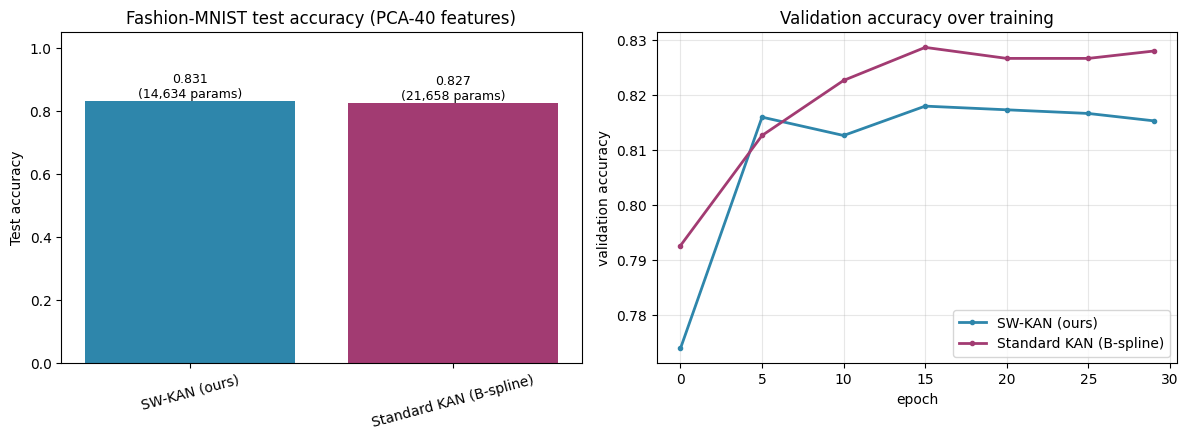


SUMMARY RESULTS
Model                      | Parameters |  Test Accuracy |   Time (s)
------------------------------------------------------------------
SW-KAN (ours)              |     14,634 |         0.8310 |       33.0
Standard KAN (B-spline)    |     21,658 |         0.8265 |       13.5


In [3]:
"""
fashion_mnist_benchmark_complete.py
====================================
Complete self-contained Fashion-MNIST benchmark with automatic download.
Run: python3 fashion_mnist_benchmark_complete.py
"""

import time
import gzip
import io
import urllib.request
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)


# ============================================================================ #
# 1. DATA LOADER (Fashion-MNIST with automatic download)
# ============================================================================ #

LABELS = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot",
]

# URLs for Fashion-MNIST
BASE_URL = "http://fashion-mnist.s3-website.eu-central-1.amazonaws.com/"
FILES = {
    "train_images": "train-images-idx3-ubyte.gz",
    "train_labels": "train-labels-idx1-ubyte.gz",
    "test_images": "t10k-images-idx3-ubyte.gz",
    "test_labels": "t10k-labels-idx1-ubyte.gz",
}


def download_file(url):
    """Download a file from URL and return as bytes."""
    with urllib.request.urlopen(url) as response:
        return response.read()


def _load_images_from_bytes(data_bytes):
    """Load images from gzipped bytes."""
    with gzip.open(io.BytesIO(data_bytes), "rb") as f:
        data = np.frombuffer(f.read(), dtype=np.uint8, offset=16)
    return data.reshape(-1, 28 * 28).astype(np.float32)


def _load_labels_from_bytes(data_bytes):
    """Load labels from gzipped bytes."""
    with gzip.open(io.BytesIO(data_bytes), "rb") as f:
        data = np.frombuffer(f.read(), dtype=np.uint8, offset=8)
    return data.astype(np.int64)


def load_fashion_mnist(flatten_range=(-1.0, 1.0)):
    """Download and load Fashion-MNIST as torch tensors."""
    print("Downloading Fashion-MNIST...")
    
    train_images_bytes = download_file(BASE_URL + FILES["train_images"])
    train_labels_bytes = download_file(BASE_URL + FILES["train_labels"])
    test_images_bytes = download_file(BASE_URL + FILES["test_images"])
    test_labels_bytes = download_file(BASE_URL + FILES["test_labels"])
    
    print("Loading data...")
    Xtr = _load_images_from_bytes(train_images_bytes)
    ytr = _load_labels_from_bytes(train_labels_bytes)
    Xte = _load_images_from_bytes(test_images_bytes)
    yte = _load_labels_from_bytes(test_labels_bytes)

    lo, hi = flatten_range
    Xtr = Xtr / 255.0 * (hi - lo) + lo
    Xte = Xte / 255.0 * (hi - lo) + lo

    return (
        torch.from_numpy(Xtr),
        torch.from_numpy(ytr),
        torch.from_numpy(Xte),
        torch.from_numpy(yte),
    )


# ============================================================================ #
# 2. SW-KAN MODEL
# ============================================================================ #

import math

class StieltjesWigertKANLayer(nn.Module):
    def __init__(
        self,
        in_features: int,
        out_features: int,
        degree: int = 6,
        gamma: float = 2.0,
        iota: float = 1.0,
        q_min: float = 0.35,
        q_max: float = 0.95,
        base_scale: float = 1.0,
    ):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.degree = degree
        self.gamma = gamma
        self.iota = iota
        self.q_min = q_min
        self.q_max = q_max

        self.pre_scale = nn.Parameter(torch.ones(in_features))
        self.pre_shift = nn.Parameter(torch.zeros(in_features))

        fan_in = in_features * (degree + 1)
        self.coeffs = nn.Parameter(
            torch.randn(out_features, in_features, degree + 1) / math.sqrt(fan_in)
        )

        self.q_raw = nn.Parameter(torch.zeros(out_features, in_features))
        self.base_weight = nn.Parameter(
            torch.full((out_features, in_features), base_scale) / math.sqrt(in_features)
        )
        self.bias = nn.Parameter(torch.zeros(out_features))

    def domain_map(self, x: torch.Tensor) -> torch.Tensor:
        x = self.pre_scale * x + self.pre_shift
        return torch.exp(self.gamma * torch.tanh(x / self.iota))

    def edge_q(self) -> torch.Tensor:
        s = torch.sigmoid(self.q_raw)
        return self.q_min + (self.q_max - self.q_min) * s

    def sw_basis(self, z: torch.Tensor, q: torch.Tensor) -> torch.Tensor:
        batch = z.shape[0]
        device, dtype = z.device, z.dtype
        eps = 1e-8

        z_b = z.unsqueeze(1)
        log_q = torch.log(q).unsqueeze(0)
        q_val = torch.exp(log_q)

        def b_n(n: int) -> torch.Tensor:
            return torch.exp(-(2 * n + 1.5) * log_q) * (1.0 + q_val - torch.exp((n + 1) * log_q))

        def a2_n(n: int) -> torch.Tensor:
            if n == 0:
                return torch.zeros_like(q_val)
            return torch.exp(-4 * n * log_q) * (1.0 - torch.exp(n * log_q))

        T_prev = torch.zeros(batch, self.out_features, self.in_features, device=device, dtype=dtype)
        T_curr = torch.ones(batch, self.out_features, self.in_features, device=device, dtype=dtype)
        T_list = [T_curr]

        a_curr = torch.zeros(1, self.out_features, self.in_features, device=device, dtype=dtype)

        for n in range(self.degree):
            a_next = torch.sqrt(a2_n(n + 1) + eps)
            bn = b_n(n)
            T_next = ((z_b - bn) * T_curr - a_curr * T_prev) / a_next
            T_list.append(T_next)
            T_prev, T_curr = T_curr, T_next
            a_curr = a_next

        return torch.stack(T_list, dim=-1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        z = self.domain_map(x)
        q = self.edge_q()
        S = self.sw_basis(z, q)

        poly = torch.einsum("boin,oin->bo", S, self.coeffs)
        base = F.silu(x) @ self.base_weight.t()

        return poly + base + self.bias


class SWKAN(nn.Module):
    def __init__(self, layer_sizes: list[int], degree: int = 6, gamma: float = 2.0, iota: float = 1.0, q_min: float = 0.35, q_max: float = 0.95):
        super().__init__()
        assert len(layer_sizes) >= 2
        self.layers = nn.ModuleList(
            [
                StieltjesWigertKANLayer(
                    layer_sizes[i],
                    layer_sizes[i + 1],
                    degree=degree,
                    gamma=gamma,
                    iota=iota,
                    q_min=q_min,
                    q_max=q_max,
                )
                for i in range(len(layer_sizes) - 1)
            ]
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        for layer in self.layers:
            x = layer(x)
        return x


# ============================================================================ #
# 3. B-SPLINE KAN MODEL (Standard KAN)
# ============================================================================ #

def cox_de_boor_basis(x: torch.Tensor, grid: torch.Tensor, order: int) -> torch.Tensor:
    x = x.unsqueeze(-1)
    grid = grid.unsqueeze(0)

    basis = ((x >= grid[:, :, :-1]) & (x < grid[:, :, 1:])).to(x.dtype)

    for k in range(1, order + 1):
        left_num = x - grid[:, :, : -(k + 1)]
        left_den = grid[:, :, k:-1] - grid[:, :, : -(k + 1)]
        left = left_num / (left_den + 1e-8) * basis[:, :, :-1]

        right_num = grid[:, :, k + 1:] - x
        right_den = grid[:, :, k + 1:] - grid[:, :, 1:-k]
        right = right_num / (right_den + 1e-8) * basis[:, :, 1:]

        basis = left + right

    return basis


class BSplineKANLayer(nn.Module):
    def __init__(self, in_features: int, out_features: int, grid_size: int = 5, order: int = 3, grid_range: tuple[float, float] = (-3.0, 3.0)):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.grid_size = grid_size
        self.order = order

        h = (grid_range[1] - grid_range[0]) / grid_size
        grid = torch.arange(-order, grid_size + order + 1, dtype=torch.float32) * h + grid_range[0]
        grid = grid.unsqueeze(0).repeat(in_features, 1)
        self.register_buffer("grid", grid)

        num_basis = grid_size + order
        self.spline_weight = nn.Parameter(
            torch.randn(out_features, in_features, num_basis) * (1.0 / (in_features * num_basis) ** 0.5)
        )
        self.base_weight = nn.Parameter(torch.randn(out_features, in_features) / (in_features ** 0.5))
        self.bias = nn.Parameter(torch.zeros(out_features))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x_clamped = x.clamp(self.grid[0, self.order].item(), self.grid[0, -self.order - 1].item())
        basis = cox_de_boor_basis(x_clamped, self.grid, self.order)
        spline_out = torch.einsum("bik,oik->bo", basis, self.spline_weight)
        base_out = F.silu(x) @ self.base_weight.t()
        return spline_out + base_out + self.bias


class BSplineKAN(nn.Module):
    def __init__(self, layer_sizes: list[int], grid_size: int = 5, order: int = 3, grid_range=(-3.0, 3.0)):
        super().__init__()
        self.layers = nn.ModuleList(
            [
                BSplineKANLayer(layer_sizes[i], layer_sizes[i + 1], grid_size=grid_size, order=order, grid_range=grid_range)
                for i in range(len(layer_sizes) - 1)
            ]
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        for layer in self.layers:
            x = layer(x)
        return x


# ============================================================================ #
# 4. PCA HELPER
# ============================================================================ #

def pca_fit(X_train, n_components, fit_subsample=8000):
    X_train_np = X_train.numpy()
    idx = np.random.choice(len(X_train_np), size=min(fit_subsample, len(X_train_np)), replace=False)
    fit_data = X_train_np[idx]
    mean = fit_data.mean(axis=0, keepdims=True)
    fit_centered = fit_data - mean

    U, S, Vt = np.linalg.svd(fit_centered, full_matrices=False)
    components = Vt[:n_components]
    return mean, components


def pca_transform(X, mean, components, std=None):
    X_np = X.numpy()
    reduced = (X_np - mean) @ components.T
    if std is None:
        std = reduced.std(axis=0, keepdims=True) + 1e-6
        return torch.from_numpy((reduced / std).clip(-3, 3)).float(), std
    return torch.from_numpy((reduced / std).clip(-3, 3)).float()


# ============================================================================ #
# 5. TRAINING HELPERS
# ============================================================================ #

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def evaluate(model, X, y, batch_size=1000):
    model.eval()
    correct = 0
    for start in range(0, len(X), batch_size):
        xb, yb = X[start:start + batch_size], y[start:start + batch_size]
        logits = model(xb)
        correct += (logits.argmax(dim=1) == yb).sum().item()
    model.train()
    return correct / len(X)


def train_classifier(model, X_train, y_train, X_val, y_val, X_test, y_test, epochs, lr, batch_size=128, clip=5.0, weight_decay=0.0):
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    loss_fn = nn.CrossEntropyLoss()

    n = X_train.shape[0]
    history = []
    best_val = -1.0
    best_state = None
    best_epoch = -1
    t0 = time.time()

    for epoch in range(epochs):
        perm = torch.randperm(n)
        total_loss = 0.0
        for start in range(0, n, batch_size):
            idx = perm[start:start + batch_size]
            xb, yb = X_train[idx], y_train[idx]
            opt.zero_grad()
            logits = model(xb)
            loss = loss_fn(logits, yb)
            loss.backward()
            if clip is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
            opt.step()
            total_loss += loss.item() * len(idx)
        sched.step()
        train_loss = total_loss / n

        val_acc = evaluate(model, X_val, y_val)
        if val_acc > best_val:
            best_val = val_acc
            best_epoch = epoch
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

        if epoch % 5 == 0 or epoch == epochs - 1:
            history.append((epoch, train_loss, val_acc))
            print(f"    epoch {epoch:3d}  train_loss {train_loss:.4f}  val_acc {val_acc:.4f}")

    elapsed = time.time() - t0
    model.load_state_dict(best_state)
    final_test_acc = evaluate(model, X_test, y_test)
    print(f"    -> best val_acc {best_val:.4f} at epoch {best_epoch}; test_acc: {final_test_acc:.4f}")
    return final_test_acc, elapsed, history


# ============================================================================ #
# 6. MAIN
# ============================================================================ #

if __name__ == "__main__":
    import math

    print("=" * 60)
    print("Fashion-MNIST Benchmark: SW-KAN vs B-spline KAN")
    print("=" * 60)
    
    Xtr_full, ytr_full, Xte_full, yte_full = load_fashion_mnist(flatten_range=(-1, 1))

    N_TRAIN, N_VAL, N_TEST, N_COMPONENTS = 10000, 1500, 2000, 40
    all_train_idx = np.random.choice(len(Xtr_full), N_TRAIN + N_VAL, replace=False)
    train_idx, val_idx = all_train_idx[:N_TRAIN], all_train_idx[N_TRAIN:]
    test_idx = np.random.choice(len(Xte_full), N_TEST, replace=False)

    X_train_raw = Xtr_full[train_idx]
    y_train = ytr_full[train_idx]
    X_val_raw = Xtr_full[val_idx]
    y_val = ytr_full[val_idx]
    X_test_raw = Xte_full[test_idx]
    y_test = yte_full[test_idx]

    print(f"Using {N_TRAIN} train, {N_VAL} validation, {N_TEST} test samples")
    
    mean, components = pca_fit(X_train_raw, n_components=N_COMPONENTS)
    X_train, std = pca_transform(X_train_raw, mean, components)
    X_val = pca_transform(X_val_raw, mean, components, std=std)
    X_test = pca_transform(X_test_raw, mean, components, std=std)
    print(f"PCA-reduced features: {N_COMPONENTS} dims")

    sizes = [N_COMPONENTS, 48, 10]
    results = {}

    print("\n" + "-" * 60)
    print("Training SW-KAN ...")
    print("-" * 60)
    sw_model = SWKAN(sizes, degree=3)
    sw_acc, sw_time, sw_hist = train_classifier(
        sw_model, X_train, y_train, X_val, y_val, X_test, y_test,
        epochs=30, lr=1e-2, weight_decay=1e-4
    )
    results["SW-KAN (ours)"] = (sw_model, sw_acc, sw_time, sw_hist)

    print("\n" + "-" * 60)
    print("Training Standard KAN (B-spline) ...")
    print("-" * 60)
    bsp_model = BSplineKAN(sizes, grid_size=5, order=3, grid_range=(-3.0, 3.0))
    bsp_acc, bsp_time, bsp_hist = train_classifier(
        bsp_model, X_train, y_train, X_val, y_val, X_test, y_test,
        epochs=30, lr=1e-2, weight_decay=1e-4
    )
    results["Standard KAN (B-spline)"] = (bsp_model, bsp_acc, bsp_time, bsp_hist)

    print("\n" + "=" * 66)
    print(f"{'Model':<26}{'Params':>8}{'Test Acc':>12}{'Time (s)':>12}")
    print("-" * 66)
    for name, (model, acc, elapsed, hist) in results.items():
        print(f"{name:<26}{count_params(model):>8}{acc:>12.4f}{elapsed:>12.1f}")

    # Plot results
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    names = list(results.keys())
    accs = [results[n][1] for n in names]
    params = [count_params(results[n][0]) for n in names]
    colors = ["#2E86AB", "#A23B72"]

    # Accuracy bar chart
    axes[0].bar(names, accs, color=colors)
    for i, (a, p) in enumerate(zip(accs, params)):
        axes[0].text(i, a + 0.01, f"{a:.3f}\n({p:,} params)", ha="center", fontsize=9)
    axes[0].set_ylabel("Test accuracy")
    axes[0].set_ylim(0, 1.05)
    axes[0].set_title("Fashion-MNIST test accuracy (PCA-40 features)")
    axes[0].tick_params(axis="x", rotation=15)

    # Training curves
    for name, color in zip(names, colors):
        hist = results[name][3]
        epochs_h = [h[0] for h in hist]
        accs_h = [h[2] for h in hist]
        axes[1].plot(epochs_h, accs_h, "-o", color=color, label=name, markersize=3, linewidth=2)
    axes[1].set_xlabel("epoch")
    axes[1].set_ylabel("validation accuracy")
    axes[1].set_title("Validation accuracy over training")
    axes[1].legend(fontsize=10)
    axes[1].grid(True, alpha=0.3)

    fig.tight_layout()
    
    # Display plot inline (for notebook) or save
    try:
        from IPython.display import display
        display(fig)
    except:
        plt.savefig("fashion_mnist_comparison.png", dpi=150, bbox_inches="tight")
        print("\nSaved plot to fashion_mnist_comparison.png")
    
    plt.show()
    
    # Print summary
    print("\n" + "=" * 66)
    print("SUMMARY RESULTS")
    print("=" * 66)
    print(f"{'Model':<26} | {'Parameters':>10} | {'Test Accuracy':>14} | {'Time (s)':>10}")
    print("-" * 66)
    for name, (model, acc, elapsed, hist) in results.items():
        print(f"{name:<26} | {count_params(model):>10,} | {acc:>14.4f} | {elapsed:>10.1f}")

SW-KAN 3D Function Approximation (5k samples, 5000 epochs)

Training configuration:
  - Training samples: 5000
  - Epochs: 5000
  - Learning rate: 0.01
  - Network: [2, 16, 1], degree=4
  - Test grid: 25x25 = 625 points

----------------------------------------------------------------------
Training: f₁ = sin(x)cos(y) + 0.5xy
----------------------------------------------------------------------
    epoch     0  loss: 6.938450
    epoch   500  loss: 0.000125
    epoch  1000  loss: 0.000062
    epoch  1500  loss: 0.000092
    epoch  2000  loss: 0.000026
    epoch  2500  loss: 0.000019
    epoch  3000  loss: 0.000015
    epoch  3500  loss: 0.000013
    epoch  4000  loss: 0.000011
    epoch  4500  loss: 0.000011
    epoch  4999  loss: 0.000011
    Test MSE: 0.000025
    Time: 97.76s
    Parameters: 389

----------------------------------------------------------------------
Training: f₂ = exp(-(x²+y²)/2)(1+0.3sin(3x)cos(2y))
-----------------------------------------------------------------

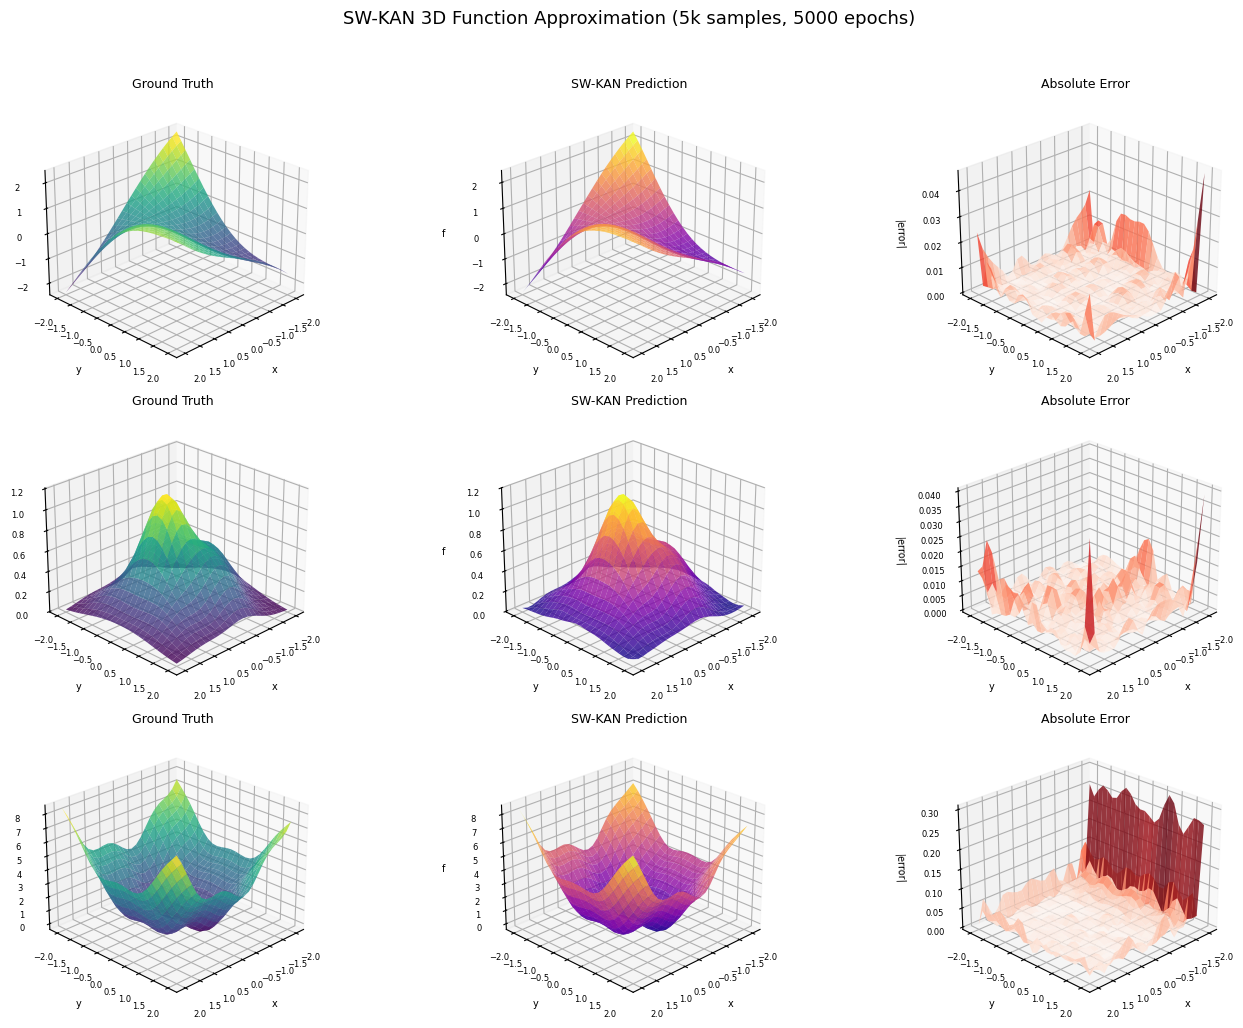

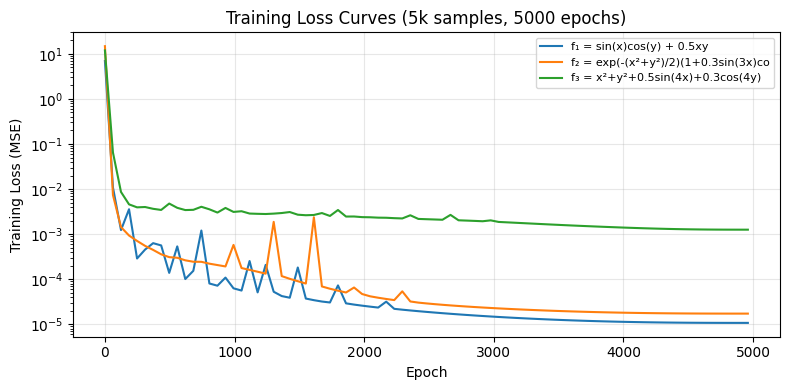


Plots displayed inline.

SUMMARY (5k samples, 5000 epochs)
Function                                           |     Test MSE |     Params |   Time (s)
----------------------------------------------------------------------
f₁ = sin(x)cos(y) + 0.5xy                          |     0.000025 |        389 |      97.76
f₂ = exp(-(x²+y²)/2)(1+0.3sin(3x)cos(2y))          |     0.000029 |        389 |      96.31
f₃ = x²+y²+0.5sin(4x)+0.3cos(4y)                   |     0.003510 |        389 |      96.59


In [7]:
"""
sw_kan_3d_function_approximation_5k_5000ep.py
===============================================
3D function approximation with SW-KAN on 5k training samples, 5000 epochs.
Run: python3 sw_kan_3d_function_approximation_5k_5000ep.py
"""

import time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

torch.manual_seed(42)
np.random.seed(42)


# ============================================================================ #
# 1. SW-KAN MODEL
# ============================================================================ #

import math

class StieltjesWigertKANLayer(nn.Module):
    def __init__(
        self,
        in_features: int,
        out_features: int,
        degree: int = 6,
        gamma: float = 2.0,
        iota: float = 1.0,
        q_min: float = 0.35,
        q_max: float = 0.95,
        base_scale: float = 1.0,
    ):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.degree = degree
        self.gamma = gamma
        self.iota = iota
        self.q_min = q_min
        self.q_max = q_max

        self.pre_scale = nn.Parameter(torch.ones(in_features))
        self.pre_shift = nn.Parameter(torch.zeros(in_features))

        fan_in = in_features * (degree + 1)
        self.coeffs = nn.Parameter(
            torch.randn(out_features, in_features, degree + 1) / math.sqrt(fan_in)
        )

        self.q_raw = nn.Parameter(torch.zeros(out_features, in_features))
        self.base_weight = nn.Parameter(
            torch.full((out_features, in_features), base_scale) / math.sqrt(in_features)
        )
        self.bias = nn.Parameter(torch.zeros(out_features))

    def domain_map(self, x: torch.Tensor) -> torch.Tensor:
        x = self.pre_scale * x + self.pre_shift
        return torch.exp(self.gamma * torch.tanh(x / self.iota))

    def edge_q(self) -> torch.Tensor:
        s = torch.sigmoid(self.q_raw)
        return self.q_min + (self.q_max - self.q_min) * s

    def sw_basis(self, z: torch.Tensor, q: torch.Tensor) -> torch.Tensor:
        batch = z.shape[0]
        device, dtype = z.device, z.dtype
        eps = 1e-8

        z_b = z.unsqueeze(1)
        log_q = torch.log(q).unsqueeze(0)
        q_val = torch.exp(log_q)

        def b_n(n: int) -> torch.Tensor:
            return torch.exp(-(2 * n + 1.5) * log_q) * (1.0 + q_val - torch.exp((n + 1) * log_q))

        def a2_n(n: int) -> torch.Tensor:
            if n == 0:
                return torch.zeros_like(q_val)
            return torch.exp(-4 * n * log_q) * (1.0 - torch.exp(n * log_q))

        T_prev = torch.zeros(batch, self.out_features, self.in_features, device=device, dtype=dtype)
        T_curr = torch.ones(batch, self.out_features, self.in_features, device=device, dtype=dtype)
        T_list = [T_curr]

        a_curr = torch.zeros(1, self.out_features, self.in_features, device=device, dtype=dtype)

        for n in range(self.degree):
            a_next = torch.sqrt(a2_n(n + 1) + eps)
            bn = b_n(n)
            T_next = ((z_b - bn) * T_curr - a_curr * T_prev) / a_next
            T_list.append(T_next)
            T_prev, T_curr = T_curr, T_next
            a_curr = a_next

        return torch.stack(T_list, dim=-1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        z = self.domain_map(x)
        q = self.edge_q()
        S = self.sw_basis(z, q)

        poly = torch.einsum("boin,oin->bo", S, self.coeffs)
        base = F.silu(x) @ self.base_weight.t()

        return poly + base + self.bias


class SWKAN(nn.Module):
    def __init__(self, layer_sizes: list[int], degree: int = 6, gamma: float = 2.0, iota: float = 1.0, q_min: float = 0.35, q_max: float = 0.95):
        super().__init__()
        assert len(layer_sizes) >= 2
        self.layers = nn.ModuleList(
            [
                StieltjesWigertKANLayer(
                    layer_sizes[i],
                    layer_sizes[i + 1],
                    degree=degree,
                    gamma=gamma,
                    iota=iota,
                    q_min=q_min,
                    q_max=q_max,
                )
                for i in range(len(layer_sizes) - 1)
            ]
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        for layer in self.layers:
            x = layer(x)
        return x


# ============================================================================ #
# 2. TARGET FUNCTIONS
# ============================================================================ #

def function_1(x, y):
    return torch.sin(x) * torch.cos(y) + 0.5 * x * y

def function_2(x, y):
    return torch.exp(-(x**2 + y**2) / 2) * (1 + 0.3 * torch.sin(3*x) * torch.cos(2*y))

def function_3(x, y):
    return x**2 + y**2 + 0.5 * torch.sin(4*x) + 0.3 * torch.cos(4*y)


FUNCTIONS = [
    ("f₁ = sin(x)cos(y) + 0.5xy", function_1),
    ("f₂ = exp(-(x²+y²)/2)(1+0.3sin(3x)cos(2y))", function_2),
    ("f₃ = x²+y²+0.5sin(4x)+0.3cos(4y)", function_3),
]


# ============================================================================ #
# 3. TRAINING
# ============================================================================ #

def train_model(model, X_train, y_train, epochs, lr):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    loss_fn = nn.MSELoss()
    
    t0 = time.time()
    losses = []
    
    for epoch in range(epochs):
        opt.zero_grad()
        pred = model(X_train)
        loss = loss_fn(pred, y_train)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        opt.step()
        sched.step()
        
        losses.append(loss.item())
        
        if epoch % 500 == 0 or epoch == epochs - 1:
            print(f"    epoch {epoch:5d}  loss: {loss.item():.6f}")
    
    elapsed = time.time() - t0
    return losses, elapsed


# ============================================================================ #
# 4. MAIN - 5k SAMPLES, 5000 EPOCHS, FAST PLOTTING
# ============================================================================ #

if __name__ == "__main__":
    print("=" * 70)
    print("SW-KAN 3D Function Approximation (5k samples, 5000 epochs)")
    print("=" * 70)
    
    # Parameters - 5k samples, 5000 epochs
    n_train = 5000
    n_test = 25  # کاهش برای سرعت بیشتر
    epochs = 5000
    lr = 1e-2
    
    print(f"\nTraining configuration:")
    print(f"  - Training samples: {n_train}")
    print(f"  - Epochs: {epochs}")
    print(f"  - Learning rate: {lr}")
    print(f"  - Network: [2, 16, 1], degree=4")
    print(f"  - Test grid: {n_test}x{n_test} = {n_test*n_test} points")
    
    # Training data
    X_train = torch.rand(n_train, 2) * 4 - 2
    
    # Test grid
    x_test = torch.linspace(-2, 2, n_test)
    y_test = torch.linspace(-2, 2, n_test)
    X1_test, X2_test = torch.meshgrid(x_test, y_test, indexing='ij')
    X_test_grid = torch.stack([X1_test.flatten(), X2_test.flatten()], dim=1)
    
    results = []
    
    # Train for each function
    for func_name, func in FUNCTIONS:
        print("\n" + "-" * 70)
        print(f"Training: {func_name}")
        print("-" * 70)
        
        y_train = func(X_train[:, 0], X_train[:, 1]).unsqueeze(1)
        y_test_true = func(X1_test, X2_test)
        
        model = SWKAN([2, 16, 1], degree=4)
        
        losses, elapsed = train_model(model, X_train, y_train, epochs=epochs, lr=lr)
        
        with torch.no_grad():
            pred = model(X_test_grid).reshape(n_test, n_test)
        
        test_mse = torch.mean((pred - y_test_true)**2).item()
        
        results.append({
            'name': func_name,
            'model': model,
            'pred': pred,
            'y_test': y_test_true,
            'losses': losses,
            'test_mse': test_mse,
            'elapsed': elapsed,
            'params': sum(p.numel() for p in model.parameters() if p.requires_grad)
        })
        
        print(f"    Test MSE: {test_mse:.6f}")
        print(f"    Time: {elapsed:.2f}s")
        print(f"    Parameters: {results[-1]['params']:,}")

    # ======================================================================== #
    # 5. PLOT - FAST (reduced resolution)
    # ======================================================================== #
    
    print("\nGenerating plots (fast mode)...")
    
    # ایجاد یک شکل با ساب‌پلات‌های ۳x۳
    fig = plt.figure(figsize=(15, 10))
    
    X_plot, Y_plot = X1_test, X2_test
    
    for idx, data in enumerate(results):
        # Ground Truth
        ax1 = fig.add_subplot(3, 3, idx*3 + 1, projection='3d')
        ax1.plot_surface(
            X_plot.numpy(), Y_plot.numpy(), data['y_test'].numpy(),
            cmap='viridis', alpha=0.8, linewidth=0, antialiased=True,
            rstride=1, cstride=1
        )
        ax1.set_title(f"Ground Truth", fontsize=9)
        ax1.set_xlabel('x', fontsize=7)
        ax1.set_ylabel('y', fontsize=7)
        ax1.set_zlabel('f', fontsize=7)
        ax1.view_init(elev=25, azim=45)
        ax1.tick_params(labelsize=6)
        
        # Prediction
        ax2 = fig.add_subplot(3, 3, idx*3 + 2, projection='3d')
        ax2.plot_surface(
            X_plot.numpy(), Y_plot.numpy(), data['pred'].numpy(),
            cmap='plasma', alpha=0.8, linewidth=0, antialiased=True,
            rstride=1, cstride=1
        )
        ax2.set_title(f"SW-KAN Prediction", fontsize=9)
        ax2.set_xlabel('x', fontsize=7)
        ax2.set_ylabel('y', fontsize=7)
        ax2.set_zlabel('f', fontsize=7)
        ax2.view_init(elev=25, azim=45)
        ax2.tick_params(labelsize=6)
        
        # Error
        ax3 = fig.add_subplot(3, 3, idx*3 + 3, projection='3d')
        error = torch.abs(data['pred'] - data['y_test'])
        ax3.plot_surface(
            X_plot.numpy(), Y_plot.numpy(), error.numpy(),
            cmap='Reds', alpha=0.8, linewidth=0, antialiased=True,
            rstride=1, cstride=1
        )
        ax3.set_title(f"Absolute Error", fontsize=9)
        ax3.set_xlabel('x', fontsize=7)
        ax3.set_ylabel('y', fontsize=7)
        ax3.set_zlabel('|error|', fontsize=7)
        ax3.view_init(elev=25, azim=45)
        ax3.tick_params(labelsize=6)
    
    fig.suptitle("SW-KAN 3D Function Approximation (5k samples, 5000 epochs)", fontsize=13, y=1.02)
    plt.tight_layout()
    
    # ======================================================================== #
    # 6. LOSS CURVES
    # ======================================================================== #
    
    fig_loss = plt.figure(figsize=(8, 4))
    ax_loss = fig_loss.add_subplot(111)
    for data in results:
        step = max(1, len(data['losses']) // 80)
        losses = data['losses'][::step]
        ax_loss.plot(range(0, len(data['losses']), step), losses, label=data['name'][:35], linewidth=1.5)
    ax_loss.set_xlabel('Epoch')
    ax_loss.set_ylabel('Training Loss (MSE)')
    ax_loss.set_title('Training Loss Curves (5k samples, 5000 epochs)')
    ax_loss.legend(fontsize=8)
    ax_loss.grid(True, alpha=0.3)
    ax_loss.set_yscale('log')
    
    plt.tight_layout()
    
    # Display
    try:
        from IPython.display import display
        display(fig)
        display(fig_loss)
        print("\nPlots displayed inline.")
    except:
        fig.savefig("sw_kan_3d_functions_5k_5000ep.png", dpi=100, bbox_inches="tight")
        fig_loss.savefig("sw_kan_training_losses_5k_5000ep.png", dpi=100, bbox_inches="tight")
        print("\nSaved plots to sw_kan_3d_functions_5k_5000ep.png and sw_kan_training_losses_5k_5000ep.png")
    
    plt.show()
    
    # ======================================================================== #
    # 7. SUMMARY
    # ======================================================================== #
    
    print("\n" + "=" * 70)
    print("SUMMARY (5k samples, 5000 epochs)")
    print("=" * 70)
    print(f"{'Function':<50} | {'Test MSE':>12} | {'Params':>10} | {'Time (s)':>10}")
    print("-" * 70)
    for data in results:
        print(f"{data['name'][:50]:<50} | {data['test_mse']:>12.6f} | {data['params']:>10,} | {data['elapsed']:>10.2f}")